1.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 1. Загрузка данных
print("=" * 80)
print("ШАГ 1: Загрузка данных")
print("=" * 80)

file_path = 'mfdexport_1week_01012015_19122025 ира.txt'
df = pd.read_csv(file_path, sep=';', encoding='utf-8', decimal=',')

# Переименуем столбцы для удобства (в файле русские названия в кодировке)
df.columns = ['TICKER', 'PER', 'DATE', 'TIME', 'CLOSE', 'VOL']

# Преобразуем дату
df['DATE'] = pd.to_datetime(df['DATE'], format='%d/%m/%y')

# Сортируем по тикеру и дате
df = df.sort_values(['TICKER', 'DATE']).reset_index(drop=True)

# Выведем информацию о данных
print("Общая информация о данных:")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print(f"Период данных: {df['DATE'].min()} - {df['DATE'].max()}")
print(f"Тикеры: {df['TICKER'].unique()}")
print(f"Количество уникальных тикеров: {len(df['TICKER'].unique())}")
print(f"Количество недель на тикер: {df['TICKER'].value_counts()}")
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о типах данных:")
print(df.info())

ШАГ 1: Загрузка данных
Общая информация о данных:
Количество строк: 1487
Количество столбцов: 6
Период данных: 2015-01-05 00:00:00 - 2025-12-15 00:00:00
Тикеры: ['МРСК ЦП' 'ОГК-2 ао' 'СевСт-ао']
Количество уникальных тикеров: 3
Количество недель на тикер: TICKER
СевСт-ао    569
ОГК-2 ао    568
МРСК ЦП     350
Name: count, dtype: int64

Первые 5 строк:
    TICKER PER       DATE  TIME   CLOSE        VOL
0  МРСК ЦП   W 2015-01-05     0  0.0921   29270000
1  МРСК ЦП   W 2015-01-12     0  0.0907   12020000
2  МРСК ЦП   W 2015-01-19     0  0.0840   74450000
3  МРСК ЦП   W 2015-01-26     0  0.0777   93460000
4  МРСК ЦП   W 2015-02-02     0  0.0732  146430000

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487 entries, 0 to 1486
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   TICKER  1487 non-null   object        
 1   PER     1487 non-null   object        
 2   DATE    1487 non-null   d

2.

In [ ]:
import pandas as pd
import numpy as np

print("=" * 80)
print("ЗАДАНИЕ 2: Вычисление признаков для каждой компании")
print("=" * 80)

# 1. Загрузка данных
file_path = 'mfdexport_1week_01012015_19122025 ира.txt'
df = pd.read_csv(file_path, sep=';', encoding='utf-8', decimal=',')
df.columns = ['TICKER', 'PER', 'DATE', 'TIME', 'CLOSE', 'VOL']

# Преобразование даты
df['DATE'] = pd.to_datetime(df['DATE'], format='%d/%m/%y')

# Получаем список компаний
companies = df['TICKER'].unique()
print(f"Компании для анализа: {companies}")
print(f"Количество компаний: {len(companies)}")

# 2. Вычисление признаков ДЛЯ КАЖДОЙ КОМПАНИИ (общая статистика)
print("\n" + "=" * 80)
print("ВЫЧИСЛЕНИЕ ПРИЗНАКОВ:")
print("=" * 80)

results = []

for company in companies:
    print(f"\n{'='*50}")
    print(f"КОМПАНИЯ: {company}")
    print(f"{'='*50}")

    # Фильтруем данные по компании
    company_data = df[df['TICKER'] == company].copy()
    company_data = company_data.sort_values('DATE')

    # a. ЛОГАРИФМ ЦЕНЫ - для каждой недели
    company_data['log_price'] = np.log(company_data['CLOSE'])

    # b. ЛОГОДОХОДНОСТЬ - для каждой недели
    company_data['log_return'] = np.log(company_data['CLOSE'] / company_data['CLOSE'].shift(1))

    # c. ЛОГАРИФМ ОБЪЁМА - для каждой недели (только для диаграмм рассеяния)
    company_data['log_volume'] = np.log(company_data['VOL'] + 1e-10)

    # Удаляем первую строку (там нет log_return)
    company_data = company_data.dropna(subset=['log_return'])

    # Вычисляем СРЕДНИЕ значения по всей компании:
    mean_log_price = company_data['log_price'].mean()
    mean_log_return = company_data['log_return'].mean()
    mean_log_volume = company_data['log_volume'].mean()

    print(f"a. Средний логарифм цены: {mean_log_price:.6f}")
    print(f"b. Средняя логдоходность: {mean_log_return:.6f}")
    print(f"c. Средний логарифм объёма: {mean_log_volume:.6f}")

    # Сохраняем результаты
    results.append({
        'Компания': company,
        'Период': f"{company_data['DATE'].min().date()} - {company_data['DATE'].max().date()}",
        'Недель': len(company_data),
        'Средний log_price': mean_log_price,
        'Средний log_return': mean_log_return,
        'Средний log_volume': mean_log_volume,
        'Стд log_return': company_data['log_return'].std()
    })

    # Показываем пример первых 3 значений
    print(f"\nПример значений (первые 3 недели):")
    print(company_data[['DATE', 'CLOSE', 'log_price', 'log_return', 'VOL', 'log_volume']].head(3).to_string(index=False))

# 3. Сводная таблица результатов
print("\n" + "=" * 80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print("=" * 80)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# 4. Сохранение результатов
print("\n" + "=" * 80)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ:")
print("=" * 80)

# Сохраняем данные с вычисленными признаками
output_file = 'companies_features_complete.csv'
df_all = pd.concat([df[df['TICKER'] == company].copy() for company in companies])
df_all = df_all.sort_values(['TICKER', 'DATE'])

# Вычисляем признаки для всего DataFrame
df_all['log_price'] = np.log(df_all['CLOSE'])
df_all['log_return'] = np.log(df_all['CLOSE'] / df_all.groupby('TICKER')['CLOSE'].shift(1))
df_all['log_volume'] = np.log(df_all['VOL'] + 1e-10)

df_all.to_csv(output_file, index=False, encoding='utf-8')
print(f"✓ Данные сохранены в файл: {output_file}")
print(f"✓ Количество строк: {len(df_all)}")
print(f"✓ Количество столбцов: {len(df_all.columns)}")

print("\n" + "=" * 80)
print("ЗАДАНИЕ 2 ВЫПОЛНЕНО!")
print("=" * 80)

ЗАДАНИЕ 2: Вычисление признаков для каждой компании
Компании для анализа: ['МРСК ЦП' 'СевСт-ао' 'ОГК-2 ао']
Количество компаний: 3

ВЫЧИСЛЕНИЕ ПРИЗНАКОВ:

КОМПАНИЯ: МРСК ЦП
a. Средний логарифм цены: -1.744508
b. Средняя логдоходность: 0.003231
c. Средний логарифм объёма: 19.303610

Пример значений (первые 3 недели):
      DATE  CLOSE  log_price  log_return      VOL  log_volume
2015-01-12 0.0907  -2.400198   -0.015318 12020000   16.302082
2015-01-19 0.0840  -2.476938   -0.076741 74450000   18.125638
2015-01-26 0.0777  -2.554900   -0.077962 93460000   18.353044

КОМПАНИЯ: СевСт-ао
a. Средний логарифм цены: 6.908494
b. Средняя логдоходность: 0.001044
c. Средний логарифм объёма: 15.269716

Пример значений (первые 3 недели):
      DATE  CLOSE  log_price  log_return     VOL  log_volume
2015-01-12 587.90   6.376557    0.069278 5446400   15.510465
2015-01-19 587.00   6.375025   -0.001532 4959350   15.416785
2015-01-26 642.35   6.465133    0.090109 6761410   15.726742

КОМПАНИЯ: ОГК-2 ао
a. Сре

3.

РАСЧЁТНО-АНАЛИТИЧЕСКАЯ РАБОТА

1. ЗАГРУЗКА ДАННЫХ
----------------------------------------
Компании: ['МРСК ЦП' 'ОГК-2 ао' 'СевСт-ао']
Период: 2015-01-05 - 2025-12-15
Всего наблюдений: 1487


2. ВЫЧИСЛЕНИЕ ПРИЗНАКОВ ДЛЯ КАЖДОЙ КОМПАНИИ
----------------------------------------
✓ Признаки вычислены:
  - log_price: логарифм цены закрытия
  - log_return: недельная логдоходность
  - log_volume: логарифм объёма торгов


3. ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ
----------------------------------------
Проверка данных:
Пропуски: 3
Бесконечные значения: 0
✓ Удалено строк с NaN в log_return: 3
✓ Осталось строк: 1484


4. ОПИСАТЕЛЬНАЯ СТАТИСТИКА
----------------------------------------

По компаниям:

МРСК ЦП:
  Наблюдений: 349
  Средняя цена: 0.2005
  Средний объём: 378,249,198
  log_return: μ=0.003231, σ=0.046344
  log_price: μ=-1.744508, σ=0.568732

ОГК-2 ао:
  Наблюдений: 567
  Средняя цена: 0.4863
  Средний объём: 707,463,790
  log_return: μ=0.001260, σ=0.052544
  log_price: μ=-0.783499, σ=0.3652

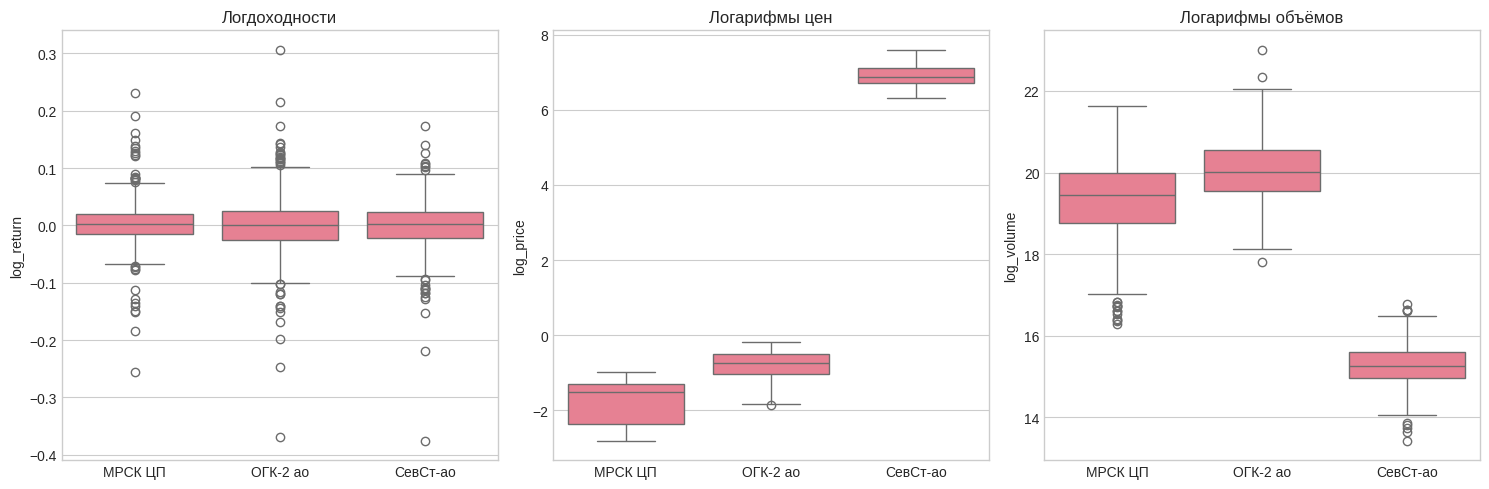

✓ Диаграммы сохранены в boxplots.png


6. ДИАГРАММЫ РАССЕЯНИЯ
----------------------------------------


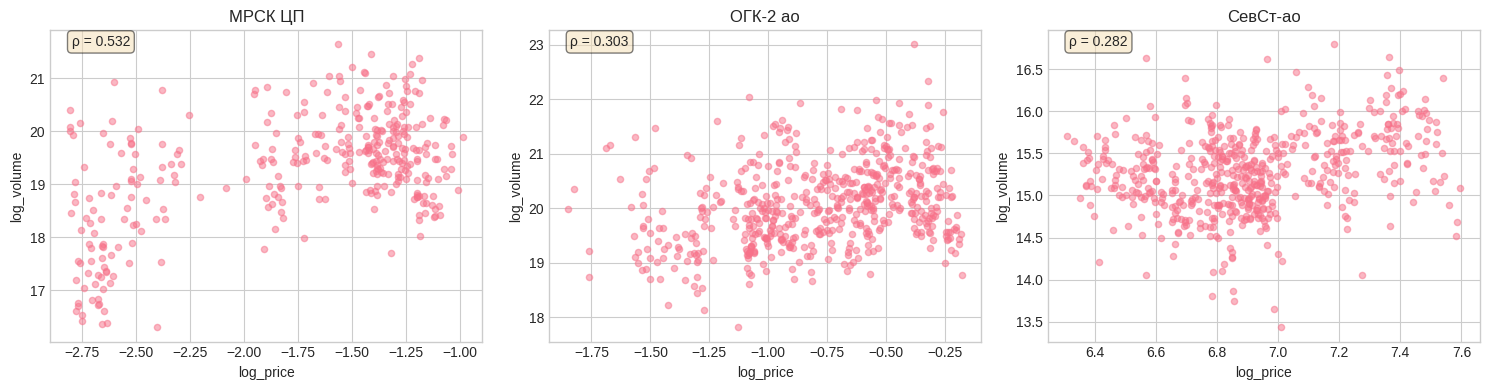

✓ Диаграммы рассеяния сохранены


7. ГИСТОГРАММЫ ИНТЕРВАЛЬНЫХ ЧАСТОТ
----------------------------------------


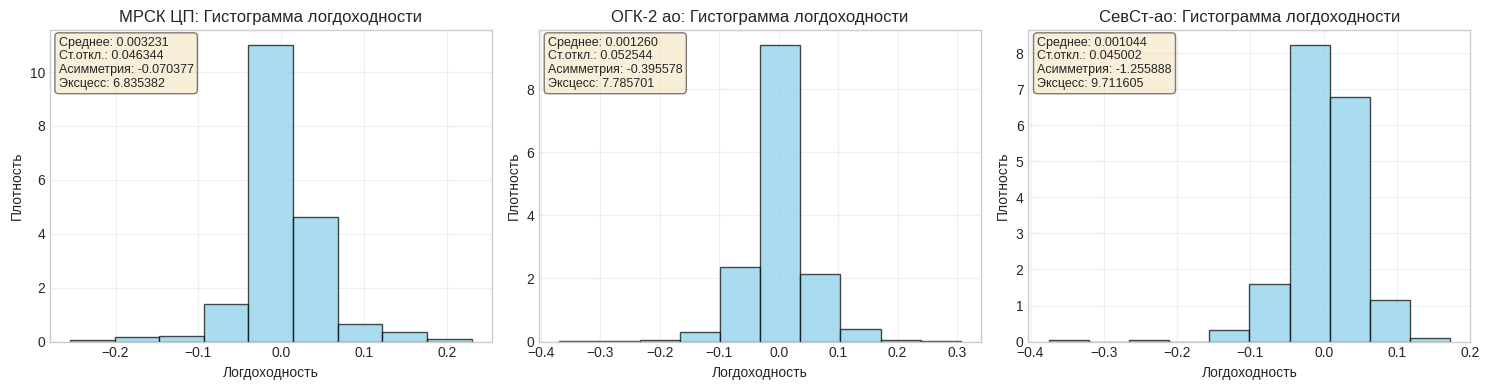



8. УДАЛЕНИЕ ВЫБРОСОВ
----------------------------------------
Было: 1484 строк
Стало: 1401 строк
Удалено выбросов: 83 строк (5.6%)


9. АНАЛИЗ БЕЗ ВЫБРОСОВ
----------------------------------------

Описательная статистика (без выбросов):

МРСК ЦП:
  Наблюдений: 319
  log_return: μ=0.001633 ± 0.026562
  Асимметрия: -0.027
  Эксцесс: 0.241

ОГК-2 ао:
  Наблюдений: 536
  log_return: μ=0.000574 ± 0.037596
  Асимметрия: -0.092
  Эксцесс: 0.152

СевСт-ао:
  Наблюдений: 546
  log_return: μ=0.002940 ± 0.035199
  Асимметрия: -0.003
  Эксцесс: -0.126


10. ПРОВЕРКА НОРМАЛЬНОСТИ
----------------------------------------

МРСК ЦП:
  Shapiro-Wilk: W=0.9918, p=0.0739
  Kolmogorov-Smirnov: D=0.0508, p=0.3698
  Нормальность: ДА (α=0.05)

ОГК-2 ао:
  Shapiro-Wilk: W=0.9938, p=0.0278
  Kolmogorov-Smirnov: D=0.0359, p=0.4842
  Нормальность: НЕТ (α=0.05)

СевСт-ао:
  Shapiro-Wilk: W=0.9950, p=0.0712
  Kolmogorov-Smirnov: D=0.0320, p=0.6184
  Нормальность: ДА (α=0.05)


11. ПРОВЕРКА ГИПОТЕЗЫ: μ > 0
------

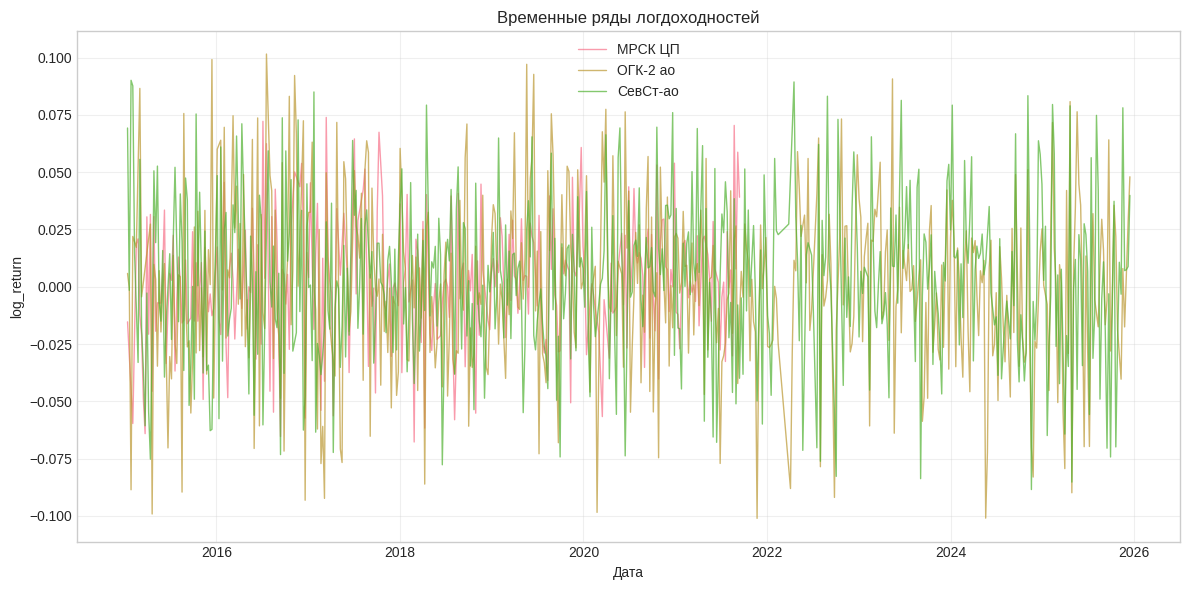


Матрица корреляций логдоходностей:
TICKER    МРСК ЦП  ОГК-2 ао  СевСт-ао
TICKER                               
МРСК ЦП     1.000     0.291     0.173
ОГК-2 ао    0.291     1.000     0.260
СевСт-ао    0.173     0.260     1.000


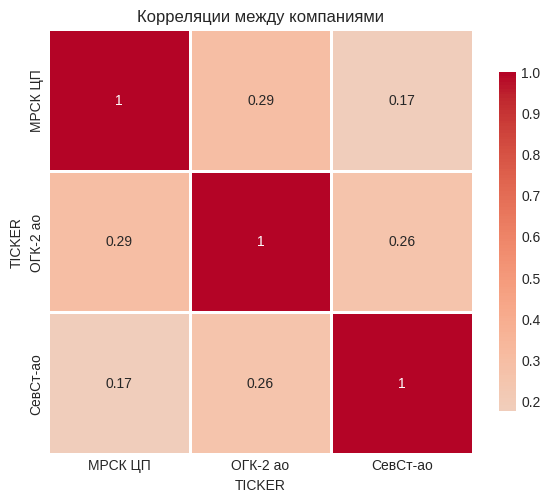



14. ДИСПЕРСИОННЫЙ АНАЛИЗ (ANOVA)
----------------------------------------
F-статистика: 0.6411
p-value: 0.526882
Есть различия между компаниями: НЕТ

АНАЛИЗ ЗАВЕРШЁН!
Созданы файлы:
✓ boxplots.png - диаграммы 'ящик с усами'
✓ scatter_plots.png - диаграммы рассеяния
✓ histograms.png - гистограммы
✓ time_series.png - временные ряды
✓ correlation_matrix.png - матрица корреляций


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind, shapiro, kstest, norm, f_oneway
import warnings
warnings.filterwarnings('ignore')

# Стиль графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 80)
print("РАСЧЁТНО-АНАЛИТИЧЕСКАЯ РАБОТА")
print("=" * 80)

# 1. ЗАГРУЗКА ДАННЫХ
print("\n1. ЗАГРУЗКА ДАННЫХ")
print("-" * 40)

file_path = 'mfdexport_1week_01012015_19122025 ира.txt'
df = pd.read_csv(file_path, sep=';', encoding='utf-8', decimal=',')
df.columns = ['TICKER', 'PER', 'DATE', 'TIME', 'CLOSE', 'VOL']
df['DATE'] = pd.to_datetime(df['DATE'], format='%d/%m/%y')
df = df.sort_values(['TICKER', 'DATE']).reset_index(drop=True)

companies = df['TICKER'].unique()
print(f"Компании: {companies}")
print(f"Период: {df['DATE'].min().date()} - {df['DATE'].max().date()}")
print(f"Всего наблюдений: {len(df)}")

# 2. ВЫЧИСЛЕНИЕ ПРИЗНАКОВ
print("\n\n2. ВЫЧИСЛЕНИЕ ПРИЗНАКОВ ДЛЯ КАЖДОЙ КОМПАНИИ")
print("-" * 40)

# Добавляем признаки
df['log_price'] = np.log(df['CLOSE'])
df['log_return'] = np.log(df['CLOSE'] / df.groupby('TICKER')['CLOSE'].shift(1))
df['log_volume'] = np.log(df['VOL'] + 1e-10)

print("✓ Признаки вычислены:")
print("  - log_price: логарифм цены закрытия")
print("  - log_return: недельная логдоходность")
print("  - log_volume: логарифм объёма торгов")

# 3. ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА
print("\n\n3. ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ")
print("-" * 40)

print("Проверка данных:")
print(f"Пропуски: {df.isnull().sum().sum()}")
print(f"Бесконечные значения: {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")

# Заменяем бесконечные значения на NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Удаляем только строки с NaN в log_return (если они есть из-за бесконечных значений)
initial_count = len(df)
df = df.dropna(subset=['log_return'])
print(f"✓ Удалено строк с NaN в log_return: {initial_count - len(df)}")
print(f"✓ Осталось строк: {len(df)}")

# 4. ОПИСАТЕЛЬНАЯ СТАТИСТИКА
print("\n\n4. ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("-" * 40)

print("\nПо компаниям:")
for company in companies:
    company_data = df[df['TICKER'] == company]
    print(f"\n{company}:")
    print(f"  Наблюдений: {len(company_data)}")
    print(f"  Средняя цена: {company_data['CLOSE'].mean():.4f}")
    print(f"  Средний объём: {company_data['VOL'].mean():,.0f}")
    print(f"  log_return: μ={company_data['log_return'].mean():.6f}, σ={company_data['log_return'].std():.6f}")
    print(f"  log_price: μ={company_data['log_price'].mean():.6f}, σ={company_data['log_price'].std():.6f}")

# 5. ВЫБРОСЫ И ЯЩИКИ С УСАМИ
print("\n\n5. ВЫБРОСЫ И ДИАГРАММЫ 'ЯЩИК С УСАМИ'")
print("-" * 40)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Логдоходности
sns.boxplot(data=df, x='TICKER', y='log_return', ax=axes[0])
axes[0].set_title('Логдоходности')
axes[0].set_ylabel('log_return')
axes[0].set_xlabel('')

# Логарифмы цен
sns.boxplot(data=df, x='TICKER', y='log_price', ax=axes[1])
axes[1].set_title('Логарифмы цен')
axes[1].set_ylabel('log_price')
axes[1].set_xlabel('')

# Логарифмы объёмов
sns.boxplot(data=df, x='TICKER', y='log_volume', ax=axes[2])
axes[2].set_title('Логарифмы объёмов')
axes[2].set_ylabel('log_volume')
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Диаграммы сохранены в boxplots.png")

# 6. ДИАГРАММЫ РАССЕЯНИЯ И КОРРЕЛЯЦИИ
print("\n\n6. ДИАГРАММЫ РАССЕЯНИЯ")
print("-" * 40)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, company in enumerate(companies):
    company_data = df[df['TICKER'] == company]

    axes[idx].scatter(company_data['log_price'], company_data['log_volume'],
                      alpha=0.5, s=20)
    axes[idx].set_title(company)
    axes[idx].set_xlabel('log_price')
    axes[idx].set_ylabel('log_volume')

    # Корреляция
    corr = company_data['log_price'].corr(company_data['log_volume'])
    axes[idx].text(0.05, 0.95, f'ρ = {corr:.3f}',
                   transform=axes[idx].transAxes,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Диаграммы рассеяния сохранены")

# 7. ГИСТОГРАММЫ ИНТЕРВАЛЬНЫХ ЧАСТОТ (правильно - по одной на компанию)
print("\n\n7. ГИСТОГРАММЫ ИНТЕРВАЛЬНЫХ ЧАСТОТ")
print("-" * 40)

fig, axes = plt.subplots(1, len(companies), figsize=(5*len(companies), 4))

if len(companies) == 1:
    axes = [axes]

for idx, company in enumerate(companies):
    company_data = df[df['TICKER'] == company]

    # Оптимальное количество бинов по правилу Стёрджеса
    n = len(company_data)
    n_bins = int(1 + 3.322 * np.log10(n)) if n > 0 else 10

    # Гистограмма логдоходности
    axes[idx].hist(company_data['log_return'], bins=n_bins,
                   edgecolor='black', alpha=0.7, color='skyblue', density=True)
    axes[idx].set_title(f'{company}: Гистограмма логдоходности')
    axes[idx].set_xlabel('Логдоходность')
    axes[idx].set_ylabel('Плотность')
    axes[idx].grid(True, alpha=0.3)

    # Добавляем информацию о статистиках
    stats_text = (f'Среднее: {company_data["log_return"].mean():.6f}\n'
                  f'Ст.откл.: {company_data["log_return"].std():.6f}\n'
                  f'Асимметрия: {company_data["log_return"].skew():.6f}\n'
                  f'Эксцесс: {company_data["log_return"].kurtosis():.6f}')

    axes[idx].text(0.02, 0.98, stats_text, transform=axes[idx].transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('histograms_log_return.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. УДАЛЕНИЕ ВЫБРОСОВ (ТОЛЬКО ДЛЯ ДАЛЬНЕЙШЕГО АНАЛИЗА)
print("\n\n8. УДАЛЕНИЕ ВЫБРОСОВ")
print("-" * 40)

def remove_outliers(group):
    Q1 = group['log_return'].quantile(0.25)
    Q3 = group['log_return'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group['log_return'] >= lower) & (group['log_return'] <= upper)]

df_clean = df.groupby('TICKER', group_keys=False).apply(remove_outliers)
print(f"Было: {len(df)} строк")
print(f"Стало: {len(df_clean)} строк")
print(f"Удалено выбросов: {len(df) - len(df_clean)} строк ({((len(df)-len(df_clean))/len(df)*100):.1f}%)")

# 9. АНАЛИЗ БЕЗ ВЫБРОСОВ
print("\n\n9. АНАЛИЗ БЕЗ ВЫБРОСОВ")
print("-" * 40)

print("\nОписательная статистика (без выбросов):")
for company in companies:
    company_data = df_clean[df_clean['TICKER'] == company]
    print(f"\n{company}:")
    print(f"  Наблюдений: {len(company_data)}")
    print(f"  log_return: μ={company_data['log_return'].mean():.6f} ± {company_data['log_return'].std():.6f}")
    print(f"  Асимметрия: {company_data['log_return'].skew():.3f}")
    print(f"  Эксцесс: {company_data['log_return'].kurtosis():.3f}")

# 10. ПРОВЕРКА НОРМАЛЬНОСТИ
print("\n\n10. ПРОВЕРКА НОРМАЛЬНОСТИ")
print("-" * 40)

for company in companies:
    data = df_clean[df_clean['TICKER'] == company]['log_return']

    # Shapiro-Wilk
    shapiro_stat, shapiro_p = shapiro(data)

    # Kolmogorov-Smirnov
    ks_stat, ks_p = kstest(data, 'norm', args=(data.mean(), data.std()))

    print(f"\n{company}:")
    print(f"  Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
    print(f"  Kolmogorov-Smirnov: D={ks_stat:.4f}, p={ks_p:.4f}")
    print(f"  Нормальность: {'ДА' if shapiro_p > 0.05 else 'НЕТ'} (α=0.05)")

# 11. Т-ТЕСТ (среднее > 0)
print("\n\n11. ПРОВЕРКА ГИПОТЕЗЫ: μ > 0")
print("-" * 40)

for company in companies:
    data = df_clean[df_clean['TICKER'] == company]['log_return']
    t_stat, p_value = ttest_1samp(data, 0, alternative='greater')

    print(f"\n{company}:")
    print(f"  t-статистика: {t_stat:.4f}")
    print(f"  p-value: {p_value:.6f}")
    print(f"  μ > 0: {'ДА' if p_value < 0.05 else 'НЕТ'} (5%)")
    print(f"  μ > 0: {'ДА' if p_value < 0.01 else 'НЕТ'} (1%)")

# 12. СРАВНЕНИЕ ПОСЛЕДНИХ ДВУХ ЛЕТ
print("\n\n12. СРАВНЕНИЕ ПОСЛЕДНИХ ДВУХ ЛЕТ")
print("-" * 40)

df_clean['YEAR'] = df_clean['DATE'].dt.year
last_year = df_clean['YEAR'].max()
prev_year = last_year - 1

print(f"Последний год: {last_year}")
print(f"Предпоследний год: {prev_year}")

for company in companies:
    print(f"\n{company}:")

    # Данные по годам
    data_last = df_clean[(df_clean['TICKER'] == company) & (df_clean['YEAR'] == last_year)]['log_return']
    data_prev = df_clean[(df_clean['TICKER'] == company) & (df_clean['YEAR'] == prev_year)]['log_return']

    if len(data_last) > 1 and len(data_prev) > 1:
        # t-тест для средних
        t_stat_mean, p_value_mean = ttest_ind(data_last, data_prev, equal_var=False)
        print(f"  Средние: {last_year}={data_last.mean():.6f}, {prev_year}={data_prev.mean():.6f}")
        print(f"  t-тест: t={t_stat_mean:.4f}, p={p_value_mean:.4f}")
        print(f"  Средние различаются: {'ДА' if p_value_mean < 0.05 else 'НЕТ'}")

        # F-тест для дисперсий
        var_last = data_last.var()
        var_prev = data_prev.var()
        F = max(var_last, var_prev) / min(var_last, var_prev)
        df1 = len(data_last) - 1 if var_last >= var_prev else len(data_prev) - 1
        df2 = len(data_prev) - 1 if var_last >= var_prev else len(data_last) - 1
        p_value_var = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))

        print(f"  Дисперсии: {last_year}={var_last:.6f}, {prev_year}={var_prev:.6f}")
        print(f"  F-тест: F={F:.4f}, p={p_value_var:.4f}")
        print(f"  Дисперсии различаются: {'ДА' if p_value_var < 0.05 else 'НЕТ'}")

# 13. СРАВНИТЕЛЬНЫЙ АНАЛИЗ
print("\n\n13. СРАВНИТЕЛЬНЫЙ АНАЛИЗ КОМПАНИЙ")
print("-" * 40)

# Временные ряды
fig, ax = plt.subplots(figsize=(12, 6))
for company in companies:
    company_data = df_clean[df_clean['TICKER'] == company]
    ax.plot(company_data['DATE'], company_data['log_return'],
            label=company, alpha=0.7, linewidth=1)
ax.set_title('Временные ряды логдоходностей')
ax.set_xlabel('Дата')
ax.set_ylabel('log_return')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('time_series.png', dpi=150, bbox_inches='tight')
plt.show()

# Матрица корреляций
pivot = df_clean.pivot_table(index='DATE', columns='TICKER', values='log_return')
corr_matrix = pivot.corr()

print("\nМатрица корреляций логдоходностей:")
print(corr_matrix.round(3))

# Тепловая карта
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Корреляции между компаниями')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 14. ДИСПЕРСИОННЫЙ АНАЛИЗ
print("\n\n14. ДИСПЕРСИОННЫЙ АНАЛИЗ (ANOVA)")
print("-" * 40)

# Готовим данные для ANOVA
anova_data = [df_clean[df_clean['TICKER'] == company]['log_return'].values
              for company in companies]

F_stat, p_value = f_oneway(*anova_data)

print(f"F-статистика: {F_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Есть различия между компаниями: {'ДА' if p_value < 0.05 else 'НЕТ'}")

print("\n" + "=" * 80)
print("АНАЛИЗ ЗАВЕРШЁН!")
print("=" * 80)
print("Созданы файлы:")
print("✓ boxplots.png - диаграммы 'ящик с усами'")
print("✓ scatter_plots.png - диаграммы рассеяния")
print("✓ histograms.png - гистограммы")
print("✓ time_series.png - временные ряды")
print("✓ correlation_matrix.png - матрица корреляций")

4.

ЗАДАНИЕ 4: УДАЛЕНИЕ СТРОК С ВЫБРОСАМИ

1. ЗАГРУЗКА ДАННЫХ С ВЫЧИСЛЕННЫМИ ПРИЗНАКАМИ
----------------------------------------
Компании: ['МРСК ЦП' 'ОГК-2 ао' 'СевСт-ао']
Всего наблюдений: 1484
Период: 2015-01-12 - 2025-12-15


2. ОПРЕДЕЛЕНИЕ ВЫБРОСОВ В ЛОГОДОХОДНОСТЯХ
----------------------------------------
Выбросы по методу IQR (Q1 - 1.5*IQR, Q3 + 1.5*IQR):

МРСК ЦП:
  Границы: [-0.068490, 0.074289]
  Выбросов: 30 из 349 (8.6%)
  Примеры выбросов:
    1. 2015-01-19: -0.076741
    2. 2015-01-26: -0.077962
    3. 2015-02-09: 0.076252

ОГК-2 ао:
  Границы: [-0.101102, 0.102072]
  Выбросов: 31 из 567 (5.5%)
  Примеры выбросов:
    1. 2015-02-09: 0.137249
    2. 2015-02-23: 0.105892
    3. 2015-03-16: -0.144865

СевСт-ао:
  Границы: [-0.089709, 0.091875]
  Выбросов: 22 из 568 (3.9%)
  Примеры выбросов:
    1. 2015-07-27: 0.097072
    2. 2016-04-25: -0.117814
    3. 2016-07-11: 0.103536


3. УДАЛЕНИЕ СТРОК С ВЫБРОСАМИ
----------------------------------------
Было наблюдений: 1484
Стало набл

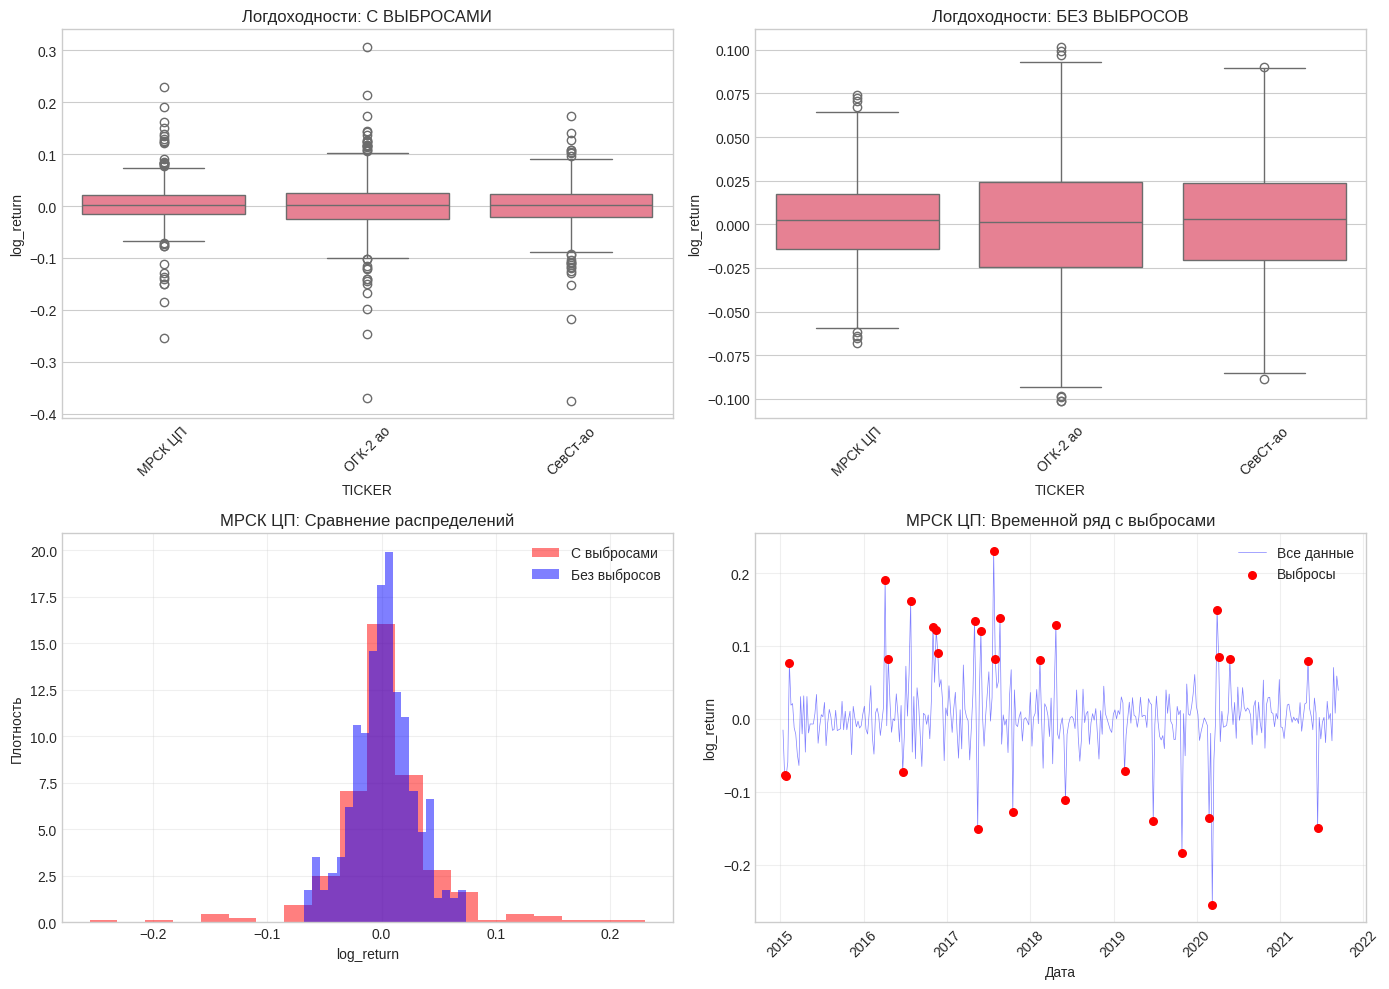



6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
----------------------------------------
✓ Данные без выбросов сохранены в 'data_without_outliers.csv'
✓ Информация о выбросах сохранена в 'outliers_info.csv'
✓ Данные выбросов сохранены в 'outliers_data.csv'

ЗАДАНИЕ 4 ВЫПОЛНЕНО!
Результаты:
1. Определены выбросы для 3 компаний
2. Удалено 83 строк с выбросами
3. Сохранены данные без выбросов
4. Создан график сравнения 'outliers_comparison.png'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind, shapiro, kstest, norm, f_oneway
import warnings
warnings.filterwarnings('ignore')

# Стиль графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 80)
print("ЗАДАНИЕ 4: УДАЛЕНИЕ СТРОК С ВЫБРОСАМИ")
print("=" * 80)

# 1. Загружаем данные с уже вычисленными признаками
print("\n1. ЗАГРУЗКА ДАННЫХ С ВЫЧИСЛЕННЫМИ ПРИЗНАКАМИ")
print("-" * 40)

file_path = 'mfdexport_1week_01012015_19122025 ира.txt'
df = pd.read_csv(file_path, sep=';', encoding='utf-8', decimal=',')
df.columns = ['TICKER', 'PER', 'DATE', 'TIME', 'CLOSE', 'VOL']
df['DATE'] = pd.to_datetime(df['DATE'], format='%d/%m/%y')
df = df.sort_values(['TICKER', 'DATE']).reset_index(drop=True)

# Вычисляем признаки
df['log_price'] = np.log(df['CLOSE'])
df['log_return'] = np.log(df['CLOSE'] / df.groupby('TICKER')['CLOSE'].shift(1))
df['log_volume'] = np.log(df['VOL'] + 1e-10)

# Убираем бесконечные значения
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['log_return'])

companies = df['TICKER'].unique()
print(f"Компании: {companies}")
print(f"Всего наблюдений: {len(df)}")
print(f"Период: {df['DATE'].min().date()} - {df['DATE'].max().date()}")

# 2. Определяем выбросы для каждой компании
print("\n\n2. ОПРЕДЕЛЕНИЕ ВЫБРОСОВ В ЛОГОДОХОДНОСТЯХ")
print("-" * 40)

# Метод IQR для определения выбросов
def identify_outliers(group):
    Q1 = group['log_return'].quantile(0.25)
    Q3 = group['log_return'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = group[(group['log_return'] < lower_bound) | (group['log_return'] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("Выбросы по методу IQR (Q1 - 1.5*IQR, Q3 + 1.5*IQR):")

outliers_info = []
for company in companies:
    company_data = df[df['TICKER'] == company]
    outliers, lower, upper = identify_outliers(company_data)

    print(f"\n{company}:")
    print(f"  Границы: [{lower:.6f}, {upper:.6f}]")
    print(f"  Выбросов: {len(outliers)} из {len(company_data)} ({len(outliers)/len(company_data)*100:.1f}%)")

    if len(outliers) > 0:
        print(f"  Примеры выбросов:")
        for i, (_, row) in enumerate(outliers.head(3).iterrows(), 1):
            print(f"    {i}. {row['DATE'].date()}: {row['log_return']:.6f}")

    outliers_info.append({
        'Компания': company,
        'Наблюдений всего': len(company_data),
        'Выбросов': len(outliers),
        'Доля выбросов': f"{len(outliers)/len(company_data)*100:.1f}%",
        'Нижняя граница': lower,
        'Верхняя граница': upper
    })

# 3. Удаляем строки с выбросами
print("\n\n3. УДАЛЕНИЕ СТРОК С ВЫБРОСАМИ")
print("-" * 40)

def remove_outliers(group):
    Q1 = group['log_return'].quantile(0.25)
    Q3 = group['log_return'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Оставляем только НЕ выбросы
    return group[(group['log_return'] >= lower) & (group['log_return'] <= upper)]

# Создаем DataFrame без выбросов
df_no_outliers = df.groupby('TICKER', group_keys=False).apply(remove_outliers)

print(f"Было наблюдений: {len(df)}")
print(f"Стало наблюдений: {len(df_no_outliers)}")
print(f"Удалено строк: {len(df) - len(df_no_outliers)}")
print(f"Доля удаленных: {((len(df)-len(df_no_outliers))/len(df)*100):.1f}%")

# Сохраняем выбросы отдельно
outliers_df = df[~df.index.isin(df_no_outliers.index)]
print(f"\nВыбросы сохранены ({len(outliers_df)} строк)")

# 4. Сравнение статистик до и после удаления
print("\n\n4. СРАВНЕНИЕ СТАТИСТИК ДО И ПОСЛЕ УДАЛЕНИЯ")
print("-" * 40)

comparison_data = []
for company in companies:
    # Статистика с выбросами
    data_with = df[df['TICKER'] == company]['log_return']

    # Статистика без выбросов
    data_without = df_no_outliers[df_no_outliers['TICKER'] == company]['log_return']

    comparison_data.append({
        'Компания': company,
        'Наблюдений с': len(data_with),
        'Наблюдений без': len(data_without),
        'μ с': data_with.mean(),
        'μ без': data_without.mean(),
        'σ с': data_with.std(),
        'σ без': data_without.std(),
        'Асим. с': data_with.skew(),
        'Асим. без': data_without.skew(),
        'Эксц. с': data_with.kurtosis(),
        'Эксц. без': data_without.kurtosis()
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nСравнение статистик:")
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

# 5. Визуализация: сравнение boxplots
print("\n\n5. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot до удаления
sns.boxplot(data=df, x='TICKER', y='log_return', ax=axes[0, 0])
axes[0, 0].set_title('Логдоходности: С ВЫБРОСАМИ')
axes[0, 0].set_ylabel('log_return')
axes[0, 0].tick_params(axis='x', rotation=45)

# Boxplot после удаления
sns.boxplot(data=df_no_outliers, x='TICKER', y='log_return', ax=axes[0, 1])
axes[0, 1].set_title('Логдоходности: БЕЗ ВЫБРОСОВ')
axes[0, 1].set_ylabel('log_return')
axes[0, 1].tick_params(axis='x', rotation=45)

# Гистограмма сравнения для одной компании (первой)
if len(companies) > 0:
    company = companies[0]
    data_with = df[df['TICKER'] == company]['log_return']
    data_without = df_no_outliers[df_no_outliers['TICKER'] == company]['log_return']

    axes[1, 0].hist(data_with, bins=20, alpha=0.5, label='С выбросами', color='red', density=True)
    axes[1, 0].hist(data_without, bins=20, alpha=0.5, label='Без выбросов', color='blue', density=True)
    axes[1, 0].set_title(f'{company}: Сравнение распределений')
    axes[1, 0].set_xlabel('log_return')
    axes[1, 0].set_ylabel('Плотность')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# График временных рядов с выделением выбросов
if len(companies) > 0:
    company = companies[0]
    company_data = df[df['TICKER'] == company]
    company_outliers = outliers_df[outliers_df['TICKER'] == company]

    axes[1, 1].plot(company_data['DATE'], company_data['log_return'],
                   'b-', alpha=0.5, label='Все данные', linewidth=0.5)
    axes[1, 1].scatter(company_outliers['DATE'], company_outliers['log_return'],
                      color='red', s=30, label='Выбросы', zorder=5)
    axes[1, 1].set_title(f'{company}: Временной ряд с выбросами')
    axes[1, 1].set_xlabel('Дата')
    axes[1, 1].set_ylabel('log_return')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outliers_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Сохраняем результаты
print("\n\n6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("-" * 40)

# Сохраняем данные без выбросов
df_no_outliers.to_csv('data_without_outliers.csv', index=False, encoding='utf-8')
print("✓ Данные без выбросов сохранены в 'data_without_outliers.csv'")

# Сохраняем информацию о выбросах
outliers_info_df = pd.DataFrame(outliers_info)
outliers_info_df.to_csv('outliers_info.csv', index=False, encoding='utf-8')
print("✓ Информация о выбросах сохранена в 'outliers_info.csv'")

# Сохраняем выбросы
outliers_df.to_csv('outliers_data.csv', index=False, encoding='utf-8')
print("✓ Данные выбросов сохранены в 'outliers_data.csv'")

print("\n" + "=" * 80)
print("ЗАДАНИЕ 4 ВЫПОЛНЕНО!")
print("=" * 80)
print("Результаты:")
print(f"1. Определены выбросы для {len(companies)} компаний")
print(f"2. Удалено {len(df) - len(df_no_outliers)} строк с выбросами")
print(f"3. Сохранены данные без выбросов")
print(f"4. Создан график сравнения 'outliers_comparison.png'")

5.

ЗАДАНИЕ 5: ПОВТОРНЫЙ АНАЛИЗ БЕЗ ВЫБРОСОВ

1. ЗАГРУЗКА ДАННЫХ БЕЗ ВЫБРОСОВ
----------------------------------------
Компании: ['МРСК ЦП' 'ОГК-2 ао' 'СевСт-ао']
Наблюдений: 1401
Период: 2015-01-12 - 2025-12-15


2. ОПИСАТЕЛЬНАЯ СТАТИСТИКА БЕЗ ВЫБРОСОВ
----------------------------------------

МРСК ЦП:
  Наблюдений: 319
  log_return: μ=0.001633, σ=0.026562
  log_price: μ=-1.742483, σ=0.573980
  Асимметрия: -0.027
  Эксцесс: 0.241

ОГК-2 ао:
  Наблюдений: 536
  log_return: μ=0.000574, σ=0.037596
  log_price: μ=-0.773251, σ=0.361908
  Асимметрия: -0.092
  Эксцесс: 0.152

СевСт-ао:
  Наблюдений: 546
  log_return: μ=0.002940, σ=0.035199
  log_price: μ=6.910405, σ=0.285723
  Асимметрия: -0.003
  Эксцесс: -0.126


3. ДИАГРАММЫ 'ЯЩИК С УСАМИ' БЕЗ ВЫБРОСОВ
----------------------------------------


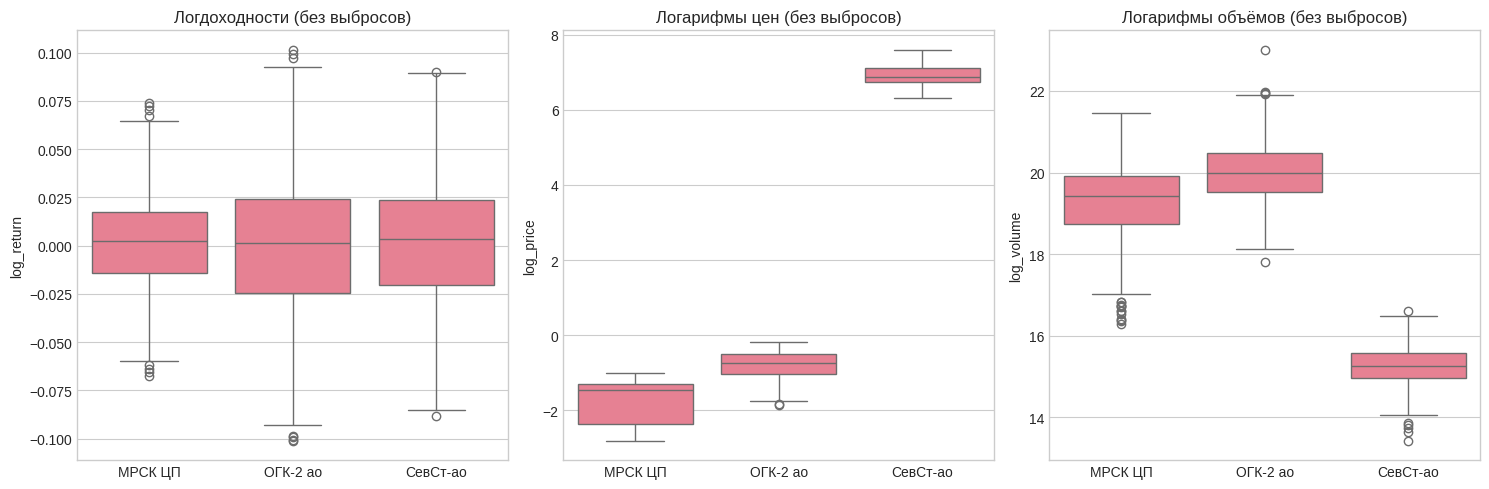



4. ДИАГРАММЫ РАССЕЯНИЯ БЕЗ ВЫБРОСОВ
----------------------------------------


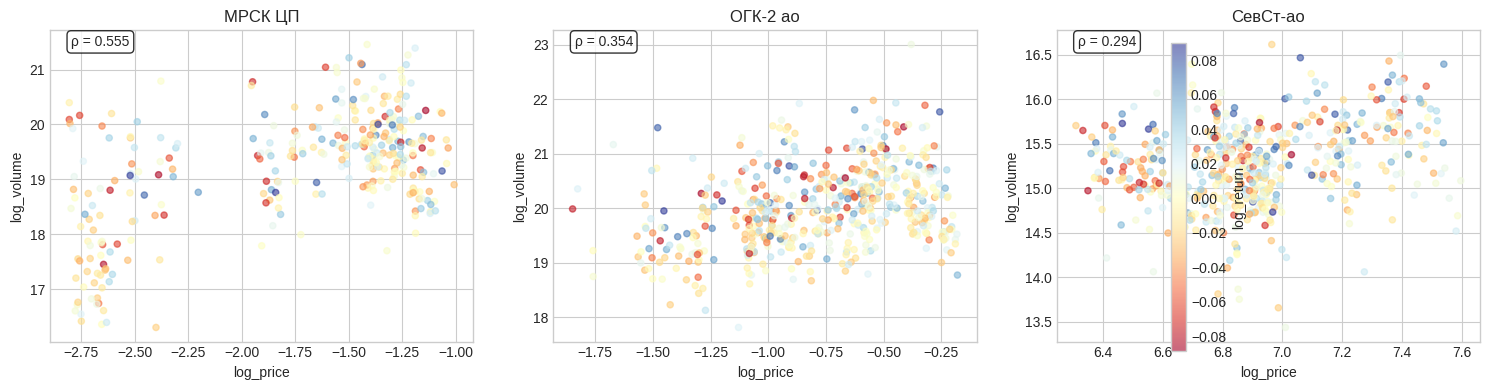



5. ГИСТОГРАММЫ ИНТЕРВАЛЬНЫХ ЧАСТОТ БЕЗ ВЫБРОСОВ
----------------------------------------


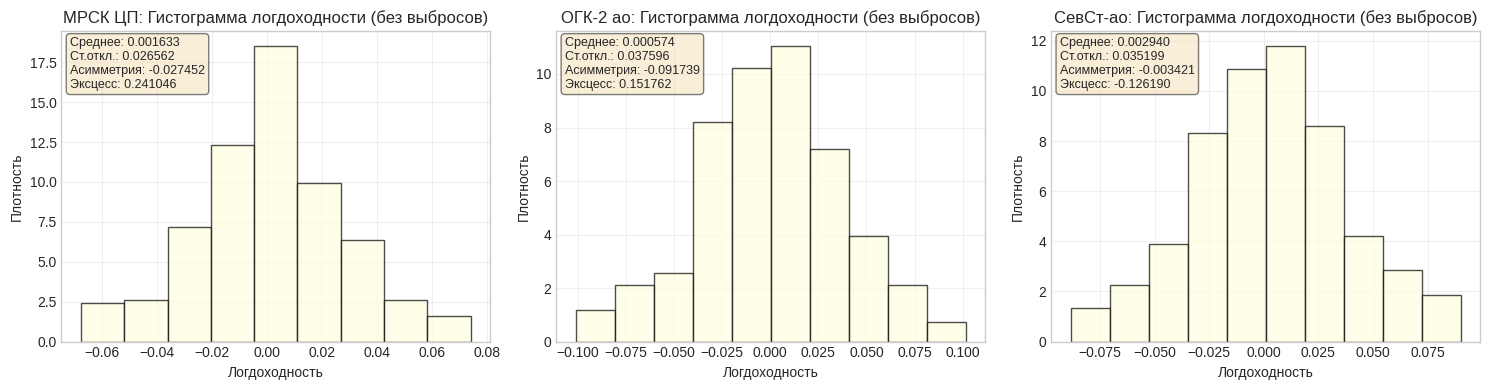



6. ЭМПИРИЧЕСКАЯ ФУНКЦИЯ РАСПРЕДЕЛЕНИЯ
----------------------------------------


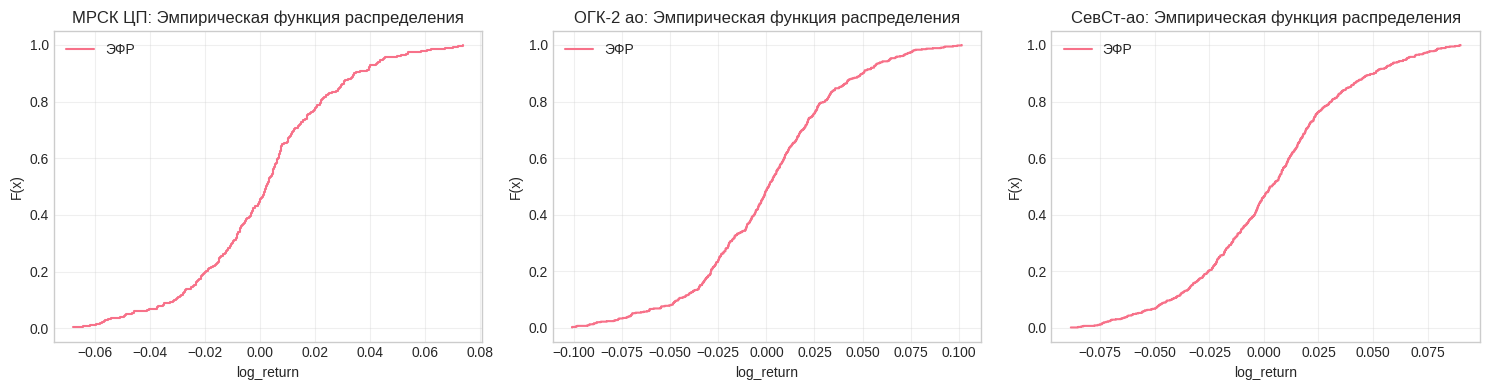



7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
----------------------------------------
✓ Данные сохранены в 'data_cleaned_for_analysis.csv'
✓ Описательная статистика сохранена в 'descriptive_stats_no_outliers.csv'

ЗАДАНИЕ 5 ВЫПОЛНЕНО!
Созданы файлы:
✓ data_cleaned_for_analysis.csv - данные без выбросов
✓ descriptive_stats_no_outliers.csv - описательная статистика
✓ boxplots_no_outliers.png - ящики с усами
✓ scatter_no_outliers.png - диаграммы рассеяния
✓ histograms_no_outliers.png - гистограммы
✓ empirical_distribution.png - эмпирические функции распределения


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind, shapiro, kstest, norm, f_oneway
import warnings
warnings.filterwarnings('ignore')

# Настройки
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 80)
print("ЗАДАНИЕ 5: ПОВТОРНЫЙ АНАЛИЗ БЕЗ ВЫБРОСОВ")
print("=" * 80)

# 1. Загружаем данные БЕЗ выбросов
print("\n1. ЗАГРУЗКА ДАННЫХ БЕЗ ВЫБРОСОВ")
print("-" * 40)

# Загружаем исходные данные
file_path = 'mfdexport_1week_01012015_19122025 ира.txt'
df = pd.read_csv(file_path, sep=';', encoding='utf-8', decimal=',')
df.columns = ['TICKER', 'PER', 'DATE', 'TIME', 'CLOSE', 'VOL']
df['DATE'] = pd.to_datetime(df['DATE'], format='%d/%m/%y')
df = df.sort_values(['TICKER', 'DATE']).reset_index(drop=True)

# Вычисляем признаки
df['log_price'] = np.log(df['CLOSE'])
df['log_return'] = np.log(df['CLOSE'] / df.groupby('TICKER')['CLOSE'].shift(1))
df['log_volume'] = np.log(df['VOL'] + 1e-10)

# Убираем бесконечные значения
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['log_return'])

# Удаляем выбросы
def remove_outliers(group):
    Q1 = group['log_return'].quantile(0.25)
    Q3 = group['log_return'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group['log_return'] >= lower) & (group['log_return'] <= upper)]

df_clean = df.groupby('TICKER', group_keys=False).apply(remove_outliers)

companies = df_clean['TICKER'].unique()
print(f"Компании: {companies}")
print(f"Наблюдений: {len(df_clean)}")
print(f"Период: {df_clean['DATE'].min().date()} - {df_clean['DATE'].max().date()}")

# 2. ОПИСАТЕЛЬНАЯ СТАТИСТИКА (без выбросов)
print("\n\n2. ОПИСАТЕЛЬНАЯ СТАТИСТИКА БЕЗ ВЫБРОСОВ")
print("-" * 40)

for company in companies:
    company_data = df_clean[df_clean['TICKER'] == company]
    print(f"\n{company}:")
    print(f"  Наблюдений: {len(company_data)}")
    print(f"  log_return: μ={company_data['log_return'].mean():.6f}, σ={company_data['log_return'].std():.6f}")
    print(f"  log_price: μ={company_data['log_price'].mean():.6f}, σ={company_data['log_price'].std():.6f}")
    print(f"  Асимметрия: {company_data['log_return'].skew():.3f}")
    print(f"  Эксцесс: {company_data['log_return'].kurtosis():.3f}")

# 3. ВЫБРОСЫ И ЯЩИКИ С УСАМИ (после очистки)
print("\n\n3. ДИАГРАММЫ 'ЯЩИК С УСАМИ' БЕЗ ВЫБРОСОВ")
print("-" * 40)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Логдоходности
sns.boxplot(data=df_clean, x='TICKER', y='log_return', ax=axes[0])
axes[0].set_title('Логдоходности (без выбросов)')
axes[0].set_ylabel('log_return')
axes[0].set_xlabel('')

# Логарифмы цен
sns.boxplot(data=df_clean, x='TICKER', y='log_price', ax=axes[1])
axes[1].set_title('Логарифмы цен (без выбросов)')
axes[1].set_ylabel('log_price')
axes[1].set_xlabel('')

# Логарифмы объёмов
sns.boxplot(data=df_clean, x='TICKER', y='log_volume', ax=axes[2])
axes[2].set_title('Логарифмы объёмов (без выбросов)')
axes[2].set_ylabel('log_volume')
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('boxplots_no_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. ДИАГРАММЫ РАССЕЯНИЯ (без выбросов)
print("\n\n4. ДИАГРАММЫ РАССЕЯНИЯ БЕЗ ВЫБРОСОВ")
print("-" * 40)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, company in enumerate(companies):
    company_data = df_clean[df_clean['TICKER'] == company]

    scatter = axes[idx].scatter(company_data['log_price'], company_data['log_volume'],
                               alpha=0.6, s=20, c=company_data['log_return'], cmap='RdYlBu')
    axes[idx].set_title(company)
    axes[idx].set_xlabel('log_price')
    axes[idx].set_ylabel('log_volume')

    # Корреляция
    corr = company_data['log_price'].corr(company_data['log_volume'])
    axes[idx].text(0.05, 0.95, f'ρ = {corr:.3f}',
                  transform=axes[idx].transAxes, fontsize=10,
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.colorbar(scatter, ax=axes.ravel().tolist()).set_label('log_return')
plt.tight_layout()
plt.savefig('scatter_no_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. ГИСТОГРАММЫ ИНТЕРВАЛЬНЫХ ЧАСТОТ БЕЗ ВЫБРОСОВ (правильно)
print("\n\n5. ГИСТОГРАММЫ ИНТЕРВАЛЬНЫХ ЧАСТОТ БЕЗ ВЫБРОСОВ")
print("-" * 40)

fig, axes = plt.subplots(1, len(companies), figsize=(5*len(companies), 4))

if len(companies) == 1:
    axes = [axes]

for idx, company in enumerate(companies):
    company_data = df_clean[df_clean['TICKER'] == company]

    # Оптимальное количество бинов
    n = len(company_data)
    n_bins = int(1 + 3.322 * np.log10(n)) if n > 0 else 10

    # Гистограмма логдоходности
    axes[idx].hist(company_data['log_return'], bins=n_bins,
                   edgecolor='black', alpha=0.7, color='lightyellow', density=True)
    axes[idx].set_title(f'{company}: Гистограмма логдоходности (без выбросов)')
    axes[idx].set_xlabel('Логдоходность')
    axes[idx].set_ylabel('Плотность')
    axes[idx].grid(True, alpha=0.3)

    # Добавляем информацию о статистиках
    stats_text = (f'Среднее: {company_data["log_return"].mean():.6f}\n'
                  f'Ст.откл.: {company_data["log_return"].std():.6f}\n'
                  f'Асимметрия: {company_data["log_return"].skew():.6f}\n'
                  f'Эксцесс: {company_data["log_return"].kurtosis():.6f}')

    axes[idx].text(0.02, 0.98, stats_text, transform=axes[idx].transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('histograms_no_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. ЭМПИРИЧЕСКАЯ ФУНКЦИЯ РАСПРЕДЕЛЕНИЯ
print("\n\n6. ЭМПИРИЧЕСКАЯ ФУНКЦИЯ РАСПРЕДЕЛЕНИЯ")
print("-" * 40)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, company in enumerate(companies):
    company_data = df_clean[df_clean['TICKER'] == company]
    returns = company_data['log_return'].sort_values()

    # ЭФР
    y = np.arange(1, len(returns) + 1) / len(returns)

    axes[idx].step(returns, y, where='post', label='ЭФР', linewidth=1.5)
    axes[idx].set_title(f'{company}: Эмпирическая функция распределения')
    axes[idx].set_xlabel('log_return')
    axes[idx].set_ylabel('F(x)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('empirical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n\n7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("-" * 40)

# Сохраняем данные
df_clean.to_csv('data_cleaned_for_analysis.csv', index=False, encoding='utf-8')
print("✓ Данные сохранены в 'data_cleaned_for_analysis.csv'")

# Сохраняем описательную статистику
stats_list = []
for company in companies:
    company_data = df_clean[df_clean['TICKER'] == company]

    stats_dict = {
        'Компания': company,
        'Наблюдений': len(company_data),
        'log_return_mean': company_data['log_return'].mean(),
        'log_return_std': company_data['log_return'].std(),
        'log_price_mean': company_data['log_price'].mean(),
        'log_price_std': company_data['log_price'].std(),
        'log_volume_mean': company_data['log_volume'].mean(),
        'log_volume_std': company_data['log_volume'].std(),
        'skewness': company_data['log_return'].skew(),
        'kurtosis': company_data['log_return'].kurtosis(),
        'min': company_data['log_return'].min(),
        'max': company_data['log_return'].max()
    }
    stats_list.append(stats_dict)

stats_df = pd.DataFrame(stats_list)
stats_df.to_csv('descriptive_stats_no_outliers.csv', index=False, encoding='utf-8')
print("✓ Описательная статистика сохранена в 'descriptive_stats_no_outliers.csv'")

print("\n" + "=" * 80)
print("ЗАДАНИЕ 5 ВЫПОЛНЕНО!")
print("=" * 80)
print("Созданы файлы:")
print("✓ data_cleaned_for_analysis.csv - данные без выбросов")
print("✓ descriptive_stats_no_outliers.csv - описательная статистика")
print("✓ boxplots_no_outliers.png - ящики с усами")
print("✓ scatter_no_outliers.png - диаграммы рассеяния")
print("✓ histograms_no_outliers.png - гистограммы")
print("✓ empirical_distribution.png - эмпирические функции распределения")

6.

ЗАДАНИЕ 6: ДЕТАЛЬНЫЙ АНАЛИЗ ЛОГОДОХОДНОСТЕЙ

1. ЗАГРУЗКА ОЧИЩЕННЫХ ДАННЫХ
----------------------------------------
Компании: ['МРСК ЦП' 'ОГК-2 ао' 'СевСт-ао']
Всего наблюдений: 1401


2. ТОЧЕЧНЫЕ ОЦЕНКИ ПАРАМЕТРОВ
----------------------------------------

МРСК ЦП:
  Объем выборки (n): 319
  Оценка мат. ожидания (μ̂): 0.001633
  Оценка ст. отклонения (σ̂): 0.026562
  Оценка дисперсии (σ̂²): 0.000706

ОГК-2 ао:
  Объем выборки (n): 536
  Оценка мат. ожидания (μ̂): 0.000574
  Оценка ст. отклонения (σ̂): 0.037596
  Оценка дисперсии (σ̂²): 0.001413

СевСт-ао:
  Объем выборки (n): 546
  Оценка мат. ожидания (μ̂): 0.002940
  Оценка ст. отклонения (σ̂): 0.035199
  Оценка дисперсии (σ̂²): 0.001239

Сводная таблица точечных оценок:
Компания  μ̂ (оценка μ)  σ̂ (оценка σ)  σ̂² (оценка σ²)  n (объем выборки)
 МРСК ЦП       0.001633       0.026562         0.000706                319
ОГК-2 ао       0.000574       0.037596         0.001413                536
СевСт-ао       0.002940       0.035199     

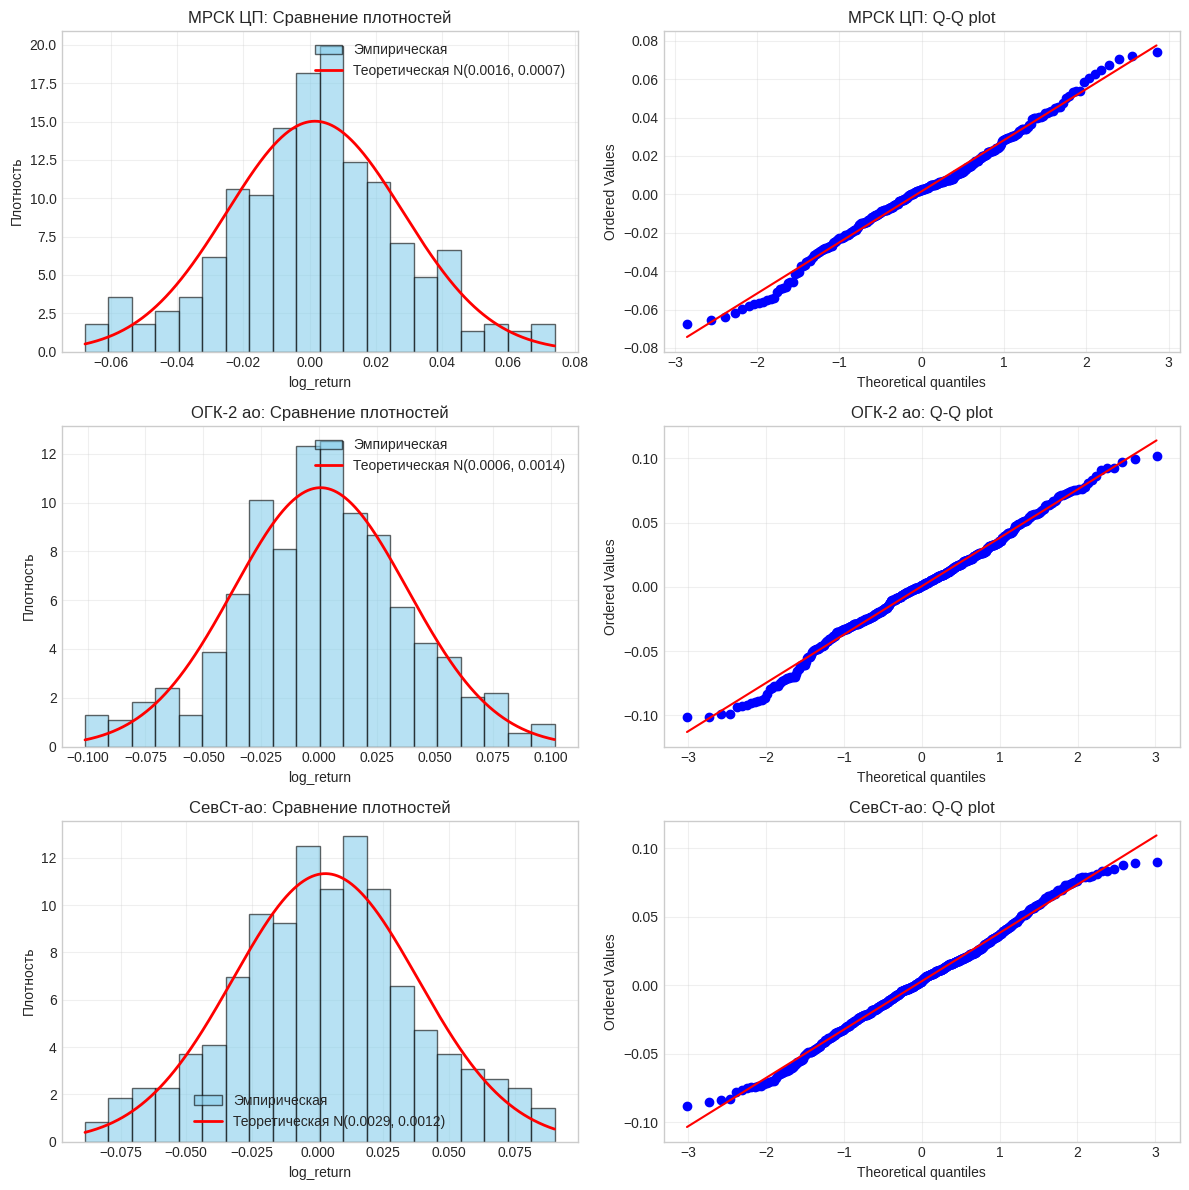



5. ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ РИСКА И ДОХОДНОСТИ
----------------------------------------

МРСК ЦП:
  Коэффициент вариации (CV): 16.2654
  Коэффициент Шарпа: 0.0615
  Отношение доходность/риск (μ/σ): 0.0615
  95% ДИ для μ содержит 0: Да

ОГК-2 ао:
  Коэффициент вариации (CV): 65.4480
  Коэффициент Шарпа: 0.0153
  Отношение доходность/риск (μ/σ): 0.0153
  95% ДИ для μ содержит 0: Да

СевСт-ао:
  Коэффициент вариации (CV): 11.9709
  Коэффициент Шарпа: 0.0835
  Отношение доходность/риск (μ/σ): 0.0835
  95% ДИ для μ содержит 0: Да

Сводная таблица метрик риска:
Компания  Коэфф. вариации (CV)  Коэфф. Шарпа  μ/σ (отношение) ДИ содержит 0?        Границы ДИ
 МРСК ЦП             16.265352      0.061480         0.061480             Да [-0.0013, 0.0046]
ОГК-2 ао             65.447959      0.015279         0.015279             Да [-0.0026, 0.0038]
СевСт-ао             11.970852      0.083536         0.083536             Да [-0.0000, 0.0059]


6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
------------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import t, chi2, norm, shapiro, kstest
import warnings
warnings.filterwarnings('ignore')

# Настройки
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 80)
print("ЗАДАНИЕ 6: ДЕТАЛЬНЫЙ АНАЛИЗ ЛОГОДОХОДНОСТЕЙ")
print("=" * 80)

# 1. Загружаем очищенные данные
print("\n1. ЗАГРУЗКА ОЧИЩЕННЫХ ДАННЫХ")
print("-" * 40)

# Загружаем данные с предыдущего этапа
df = pd.read_csv('data_cleaned_for_analysis.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

companies = df['TICKER'].unique()
print(f"Компании: {companies}")
print(f"Всего наблюдений: {len(df)}")

# 2. ТОЧЕЧНЫЕ ОЦЕНКИ ПАРАМЕТРОВ НОРМАЛЬНОГО РАСПРЕДЕЛЕНИЯ
print("\n\n2. ТОЧЕЧНЫЕ ОЦЕНКИ ПАРАМЕТРОВ")
print("-" * 40)

point_estimates = []

for company in companies:
    data = df[df['TICKER'] == company]['log_return'].values

    # Точечные оценки
    mu_hat = np.mean(data)           # Оценка математического ожидания
    sigma_hat = np.std(data, ddof=1) # Оценка стандартного отклонения (несмещенная)
    var_hat = np.var(data, ddof=1)   # Оценка дисперсии

    point_estimates.append({
        'Компания': company,
        'μ̂ (оценка μ)': mu_hat,
        'σ̂ (оценка σ)': sigma_hat,
        'σ̂² (оценка σ²)': var_hat,
        'n (объем выборки)': len(data)
    })

    print(f"\n{company}:")
    print(f"  Объем выборки (n): {len(data)}")
    print(f"  Оценка мат. ожидания (μ̂): {mu_hat:.6f}")
    print(f"  Оценка ст. отклонения (σ̂): {sigma_hat:.6f}")
    print(f"  Оценка дисперсии (σ̂²): {var_hat:.6f}")

point_df = pd.DataFrame(point_estimates)
print("\nСводная таблица точечных оценок:")
print(point_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

# 3. ИНТЕРВАЛЬНЫЕ ОЦЕНКИ ПАРАМЕТРОВ (95% доверительный интервал)
print("\n\n3. ИНТЕРВАЛЬНЫЕ ОЦЕНКИ (95% доверительный интервал)")
print("-" * 40)

interval_estimates = []

for company in companies:
    data = df[df['TICKER'] == company]['log_return'].values
    n = len(data)
    mu_hat = np.mean(data)
    sigma_hat = np.std(data, ddof=1)
    alpha = 0.05  # 95% доверительный интервал

    # 3.1 Доверительный интервал для математического ожидания (μ)
    # Используем t-распределение, т.к. σ неизвестна
    t_critical = t.ppf(1 - alpha/2, n-1)
    se_mean = sigma_hat / np.sqrt(n)  # стандартная ошибка среднего
    ci_mean_lower = mu_hat - t_critical * se_mean
    ci_mean_upper = mu_hat + t_critical * se_mean

    # 3.2 Доверительный интервал для дисперсии (σ²)
    # Используем хи-квадрат распределение
    chi2_lower = chi2.ppf(1 - alpha/2, n-1)
    chi2_upper = chi2.ppf(alpha/2, n-1)
    ci_var_lower = (n-1) * sigma_hat**2 / chi2_lower
    ci_var_upper = (n-1) * sigma_hat**2 / chi2_upper

    # 3.3 Доверительный интервал для стандартного отклонения (σ)
    ci_std_lower = np.sqrt(ci_var_lower)
    ci_std_upper = np.sqrt(ci_var_upper)

    interval_estimates.append({
        'Компания': company,
        'ДИ для μ (нижн.)': ci_mean_lower,
        'ДИ для μ (верхн.)': ci_mean_upper,
        'Ширина ДИ μ': ci_mean_upper - ci_mean_lower,
        'ДИ для σ (нижн.)': ci_std_lower,
        'ДИ для σ (верхн.)': ci_std_upper,
        'Ширина ДИ σ': ci_std_upper - ci_std_lower
    })

    print(f"\n{company}:")
    print(f"  Доверительный интервал для μ (мат. ожидания):")
    print(f"    [{ci_mean_lower:.6f}, {ci_mean_upper:.6f}]")
    print(f"    Ширина: {ci_mean_upper - ci_mean_lower:.6f}")
    print(f"  Доверительный интервал для σ (ст. отклонения):")
    print(f"    [{ci_std_lower:.6f}, {ci_std_upper:.6f}]")
    print(f"    Ширина: {ci_std_upper - ci_std_lower:.6f}")

interval_df = pd.DataFrame(interval_estimates)
print("\nСводная таблица интервальных оценок:")
print(interval_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

# 4. ГРАФИКИ: ГИСТОГРАММА ЭМПИРИЧЕСКОЙ ПЛОТНОСТИ + ТЕОРЕТИЧЕСКАЯ ПЛОТНОСТЬ
print("\n\n4. СРАВНЕНИЕ ЭМПИРИЧЕСКОЙ И ТЕОРЕТИЧЕСКОЙ ПЛОТНОСТЕЙ")
print("-" * 40)

fig, axes = plt.subplots(len(companies), 2, figsize=(12, 4*len(companies)))

if len(companies) == 1:
    axes = axes.reshape(1, -1)

for row, company in enumerate(companies):
    data = df[df['TICKER'] == company]['log_return'].values
    mu_hat = np.mean(data)
    sigma_hat = np.std(data, ddof=1)

    # 4.1 Гистограмма + теоретическая плотность
    axes[row, 0].hist(data, bins=20, density=True, alpha=0.6,
                     color='skyblue', edgecolor='black', label='Эмпирическая')

    # Теоретическая нормальная плотность
    x = np.linspace(data.min(), data.max(), 1000)
    pdf = norm.pdf(x, mu_hat, sigma_hat)
    axes[row, 0].plot(x, pdf, 'r-', linewidth=2,
                     label=f'Теоретическая N({mu_hat:.4f}, {sigma_hat**2:.4f})')

    axes[row, 0].set_title(f'{company}: Сравнение плотностей')
    axes[row, 0].set_xlabel('log_return')
    axes[row, 0].set_ylabel('Плотность')
    axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)

    # 4.2 Q-Q plot для проверки нормальности
    stats.probplot(data, dist="norm", plot=axes[row, 1])
    axes[row, 1].set_title(f'{company}: Q-Q plot')
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('density_comparison_qq.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: КОЭФФИЦИЕНТ ВАРИАЦИИ И ДРУГИЕ МЕТРИКИ
print("\n\n5. ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ РИСКА И ДОХОДНОСТИ")
print("-" * 40)

risk_metrics = []

for company in companies:
    data = df[df['TICKER'] == company]['log_return'].values
    mu_hat = np.mean(data)
    sigma_hat = np.std(data, ddof=1)

    # Коэффициент вариации (CV) - относительная мера риска
    cv = sigma_hat / abs(mu_hat) if mu_hat != 0 else np.inf

    # Коэффициент Шарпа (упрощенный, без безрисковой ставки)
    sharpe_ratio = mu_hat / sigma_hat if sigma_hat != 0 else np.inf

    # Доверительный интервал для среднего (практическая значимость)
    # Проверяем, содержит ли ДИ для μ ноль
    n = len(data)
    t_critical = t.ppf(0.975, n-1)  # 95% ДИ
    ci_lower = mu_hat - t_critical * sigma_hat / np.sqrt(n)
    ci_upper = mu_hat + t_critical * sigma_hat / np.sqrt(n)
    contains_zero = ci_lower <= 0 <= ci_upper

    risk_metrics.append({
        'Компания': company,
        'Коэфф. вариации (CV)': cv,
        'Коэфф. Шарпа': sharpe_ratio,
        'μ/σ (отношение)': mu_hat / sigma_hat,
        'ДИ содержит 0?': 'Да' if contains_zero else 'Нет',
        'Границы ДИ': f"[{ci_lower:.4f}, {ci_upper:.4f}]"
    })

    print(f"\n{company}:")
    print(f"  Коэффициент вариации (CV): {cv:.4f}")
    print(f"  Коэффициент Шарпа: {sharpe_ratio:.4f}")
    print(f"  Отношение доходность/риск (μ/σ): {mu_hat/sigma_hat:.4f}")
    print(f"  95% ДИ для μ содержит 0: {'Да' if contains_zero else 'Нет'}")

risk_df = pd.DataFrame(risk_metrics)
print("\nСводная таблица метрик риска:")
print(risk_df.to_string(index=False))

# 6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n\n6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("-" * 40)

# Сохраняем точечные оценки
point_df.to_csv('point_estimates.csv', index=False, encoding='utf-8')
print("✓ Точечные оценки сохранены в 'point_estimates.csv'")

# Сохраняем интервальные оценки
interval_df.to_csv('interval_estimates.csv', index=False, encoding='utf-8')
print("✓ Интервальные оценки сохранены в 'interval_estimates.csv'")

# Сохраняем метрики риска
risk_df.to_csv('risk_metrics.csv', index=False, encoding='utf-8')
print("✓ Метрики риска сохранены в 'risk_metrics.csv'")

print("\n" + "=" * 80)
print("ЗАДАНИЕ 6 ВЫПОЛНЕНО!")
print("=" * 80)
print("Результаты:")
print("1. Вычислены точечные оценки параметров нормального распределения")
print("2. Построены 95% доверительные интервалы для μ и σ")
print("3. Созданы графики сравнения эмпирической и теоретической плотностей")
print("4. Рассчитаны дополнительные метрики риска и доходности")
print("5. Все результаты сохранены в CSV файлы")
print("6. Создан график 'density_comparison_qq.png'")

7.

ЗАДАНИЕ 7: ПРОВЕРКА ГИПОТЕЗЫ О НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ

1. ЗАГРУЗКА ДАННЫХ
----------------------------------------
Компании: ['МРСК ЦП' 'ОГК-2 ао' 'СевСт-ао']
Всего наблюдений: 1401


2. ЭМПИРИЧЕСКАЯ И ТЕОРЕТИЧЕСКАЯ ФУНКЦИИ РАСПРЕДЕЛЕНИЯ
----------------------------------------


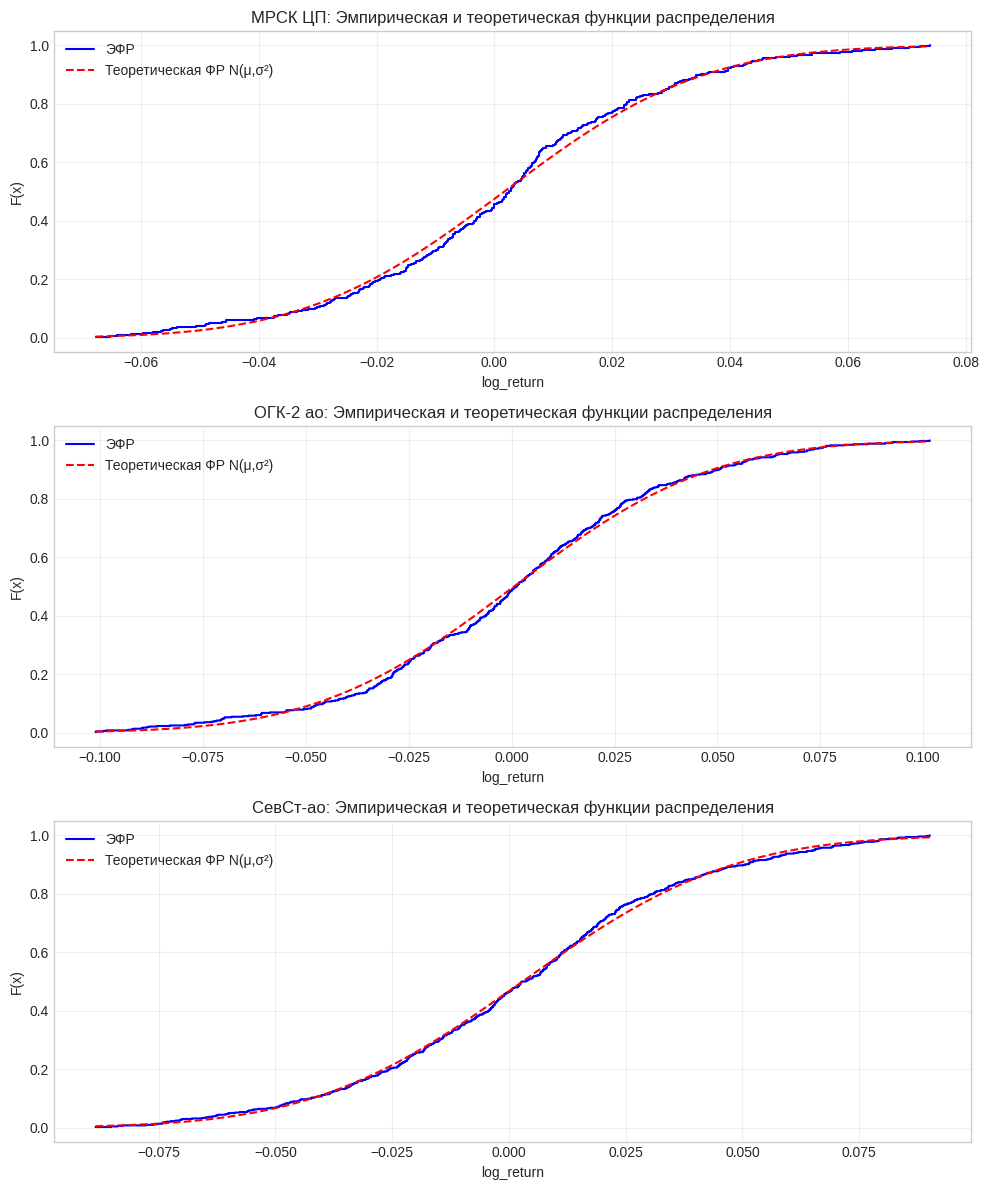



3. КРИТЕРИЙ χ² ПИРСОНА ДЛЯ ПРОВЕРКИ НОРМАЛЬНОСТИ
----------------------------------------

МРСК ЦП:
  χ² статистика: 21.4702
  Степени свободы: 7
  p-value: 0.003133
  При α=0.05: Нормальность отвергается
  При α=0.01: Нормальность отвергается

ОГК-2 ао:
  χ² статистика: 16.3134
  Степени свободы: 7
  p-value: 0.022402
  При α=0.05: Нормальность отвергается
  При α=0.01: Нормальность не отвергается

СевСт-ао:
  χ² статистика: 7.9194
  Степени свободы: 7
  p-value: 0.339754
  При α=0.05: Нормальность не отвергается
  При α=0.01: Нормальность не отвергается

Сводная таблица по критерию χ² Пирсона:
Компания  χ² статистика  Степени свободы  p-value                    α = 0.05                    α = 0.01
 МРСК ЦП      21.470219                7 0.003133    Нормальность отвергается    Нормальность отвергается
ОГК-2 ао      16.313433                7 0.022402    Нормальность отвергается Нормальность не отвергается
СевСт-ао       7.919414                7 0.339754 Нормальность не отвергается

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, kstest, norm, shapiro
import warnings
warnings.filterwarnings('ignore')

# Настройки
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 80)
print("ЗАДАНИЕ 7: ПРОВЕРКА ГИПОТЕЗЫ О НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ")
print("=" * 80)

# 1. Загружаем очищенные данные
print("\n1. ЗАГРУЗКА ДАННЫХ")
print("-" * 40)

df = pd.read_csv('data_cleaned_for_analysis.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

companies = df['TICKER'].unique()
print(f"Компании: {companies}")
print(f"Всего наблюдений: {len(df)}")

# 2. ПОДГОТОВКА: ЭМПИРИЧЕСКАЯ И ТЕОРЕТИЧЕСКАЯ ФУНКЦИИ РАСПРЕДЕЛЕНИЯ
print("\n\n2. ЭМПИРИЧЕСКАЯ И ТЕОРЕТИЧЕСКАЯ ФУНКЦИИ РАСПРЕДЕЛЕНИЯ")
print("-" * 40)

fig, axes = plt.subplots(len(companies), 1, figsize=(10, 4*len(companies)))

if len(companies) == 1:
    axes = [axes]

for idx, company in enumerate(companies):
    data = df[df['TICKER'] == company]['log_return'].values
    data_sorted = np.sort(data)

    # Параметры нормального распределения
    mu = np.mean(data)
    sigma = np.std(data, ddof=1)

    # Эмпирическая функция распределения (ЭФР)
    n = len(data)
    ecdf = np.arange(1, n + 1) / n

    # Теоретическая функция распределения (ФР нормального распределения)
    cdf = norm.cdf(data_sorted, mu, sigma)

    # График
    axes[idx].step(data_sorted, ecdf, 'b-', where='post', linewidth=1.5, label='ЭФР')
    axes[idx].plot(data_sorted, cdf, 'r--', linewidth=1.5, label='Теоретическая ФР N(μ,σ²)')
    axes[idx].set_title(f'{company}: Эмпирическая и теоретическая функции распределения')
    axes[idx].set_xlabel('log_return')
    axes[idx].set_ylabel('F(x)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ecdf_vs_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. КРИТЕРИЙ χ² ПИРСОНА
print("\n\n3. КРИТЕРИЙ χ² ПИРСОНА ДЛЯ ПРОВЕРКИ НОРМАЛЬНОСТИ")
print("-" * 40)

chi2_results = []

for company in companies:
    data = df[df['TICKER'] == company]['log_return'].values
    n = len(data)
    mu = np.mean(data)
    sigma = np.std(data, ddof=1)

    # Определяем границы интервалов
    # Используем 10 интервалов (рекомендуется для критерия χ²)
    k = 10  # количество интервалов

    # Границы интервалов по квантилям нормального распределения
    quantiles = np.linspace(0, 1, k + 1)
    bounds = norm.ppf(quantiles, mu, sigma)

    # Наблюдаемые частоты
    observed, _ = np.histogram(data, bins=bounds)

    # Ожидаемые частоты (в предположении нормальности)
    expected = np.ones(k) * n / k

    # Объединяем ячейки с малыми ожидаемыми частотами (<5)
    # Это требование критерия χ²
    observed_adj = []
    expected_adj = []

    for i in range(k):
        if expected[i] >= 5:
            observed_adj.append(observed[i])
            expected_adj.append(expected[i])
        else:
            # Объединяем с соседней ячейкой
            if i < k-1:
                observed[i+1] += observed[i]
                expected[i+1] += expected[i]

    # Критерий χ²
    chi2_stat = np.sum((np.array(observed_adj) - np.array(expected_adj))**2 / np.array(expected_adj))
    df_chi2 = len(observed_adj) - 3  # степени свободы: k - 1 - 2 (оцененные параметры)
    chi2_p_value = 1 - chi2.cdf(chi2_stat, df_chi2)

    chi2_results.append({
        'Компания': company,
        'χ² статистика': chi2_stat,
        'Степени свободы': df_chi2,
        'p-value': chi2_p_value,
        'α = 0.05': 'Нормальность отвергается' if chi2_p_value < 0.05 else 'Нормальность не отвергается',
        'α = 0.01': 'Нормальность отвергается' if chi2_p_value < 0.01 else 'Нормальность не отвергается'
    })

    print(f"\n{company}:")
    print(f"  χ² статистика: {chi2_stat:.4f}")
    print(f"  Степени свободы: {df_chi2}")
    print(f"  p-value: {chi2_p_value:.6f}")
    print(f"  При α=0.05: {'Нормальность отвергается' if chi2_p_value < 0.05 else 'Нормальность не отвергается'}")
    print(f"  При α=0.01: {'Нормальность отвергается' if chi2_p_value < 0.01 else 'Нормальность не отвергается'}")

chi2_df = pd.DataFrame(chi2_results)
print("\nСводная таблица по критерию χ² Пирсона:")
print(chi2_df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))

# 4. КРИТЕРИЙ КОЛМОГОРОВА-СМИРНОВА
print("\n\n4. КРИТЕРИЙ КОЛМОГОРОВА-СМИРНОВА ДЛЯ ПРОВЕРКИ НОРМАЛЬНОСТИ")
print("-" * 40)

ks_results = []

for company in companies:
    data = df[df['TICKER'] == company]['log_return'].values
    mu = np.mean(data)
    sigma = np.std(data, ddof=1)

    # Критерий Колмогорова-Смирнова
    ks_stat, ks_p_value = kstest(data, 'norm', args=(mu, sigma))

    # Критические значения для KS теста
    n = len(data)
    ks_critical_05 = 1.36 / np.sqrt(n)  # для α=0.05
    ks_critical_01 = 1.63 / np.sqrt(n)  # для α=0.01

    ks_results.append({
        'Компания': company,
        'D статистика': ks_stat,
        'p-value': ks_p_value,
        'Крит. знач. (α=0.05)': ks_critical_05,
        'Крит. знач. (α=0.01)': ks_critical_01,
        'α = 0.05': 'Нормальность отвергается' if ks_stat > ks_critical_05 else 'Нормальность не отвергается',
        'α = 0.01': 'Нормальность отвергается' if ks_stat > ks_critical_01 else 'Нормальность не отвергается'
    })

    print(f"\n{company}:")
    print(f"  D статистика: {ks_stat:.6f}")
    print(f"  p-value: {ks_p_value:.6f}")
    print(f"  Критическое значение (α=0.05): {ks_critical_05:.6f}")
    print(f"  Критическое значение (α=0.01): {ks_critical_01:.6f}")
    print(f"  При α=0.05: {'Нормальность отвергается' if ks_stat > ks_critical_05 else 'Нормальность не отвергается'}")
    print(f"  При α=0.01: {'Нормальность отвергается' if ks_stat > ks_critical_01 else 'Нормальность не отвергается'}")

ks_df = pd.DataFrame(ks_results)
print("\nСводная таблица по критерию Колмогорова-Смирнова:")
print(ks_df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))

# 5. СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДВУХ КРИТЕРИЕВ
print("\n\n5. СРАВНЕНИЕ РЕЗУЛЬТАТОВ ПО ДВУМ КРИТЕРИЯМ")
print("-" * 40)

comparison_results = []

for i, company in enumerate(companies):
    chi2_row = chi2_results[i]
    ks_row = ks_results[i]

    # Согласуются ли выводы двух критериев?
    chi2_conclusion_05 = chi2_row['α = 0.05'].startswith('Нормальность отвергается')
    ks_conclusion_05 = ks_row['α = 0.05'].startswith('Нормальность отвергается')
    agree_05 = chi2_conclusion_05 == ks_conclusion_05

    chi2_conclusion_01 = chi2_row['α = 0.01'].startswith('Нормальность отвергается')
    ks_conclusion_01 = ks_row['α = 0.01'].startswith('Нормальность отвергается')
    agree_01 = chi2_conclusion_01 == ks_conclusion_01

    comparison_results.append({
        'Компания': company,
        'χ² p-value': chi2_row['p-value'],
        'KS p-value': ks_row['p-value'],
        'χ² вывод (0.05)': 'Отвергается' if chi2_conclusion_05 else 'Не отвергается',
        'KS вывод (0.05)': 'Отвергается' if ks_conclusion_05 else 'Не отвергается',
        'Согласие (0.05)': 'Да' if agree_05 else 'Нет',
        'χ² вывод (0.01)': 'Отвергается' if chi2_conclusion_01 else 'Не отвергается',
        'KS вывод (0.01)': 'Отвергается' if ks_conclusion_01 else 'Не отвергается',
        'Согласие (0.01)': 'Да' if agree_01 else 'Нет'
    })

    print(f"\n{company}:")
    print(f"  Критерий χ²: p={chi2_row['p-value']:.6f}, вывод: {chi2_row['α = 0.05']}")
    print(f"  Критерий KS: p={ks_row['p-value']:.6f}, вывод: {ks_row['α = 0.05']}")
    print(f"  Согласие выводов (α=0.05): {'ДА' if agree_05 else 'НЕТ'}")
    print(f"  Согласие выводов (α=0.01): {'ДА' if agree_01 else 'НЕТ'}")

comparison_df = pd.DataFrame(comparison_results)
print("\nСводная таблица сравнения критериев:")
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))

# 6. ДОПОЛНИТЕЛЬНО: КРИТЕРИЙ ШАПИРО-УИЛКА (для сравнения)
print("\n\n6. ДОПОЛНИТЕЛЬНО: КРИТЕРИЙ ШАПИРО-УИЛКА")
print("-" * 40)

sw_results = []

for company in companies:
    data = df[df['TICKER'] == company]['log_return'].values

    # Критерий Шапиро-Уилка (подходит для n < 5000)
    if len(data) < 5000:
        sw_stat, sw_p_value = shapiro(data)

        sw_results.append({
            'Компания': company,
            'W статистика': sw_stat,
            'p-value': sw_p_value,
            'α = 0.05': 'Нормальность отвергается' if sw_p_value < 0.05 else 'Нормальность не отвергается',
            'α = 0.01': 'Нормальность отвергается' if sw_p_value < 0.01 else 'Нормальность не отвергается'
        })

        print(f"\n{company}:")
        print(f"  W статистика: {sw_stat:.6f}")
        print(f"  p-value: {sw_p_value:.6f}")
        print(f"  При α=0.05: {'Нормальность отвергается' if sw_p_value < 0.05 else 'Нормальность не отвергается'}")
        print(f"  При α=0.01: {'Нормальность отвергается' if sw_p_value < 0.01 else 'Нормальность не отвергается'}")

if sw_results:
    sw_df = pd.DataFrame(sw_results)
    print("\nСводная таблица по критерию Шапиро-Уилка:")
    print(sw_df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))

# 7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n\n7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("-" * 40)

# Сохраняем все результаты
chi2_df.to_csv('chi2_test_results.csv', index=False, encoding='utf-8')
print("✓ Результаты критерия χ² Пирсона сохранены в 'chi2_test_results.csv'")

ks_df.to_csv('ks_test_results.csv', index=False, encoding='utf-8')
print("✓ Результаты критерия Колмогорова-Смирнова сохранены в 'ks_test_results.csv'")

comparison_df.to_csv('normality_tests_comparison.csv', index=False, encoding='utf-8')
print("✓ Сравнение критериев сохранено в 'normality_tests_comparison.csv'")

if sw_results:
    sw_df.to_csv('shapiro_wilk_results.csv', index=False, encoding='utf-8')
    print("✓ Результаты критерия Шапиро-Уилка сохранены в 'shapiro_wilk_results.csv'")

print("\n" + "=" * 80)
print("ЗАДАНИЕ 7 ВЫПОЛНЕНО!")
print("=" * 80)
print("Выполнено:")
print("1. Построены графики ЭФР и теоретической ФР ('ecdf_vs_cdf.png')")
print("2. Проверка нормальности по критерию χ² Пирсона")
print("3. Проверка нормальности по критерию Колмогорова-Смирнова")
print("4. Сравнение результатов двух критериев")
print("5. Дополнительная проверка критерием Шапиро-Уилка")
print("6. Все результаты сохранены в CSV файлы")

8.

ЗАДАНИЕ 8: ПРОВЕРКА ГИПОТЕЗЫ О МАТЕМАТИЧЕСКОМ ОЖИДАНИИ

1. ЗАГРУЗКА ДАННЫХ
----------------------------------------
Компании: ['МРСК ЦП' 'ОГК-2 ао' 'СевСт-ао']
Всего наблюдений: 1401


2. ФОРМУЛИРОВКА ГИПОТЕЗ
----------------------------------------
Нулевая гипотеза H₀: μ = 0 (мат. ожидание недельной доходности равно 0)
Альтернативная гипотеза H₁: μ > 0 (мат. ожидание недельной доходности больше 0)
Односторонний t-тест (правосторонний)


3. РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ
----------------------------------------

МРСК ЦП:
  Объем выборки (n): 319
  Выборочное среднее (x̄): 0.001633
  Стандартное отклонение (s): 0.026562
  Стандартная ошибка: 0.001487
  t-статистика: 1.0981
  p-value: 0.136501
  Критическое t (α=0.05): 1.6497
  Критическое t (α=0.01): 2.3381
  Нижняя граница 95% ДИ для μ: [-0.000820, ∞)
  Вывод (α=0.05): H₀ не отвергается, μ ≤ 0
  Вывод (α=0.01): H₀ не отвергается, μ ≤ 0

ОГК-2 ао:
  Объем выборки (n): 536
  Выборочное среднее (x̄): 0.000574
  Стандартное отклонение (s): 0

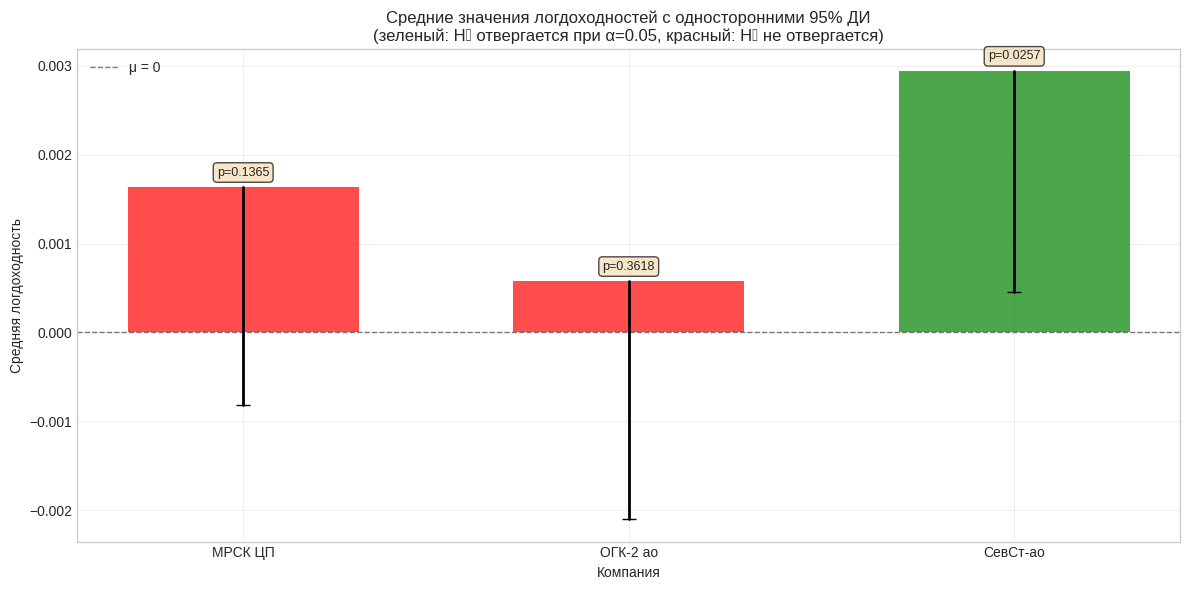



6. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ЭФФЕКТ И МОЩНОСТЬ ТЕСТА
----------------------------------------

Коэффициент Коэна d (стандартизованный размер эффекта):
d = (x̄ - μ₀) / s, где μ₀ = 0

МРСК ЦП:
  Коэффициент Коэна d: 0.0615 (очень маленький эффект)
  Ориентировочная мощность теста (при α=0.05): 29.08%
  Интерпретация: Разница 0.001633 составляет 0.06 стандартных отклонений от нуля

ОГК-2 ао:
  Коэффициент Коэна d: 0.0153 (очень маленький эффект)
  Ориентировочная мощность теста (при α=0.05): 9.81%
  Интерпретация: Разница 0.000574 составляет 0.02 стандартных отклонений от нуля

СевСт-ао:
  Коэффициент Коэна d: 0.0835 (очень маленький эффект)
  Ориентировочная мощность теста (при α=0.05): 61.95%
  Интерпретация: Разница 0.002940 составляет 0.08 стандартных отклонений от нуля


7. ПРОВЕРКА ПРЕДПОСЫЛОК t-ТЕСТА
----------------------------------------
Предпосылки одностороннего t-теста:
1. Независимость наблюдений ✓ (недельные данные)
2. Нормальность распределения (проверено в задании 7)
3. Не

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import ttest_1samp
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("ЗАДАНИЕ 8: ПРОВЕРКА ГИПОТЕЗЫ О МАТЕМАТИЧЕСКОМ ОЖИДАНИИ")
print("=" * 80)

# 1. Загружаем очищенные данные
print("\n1. ЗАГРУЗКА ДАННЫХ")
print("-" * 40)

df = pd.read_csv('data_cleaned_for_analysis.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

companies = df['TICKER'].unique()
print(f"Компании: {companies}")
print(f"Всего наблюдений: {len(df)}")

# 2. ФОРМУЛИРОВКА ГИПОТЕЗ
print("\n\n2. ФОРМУЛИРОВКА ГИПОТЕЗ")
print("-" * 40)
print("Нулевая гипотеза H₀: μ = 0 (мат. ожидание недельной доходности равно 0)")
print("Альтернативная гипотеза H₁: μ > 0 (мат. ожидание недельной доходности больше 0)")
print("Односторонний t-тест (правосторонний)")

# 3. ВЫЧИСЛЕНИЕ СТАТИСТИКИ И P-VALUE
print("\n\n3. РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ")
print("-" * 40)

test_results = []

for company in companies:
    data = df[df['TICKER'] == company]['log_return'].values
    n = len(data)

    # Основные статистики
    sample_mean = np.mean(data)
    sample_std = np.std(data, ddof=1)
    standard_error = sample_std / np.sqrt(n)

    # Односторонний t-тест (H₁: μ > 0)
    t_stat, p_value = ttest_1samp(data, 0, alternative='greater')

    # Критические значения t-распределения
    t_critical_05 = stats.t.ppf(0.95, n-1)  # для α=0.05 (правосторонний)
    t_critical_01 = stats.t.ppf(0.99, n-1)  # для α=0.01 (правосторонний)

    # Стандартная ошибка среднего
    sem = sample_std / np.sqrt(n)

    # Доверительные интервалы (односторонние)
    ci_lower_95 = sample_mean - t_critical_05 * sem  # нижняя граница 95% ДИ
    ci_lower_99 = sample_mean - t_critical_01 * sem  # нижняя граница 99% ДИ

    test_results.append({
        'Компания': company,
        'n': n,
        'Выборочное среднее (x̄)': sample_mean,
        'Стандартное отклонение (s)': sample_std,
        'Стандартная ошибка': sem,
        't-статистика': t_stat,
        'p-value': p_value,
        'Крит. t (α=0.05)': t_critical_05,
        'Крит. t (α=0.01)': t_critical_01,
        'Ниж. граница 95% ДИ': ci_lower_95,
        'Вывод α=0.05': 'H₀ отвергается' if p_value < 0.05 else 'H₀ не отвергается',
        'Вывод α=0.01': 'H₀ отвергается' if p_value < 0.01 else 'H₀ не отвергается'
    })

    print(f"\n{company}:")
    print(f"  Объем выборки (n): {n}")
    print(f"  Выборочное среднее (x̄): {sample_mean:.6f}")
    print(f"  Стандартное отклонение (s): {sample_std:.6f}")
    print(f"  Стандартная ошибка: {sem:.6f}")
    print(f"  t-статистика: {t_stat:.4f}")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Критическое t (α=0.05): {t_critical_05:.4f}")
    print(f"  Критическое t (α=0.01): {t_critical_01:.4f}")
    print(f"  Нижняя граница 95% ДИ для μ: [{ci_lower_95:.6f}, ∞)")
    print(f"  Вывод (α=0.05): {'H₀ отвергается, μ > 0' if p_value < 0.05 else 'H₀ не отвергается, μ ≤ 0'}")
    print(f"  Вывод (α=0.01): {'H₀ отвергается, μ > 0' if p_value < 0.01 else 'H₀ не отвергается, μ ≤ 0'}")

# 4. СВОДНАЯ ТАБЛИЦА
print("\n\n4. СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("-" * 40)

results_df = pd.DataFrame(test_results)
print(results_df[['Компания', 'n', 'Выборочное среднее (x̄)', 't-статистика',
                  'p-value', 'Вывод α=0.05', 'Вывод α=0.01']].to_string(index=False,
                  float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))

# 5. ВИЗУАЛИЗАЦИЯ: ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ
print("\n\n5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("-" * 40)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

x_positions = np.arange(len(companies))
width = 0.3

# Средние значения и доверительные интервалы
means = [r['Выборочное среднее (x̄)'] for r in test_results]
ci_lowers = [r['Ниж. граница 95% ДИ'] for r in test_results]
p_values = [r['p-value'] for r in test_results]

# График средних значений с доверительными интервалами
bars = plt.bar(x_positions, means, width=0.6, alpha=0.7,
               color=['green' if p < 0.05 else 'red' for p in p_values])

# Линия μ = 0
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='μ = 0')

# Стрелки доверительных интервалов (односторонние)
for i, (mean, ci_lower) in enumerate(zip(means, ci_lowers)):
    plt.plot([i, i], [ci_lower, mean], 'k-', linewidth=2)
    plt.plot(i, ci_lower, 'k_', markersize=10)

# Настройки графика
plt.xlabel('Компания')
plt.ylabel('Средняя логдоходность')
plt.title('Средние значения логдоходностей с односторонними 95% ДИ\n(зеленый: H₀ отвергается при α=0.05, красный: H₀ не отвергается)')
plt.xticks(x_positions, companies)
plt.legend()
plt.grid(True, alpha=0.3)

# Добавляем p-values на график
for i, (mean, p_val) in enumerate(zip(means, p_values)):
    plt.text(i, mean + 0.0001, f'p={p_val:.4f}',
             ha='center', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('hypothesis_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: МОЩНОСТЬ ТЕСТА И ЭФФЕКТ
print("\n\n6. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ЭФФЕКТ И МОЩНОСТЬ ТЕСТА")
print("-" * 40)

print("\nКоэффициент Коэна d (стандартизованный размер эффекта):")
print("d = (x̄ - μ₀) / s, где μ₀ = 0")

for i, company in enumerate(companies):
    sample_mean = test_results[i]['Выборочное среднее (x̄)']
    sample_std = test_results[i]['Стандартное отклонение (s)']
    n = test_results[i]['n']

    # Коэффициент Коэна d
    cohen_d = sample_mean / sample_std if sample_std != 0 else 0

    # Интерпретация размера эффекта
    if abs(cohen_d) < 0.2:
        effect_size = "очень маленький"
    elif abs(cohen_d) < 0.5:
        effect_size = "маленький"
    elif abs(cohen_d) < 0.8:
        effect_size = "средний"
    else:
        effect_size = "большой"

    # Ориентировочная мощность теста (при α=0.05)
    # Упрощенная оценка мощности
    power_approx = stats.t.cdf(cohen_d * np.sqrt(n) - stats.t.ppf(0.95, n-1), n-1)

    print(f"\n{company}:")
    print(f"  Коэффициент Коэна d: {cohen_d:.4f} ({effect_size} эффект)")
    print(f"  Ориентировочная мощность теста (при α=0.05): {power_approx:.2%}")
    print(f"  Интерпретация: Разница {abs(sample_mean):.6f} составляет {abs(cohen_d):.2f} стандартных отклонений от нуля")

# 7. ПРОВЕРКА ПРЕДПОСЫЛОК t-ТЕСТА
print("\n\n7. ПРОВЕРКА ПРЕДПОСЫЛОК t-ТЕСТА")
print("-" * 40)

print("Предпосылки одностороннего t-теста:")
print("1. Независимость наблюдений ✓ (недельные данные)")
print("2. Нормальность распределения (проверено в задании 7)")
print("3. Неизвестная дисперсия ✓")

print("\nПроверка нормальности (кратко из задания 7):")
for company in companies:
    data = df[df['TICKER'] == company]['log_return'].values

    # Shapiro-Wilk test для проверки
    from scipy.stats import shapiro
    shapiro_stat, shapiro_p = shapiro(data)

    print(f"\n{company}:")
    print(f"  Shapiro-Wilk test: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
    print(f"  Нормальность: {'ДА' if shapiro_p > 0.05 else 'НЕТ'} (при α=0.05)")
    if shapiro_p < 0.05:
        print(f"  ВНИМАНИЕ: Нарушена предпосылка нормальности!")

# 8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n\n8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("-" * 40)

# Детальные результаты
detailed_results_df = pd.DataFrame(test_results)
detailed_results_df.to_csv('hypothesis_test_detailed.csv', index=False, encoding='utf-8')
print("✓ Детальные результаты сохранены в 'hypothesis_test_detailed.csv'")

# Сводные результаты
summary_df = results_df[['Компания', 'n', 'Выборочное среднее (x̄)', 't-статистика',
                         'p-value', 'Вывод α=0.05', 'Вывод α=0.01']]
summary_df.to_csv('hypothesis_test_summary.csv', index=False, encoding='utf-8')
print("✓ Сводные результаты сохранены в 'hypothesis_test_summary.csv'")

print("\n" + "=" * 80)
print("ЗАДАНИЕ 8 ВЫПОЛНЕНО!")
print("=" * 80)
print("Выполнено:")
print("1. Сформулированы гипотезы: H₀: μ = 0 vs H₁: μ > 0")
print("2. Проведен односторонний t-тест для каждой компании")
print("3. Вычислены t-статистики и p-values")
print("4. Проверены гипотезы на уровнях значимости 5% и 1%")
print("5. Рассчитаны доверительные интервалы")
print("6. Вычислен размер эффекта (коэффициент Коэна)")
print("7. Проверены предпосылки t-теста")
print("8. Создан график 'hypothesis_test_results.png'")
print("9. Все результаты сохранены в CSV файлы")

9.

ЗАДАНИЕ 9: СРАВНЕНИЕ СРЕДНИХ ЗА ПОСЛЕДНИЕ ДВА ГОДА

1. ЗАГРУЗКА ДАННЫХ
----------------------------------------
Компании: ['МРСК ЦП' 'ОГК-2 ао' 'СевСт-ао']
Все годы в данных: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


2. ОПРЕДЕЛЕНИЕ ПЕРИОДОВ ДЛЯ СРАВНЕНИЯ
----------------------------------------
Последний год: 2025
Предпоследний год: 2024

Проверяем наличие данных за оба года:

МРСК ЦП:
  2025: 0 недель (период: нет данных - нет данных)
  2024: 0 недель (период: нет данных - нет данных)

ОГК-2 ао:
  2025: 46 недель (период: 2025-01-06 - 2025-12-15)
  2024: 51 недель (период: 2024-01-01 - 2024-12-30)

СевСт-ао:
  2025: 49 недель (период: 2025-01-06 - 2025-12-15)
  2024: 50 недель (период: 2024-01-01 - 2024-12-30)


3. ФОРМУЛИРОВКА ГИПОТЕЗ И МЕТОДИКА ТЕСТА
----------------------------------------
Нулевая гипотеза H₀: μ₁ = μ₂ (средние доходности за два го

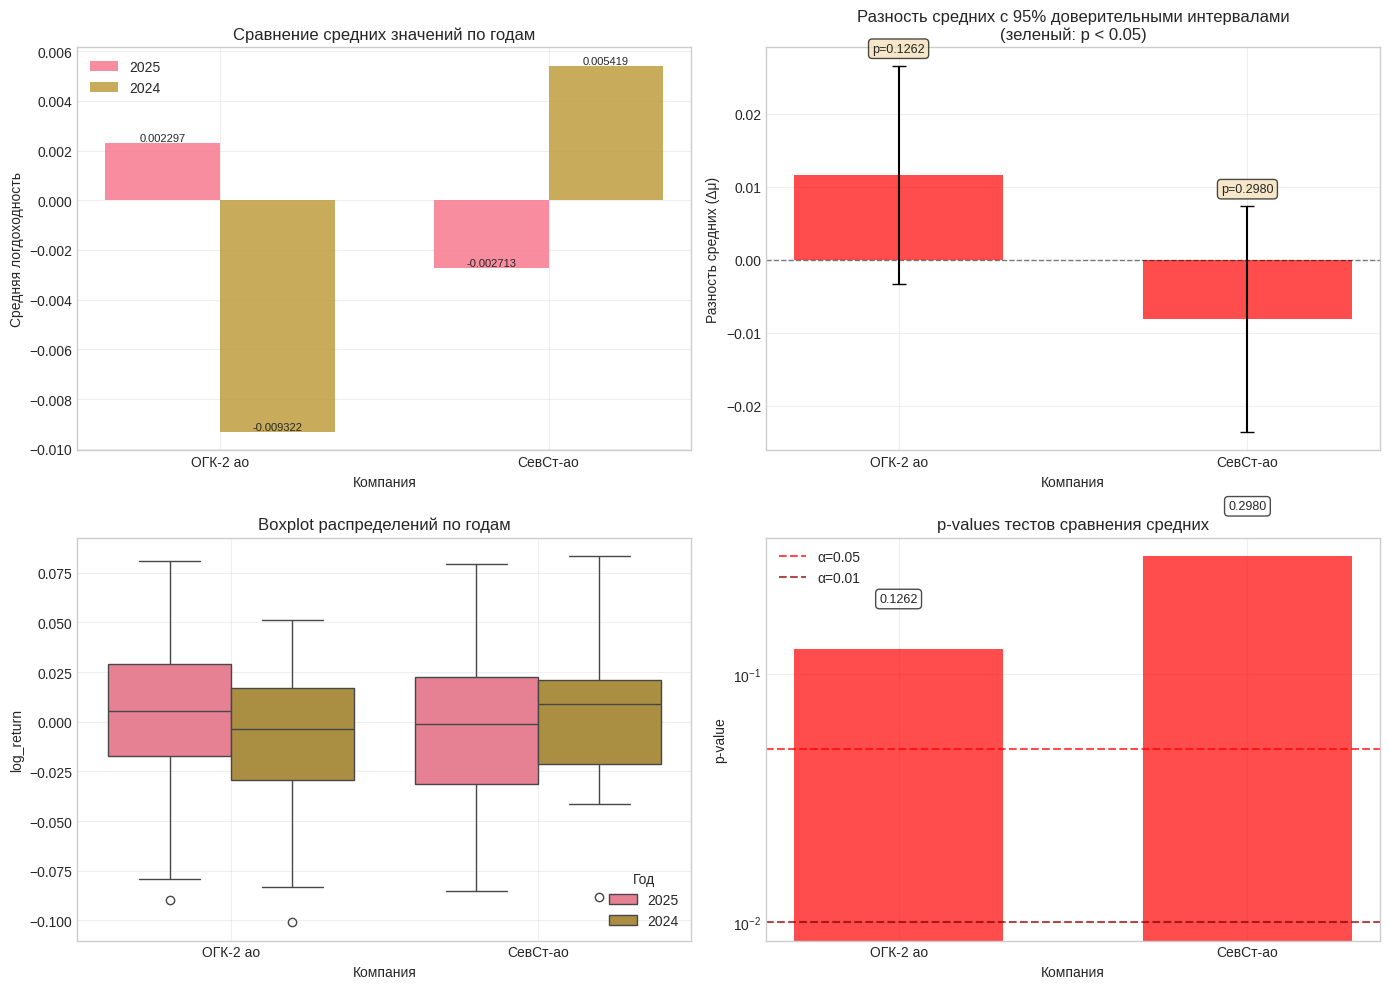



7. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: МОЩНОСТЬ ТЕСТА
----------------------------------------

Оценка мощности теста (при α=0.05):

ОГК-2 ао:
  Коэффициент Коэна d: 0.317 (маленький эффект)
  Размер эффекта: положительный
  Ориентировочная мощность теста: 33.8%
  Риск ошибки II рода (β): 66.2%

СевСт-ао:
  Коэффициент Коэна d: 0.211 (маленький эффект)
  Размер эффекта: отрицательный
  Ориентировочная мощность теста: 0.1%
  Риск ошибки II рода (β): 99.9%


8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
----------------------------------------
✓ Детальные результаты сохранены в 'year_comparison_detailed.csv'
✓ Сводные результаты сохранены в 'year_comparison_summary.csv'

ЗАДАНИЕ 9 ВЫПОЛНЕНО!
Выполнено:
1. Сравнение средних за 2025 и 2024 годы
2. Двусторонний t-тест Уэлча (без предположения об однородности дисперсий)
3. Вычислены t-статистики, p-values и доверительные интервалы
4. Проверены гипотезы на уровнях значимости 5% и 1%
5. Создана комплексная визуализация результатов
6. Проведен анализ мощности теста и размера

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("ЗАДАНИЕ 9: СРАВНЕНИЕ СРЕДНИХ ЗА ПОСЛЕДНИЕ ДВА ГОДА")
print("=" * 80)

# 1. Загружаем очищенные данные
print("\n1. ЗАГРУЗКА ДАННЫХ")
print("-" * 40)

df = pd.read_csv('data_cleaned_for_analysis.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

# Добавляем год
df['YEAR'] = df['DATE'].dt.year

companies = df['TICKER'].unique()
print(f"Компании: {companies}")
print(f"Все годы в данных: {sorted(df['YEAR'].unique())}")

# 2. Определяем последние два года
print("\n\n2. ОПРЕДЕЛЕНИЕ ПЕРИОДОВ ДЛЯ СРАВНЕНИЯ")
print("-" * 40)

last_year = df['YEAR'].max()
prev_year = last_year - 1

print(f"Последний год: {last_year}")
print(f"Предпоследний год: {prev_year}")
print(f"\nПроверяем наличие данных за оба года:")

for company in companies:
    data_last = df[(df['TICKER'] == company) & (df['YEAR'] == last_year)]
    data_prev = df[(df['TICKER'] == company) & (df['YEAR'] == prev_year)]

    print(f"\n{company}:")
    print(f"  {last_year}: {len(data_last)} недель (период: {data_last['DATE'].min().date() if len(data_last) > 0 else 'нет данных'} - {data_last['DATE'].max().date() if len(data_last) > 0 else 'нет данных'})")
    print(f"  {prev_year}: {len(data_prev)} недель (период: {data_prev['DATE'].min().date() if len(data_prev) > 0 else 'нет данных'} - {data_prev['DATE'].max().date() if len(data_prev) > 0 else 'нет данных'})")

# 3. ФОРМУЛИРОВКА ГИПОТЕЗ И МЕТОДИКА
print("\n\n3. ФОРМУЛИРОВКА ГИПОТЕЗ И МЕТОДИКА ТЕСТА")
print("-" * 40)
print("Нулевая гипотеза H₀: μ₁ = μ₂ (средние доходности за два года равны)")
print("Альтернативная гипотеза H₁: μ₁ ≠ μ₂ (средние доходности за два года не равны)")
print("Двусторонний t-тест (two-sided)")
print("Без предположений об однородности дисперсий (Welch's t-test)")
print("equal_var=False в scipy.stats.ttest_ind")

# 4. ПРОВЕДЕНИЕ T-ТЕСТА ДЛЯ КАЖДОЙ КОМПАНИИ
print("\n\n4. РЕЗУЛЬТАТЫ T-ТЕСТА (WELCH)")
print("-" * 40)

test_results = []

for company in companies:
    # Данные за последний год
    data_last = df[(df['TICKER'] == company) & (df['YEAR'] == last_year)]['log_return'].values
    # Данные за предпоследний год
    data_prev = df[(df['TICKER'] == company) & (df['YEAR'] == prev_year)]['log_return'].values

    # Проверяем, что есть данные за оба года
    if len(data_last) < 2 or len(data_prev) < 2:
        print(f"\n{company}: НЕДОСТАТОЧНО ДАННЫХ ДЛЯ ТЕСТА")
        print(f"  {last_year}: n={len(data_last)}")
        print(f"  {prev_year}: n={len(data_prev)}")
        continue

    # Основные статистики
    mean_last = np.mean(data_last)
    mean_prev = np.mean(data_prev)
    std_last = np.std(data_last, ddof=1)
    std_prev = np.std(data_prev, ddof=1)
    n_last = len(data_last)
    n_prev = len(data_prev)

    # Разница средних
    mean_diff = mean_last - mean_prev

    # Welch's t-test (без предположения об однородности дисперсий)
    t_stat, p_value = ttest_ind(data_last, data_prev, equal_var=False, alternative='two-sided')

    # Степени свободы для теста Уэлча
    se_last = std_last**2 / n_last
    se_prev = std_prev**2 / n_prev
    se_pooled = se_last + se_prev

    # Приближенные степени свободы (формула Уэлча-Саттертуэйта)
    df_welch = (se_pooled**2) / ((se_last**2)/(n_last-1) + (se_prev**2)/(n_prev-1))

    # Критические значения t-распределения
    t_critical_05 = stats.t.ppf(0.975, df_welch)  # для α=0.05 (двусторонний)
    t_critical_01 = stats.t.ppf(0.995, df_welch)  # для α=0.01 (двусторонний)

    # Стандартная ошибка разности средних
    se_diff = np.sqrt(se_pooled)

    # Доверительный интервал для разности средних (95%)
    ci_lower = mean_diff - t_critical_05 * se_diff
    ci_upper = mean_diff + t_critical_05 * se_diff

    test_results.append({
        'Компания': company,
        f'n({last_year})': n_last,
        f'n({prev_year})': n_prev,
        f'μ({last_year})': mean_last,
        f'μ({prev_year})': mean_prev,
        'Разность средних': mean_diff,
        f'σ({last_year})': std_last,
        f'σ({prev_year})': std_prev,
        't-статистика': t_stat,
        'Степени свободы (Welch)': df_welch,
        'p-value': p_value,
        'Станд. ошибка разности': se_diff,
        '95% ДИ разности': f"[{ci_lower:.6f}, {ci_upper:.6f}]",
        'Ширина ДИ': ci_upper - ci_lower,
        'Вывод α=0.05': 'H₀ отвергается' if p_value < 0.05 else 'H₀ не отвергается',
        'Вывод α=0.01': 'H₀ отвергается' if p_value < 0.01 else 'H₀ не отвергается'
    })

    print(f"\n{company}:")
    print(f"  {last_year}: n={n_last}, μ={mean_last:.6f}, σ={std_last:.6f}")
    print(f"  {prev_year}: n={n_prev}, μ={mean_prev:.6f}, σ={std_prev:.6f}")
    print(f"  Разность средних (Δμ): {mean_diff:.6f}")
    print(f"  t-статистика (Welch): {t_stat:.4f}")
    print(f"  Степени свободы (Welch): {df_welch:.1f}")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Стандартная ошибка разности: {se_diff:.6f}")
    print(f"  95% ДИ для разности: [{ci_lower:.6f}, {ci_upper:.6f}]")
    print(f"  Вывод (α=0.05): {'H₀ отвергается, средние РАЗЛИЧАЮТСЯ' if p_value < 0.05 else 'H₀ не отвергается, средние НЕ различаются'}")
    print(f"  Вывод (α=0.01): {'H₀ отвергается, средние РАЗЛИЧАЮТСЯ' if p_value < 0.01 else 'H₀ не отвергается, средние НЕ различаются'}")

# 5. СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
print("\n\n5. СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("-" * 40)

if test_results:
    results_df = pd.DataFrame(test_results)

    # Форматируем для красивого вывода
    display_cols = ['Компания', f'μ({last_year})', f'μ({prev_year})', 'Разность средних',
                   't-статистика', 'p-value', 'Вывод α=0.05']

    print(results_df[display_cols].to_string(index=False,
          float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))
else:
    print("Нет данных для проведения тестов")

# 6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
print("\n\n6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("-" * 40)

if test_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 6.1 График средних значений по годам
    means_last = [r[f'μ({last_year})'] for r in test_results]
    means_prev = [r[f'μ({prev_year})'] for r in test_results]
    companies_list = [r['Компания'] for r in test_results]

    x = np.arange(len(companies_list))
    width = 0.35

    bars1 = axes[0, 0].bar(x - width/2, means_last, width, label=str(last_year), alpha=0.8)
    bars2 = axes[0, 0].bar(x + width/2, means_prev, width, label=str(prev_year), alpha=0.8)

    axes[0, 0].set_xlabel('Компания')
    axes[0, 0].set_ylabel('Средняя логдоходность')
    axes[0, 0].set_title('Сравнение средних значений по годам')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(companies_list)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Добавляем значения на столбцы
    for bar, value in zip(bars1, means_last):
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{value:.6f}', ha='center', va='bottom', fontsize=8)

    for bar, value in zip(bars2, means_prev):
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{value:.6f}', ha='center', va='bottom', fontsize=8)

    # 6.2 График разностей средних с доверительными интервалами
    diffs = [r['Разность средних'] for r in test_results]
    ci_lowers = [float(r['95% ДИ разности'].split(',')[0].replace('[', '')) for r in test_results]
    ci_uppers = [float(r['95% ДИ разности'].split(',')[1].replace(']', '')) for r in test_results]
    p_values = [r['p-value'] for r in test_results]

    colors = ['green' if p < 0.05 else 'red' for p in p_values]

    axes[0, 1].bar(x, diffs, color=colors, alpha=0.7, width=0.6)
    axes[0, 1].errorbar(x, diffs, yerr=[np.array(diffs)-np.array(ci_lowers),
                                       np.array(ci_uppers)-np.array(diffs)],
                       fmt='none', color='black', capsize=5)
    axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

    axes[0, 1].set_xlabel('Компания')
    axes[0, 1].set_ylabel('Разность средних (Δμ)')
    axes[0, 1].set_title('Разность средних с 95% доверительными интервалами\n(зеленый: p < 0.05)')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(companies_list)
    axes[0, 1].grid(True, alpha=0.3)

    # Добавляем p-values
    for i, (diff, p_val) in enumerate(zip(diffs, p_values)):
        axes[0, 1].text(i, diff + (ci_uppers[i]-diff)*1.1, f'p={p_val:.4f}',
                       ha='center', va='bottom', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    # 6.3 Boxplot сравнения распределений
    all_data_last = []
    all_data_prev = []
    labels = []

    for r in test_results:
        company = r['Компания']
        data_last = df[(df['TICKER'] == company) & (df['YEAR'] == last_year)]['log_return'].values
        data_prev = df[(df['TICKER'] == company) & (df['YEAR'] == prev_year)]['log_return'].values

        all_data_last.extend(data_last)
        all_data_prev.extend(data_prev)
        labels.extend([f"{company}\n{last_year}"] * len(data_last))
        labels.extend([f"{company}\n{prev_year}"] * len(data_prev))

    # Создаем DataFrame для boxplot
    boxplot_data = []
    for r in test_results:
        company = r['Компания']
        data_last = df[(df['TICKER'] == company) & (df['YEAR'] == last_year)]['log_return'].values
        data_prev = df[(df['TICKER'] == company) & (df['YEAR'] == prev_year)]['log_return'].values

        for val in data_last:
            boxplot_data.append({'Компания': company, 'Год': str(last_year), 'log_return': val})
        for val in data_prev:
            boxplot_data.append({'Компания': company, 'Год': str(prev_year), 'log_return': val})

    boxplot_df = pd.DataFrame(boxplot_data)

    sns.boxplot(data=boxplot_df, x='Компания', y='log_return', hue='Год', ax=axes[1, 0])
    axes[1, 0].set_title('Boxplot распределений по годам')
    axes[1, 0].set_xlabel('Компания')
    axes[1, 0].set_ylabel('log_return')
    axes[1, 0].legend(title='Год')
    axes[1, 0].grid(True, alpha=0.3)

    # 6.4 График p-values
    axes[1, 1].bar(x, p_values, color=colors, alpha=0.7, width=0.6)
    axes[1, 1].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='α=0.05')
    axes[1, 1].axhline(y=0.01, color='darkred', linestyle='--', linewidth=1.5, alpha=0.7, label='α=0.01')

    axes[1, 1].set_xlabel('Компания')
    axes[1, 1].set_ylabel('p-value')
    axes[1, 1].set_title('p-values тестов сравнения средних')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(companies_list)
    axes[1, 1].set_yscale('log')  # логарифмическая шкала для лучшей визуализации
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # Добавляем значения p-values
    for i, p_val in enumerate(p_values):
        axes[1, 1].text(i, p_val * 1.5, f'{p_val:.4f}',
                       ha='center', va='bottom', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    plt.tight_layout()
    plt.savefig('year_comparison_results.png', dpi=150, bbox_inches='tight')
    plt.show()

# 7. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ВЛИЯНИЕ РАЗМЕРА ВЫБОРКИ
print("\n\n7. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: МОЩНОСТЬ ТЕСТА")
print("-" * 40)

if test_results:
    print("\nОценка мощности теста (при α=0.05):")

    for r in test_results:
        company = r['Компания']
        mean_diff = r['Разность средних']
        std_last = r[f'σ({last_year})']
        std_prev = r[f'σ({prev_year})']
        n_last = r[f'n({last_year})']
        n_prev = r[f'n({prev_year})']

        # Коэффициент Коэна d (стандартизованный размер эффекта)
        # Для неравных дисперсий используем объединенное стандартное отклонение
        pooled_std = np.sqrt(((n_last-1)*std_last**2 + (n_prev-1)*std_prev**2) / (n_last + n_prev - 2))
        cohen_d = mean_diff / pooled_std if pooled_std != 0 else 0

        # Эффективный размер выборки
        n_eff = (n_last * n_prev) / (n_last + n_prev)

        # Ориентировочная мощность (упрощенная формула)
        # Для двустороннего теста с α=0.05
        noncentrality = cohen_d * np.sqrt(n_eff)
        df_total = n_last + n_prev - 2
        t_critical = stats.t.ppf(0.975, df_total)  # критическое значение

        # Мощность как 1 - β
        # Используем нецентральное t-распределение
        power = 1 - stats.nct.cdf(t_critical, df_total, noncentrality)

        # Интерпретация размера эффекта
        if abs(cohen_d) < 0.2:
            effect_size = "очень маленький"
        elif abs(cohen_d) < 0.5:
            effect_size = "маленький"
        elif abs(cohen_d) < 0.8:
            effect_size = "средний"
        else:
            effect_size = "большой"

        print(f"\n{company}:")
        print(f"  Коэффициент Коэна d: {abs(cohen_d):.3f} ({effect_size} эффект)")
        print(f"  Размер эффекта: {'положительный' if cohen_d > 0 else 'отрицательный'}")
        print(f"  Ориентировочная мощность теста: {power:.1%}")
        print(f"  Риск ошибки II рода (β): {(1-power):.1%}")

# 8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n\n8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("-" * 40)

if test_results:
    # Детальные результаты
    detailed_df = pd.DataFrame(test_results)
    detailed_df.to_csv('year_comparison_detailed.csv', index=False, encoding='utf-8')
    print("✓ Детальные результаты сохранены в 'year_comparison_detailed.csv'")

    # Сводные результаты
    summary_cols = ['Компания', f'μ({last_year})', f'μ({prev_year})', 'Разность средних',
                   't-статистика', 'p-value', 'Вывод α=0.05']
    summary_df = detailed_df[summary_cols]
    summary_df.to_csv('year_comparison_summary.csv', index=False, encoding='utf-8')
    print("✓ Сводные результаты сохранены в 'year_comparison_summary.csv'")

    print("\n" + "=" * 80)
    print("ЗАДАНИЕ 9 ВЫПОЛНЕНО!")
    print("=" * 80)
    print("Выполнено:")
    print(f"1. Сравнение средних за {last_year} и {prev_year} годы")
    print("2. Двусторонний t-тест Уэлча (без предположения об однородности дисперсий)")
    print("3. Вычислены t-статистики, p-values и доверительные интервалы")
    print("4. Проверены гипотезы на уровнях значимости 5% и 1%")
    print("5. Создана комплексная визуализация результатов")
    print("6. Проведен анализ мощности теста и размера эффекта")
    print("7. Все результаты сохранены в CSV файлы")
    print("8. Создан график 'year_comparison_results.png'")
else:
    print("Нет данных для анализа. Проверьте наличие данных за оба года.")

10.

ЗАДАНИЕ 10: СРАВНЕНИЕ ДИСПЕРСИЙ ЗА ПОСЛЕДНИЕ ДВА ГОДА

1. ЗАГРУЗКА ДАННЫХ
----------------------------------------
Компании: ['МРСК ЦП' 'ОГК-2 ао' 'СевСт-ао']


2. ОПРЕДЕЛЕНИЕ ПЕРИОДОВ ДЛЯ СРАВНЕНИЯ
----------------------------------------
Последний год: 2025
Предпоследний год: 2024


3. ФОРМУЛИРОВКА ГИПОТЕЗ И МЕТОДИКА ТЕСТА
----------------------------------------
Нулевая гипотеза H₀: σ₁² = σ₂² (дисперсии доходностей за два года равны)
Альтернативная гипотеза H₁: σ₁² ≠ σ₂² (дисперсии доходностей за два года не равны)
Двусторонний F-тест
F = s₁² / s₂², где s₁² > s₂² (большая дисперсия / меньшая дисперсия)


4. РЕЗУЛЬТАТЫ F-ТЕСТА
----------------------------------------

МРСК ЦП: НЕДОСТАТОЧНО ДАННЫХ ДЛЯ ТЕСТА
  2025: n=0
  2024: n=0

ОГК-2 ао:
  2025: n=46, σ²=0.001610, σ=0.040122
  2024: n=51, σ²=0.001103, σ=0.033212
  Большая дисперсия: 2025 > 2024
  F-статистика: 1.4594 (df1=45, df2=50)
  p-value: 0.193700
  Критические значения (α=0.05): [0.559, 1.772]
  95% ДИ для отношения дисперс

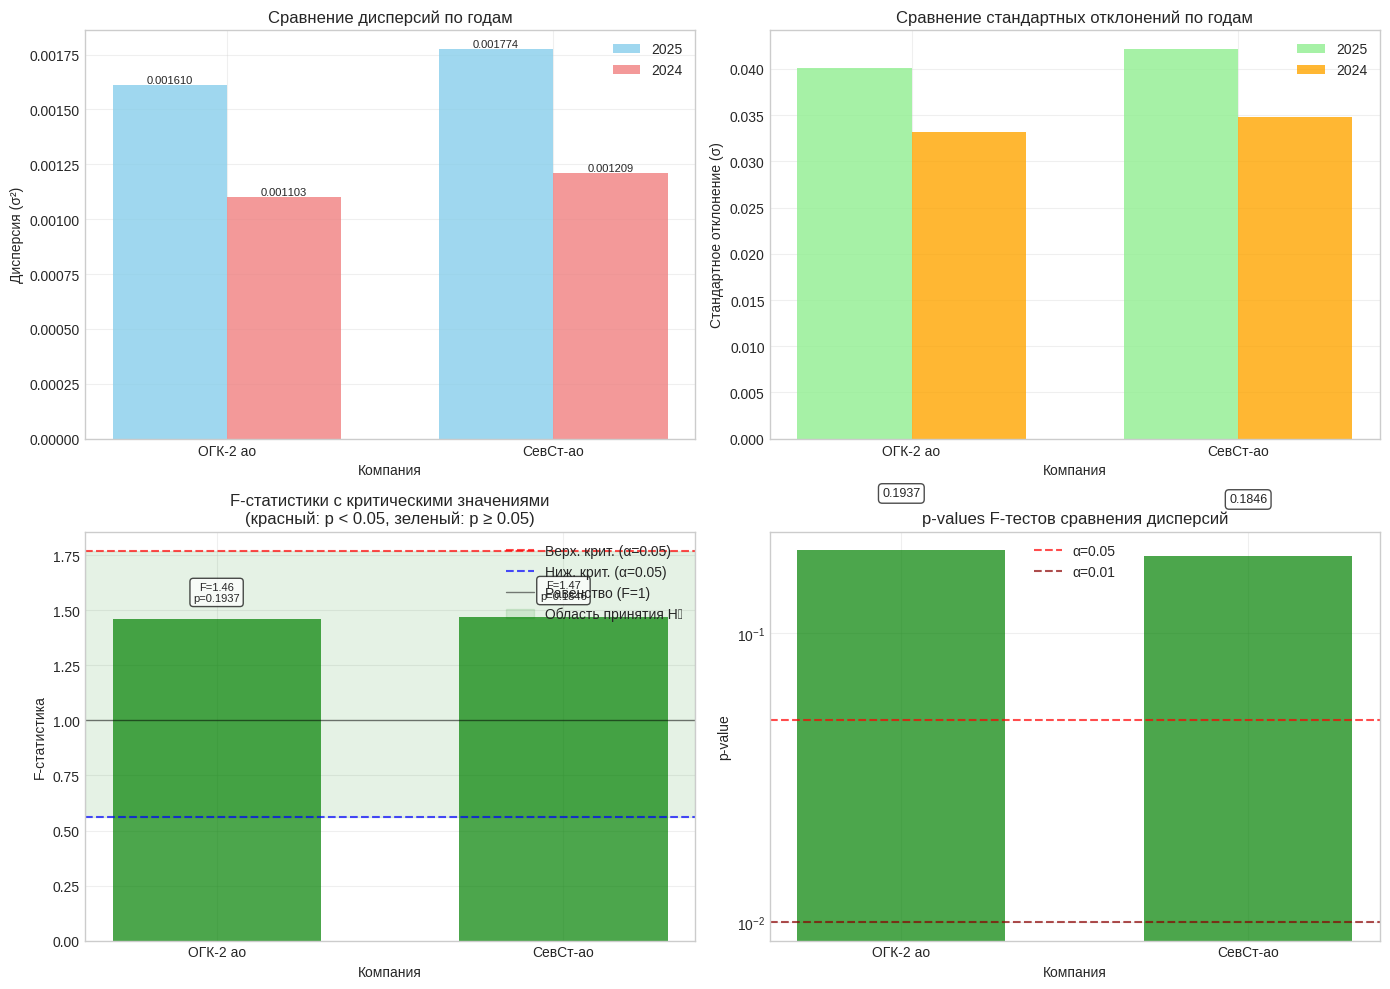



7. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: АЛЬТЕРНАТИВНЫЕ ТЕСТЫ
----------------------------------------

Сравнение с тестом Левена (более робастный к нарушениям нормальности):

ОГК-2 ао:
  F-тест: p=0.1937
  Тест Левена: W=0.5140, p=0.4752
  Тест Бартлетта: T=1.6760, p=0.1955
  Согласие тестов (α=0.05):
    F и Левен: ДА
    F и Бартлетт: ДА
    Левен и Бартлетт: ДА

СевСт-ао:
  F-тест: p=0.1846
  Тест Левена: W=1.3450, p=0.2490
  Тест Бартлетта: T=1.7575, p=0.1849
  Согласие тестов (α=0.05):
    F и Левен: ДА
    F и Бартлетт: ДА
    Левен и Бартлетт: ДА


8. ПРАКТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ
----------------------------------------

Изменение волатильности (риска) по годам:

ОГК-2 ао:
  СТАТИСТИЧЕСКИ НЕЗНАЧИМОЕ БЕЗ ИЗМЕНЕНИЙ волатильности
  Дисперсия: 0.001103 → 0.001610 (+45.9%)
  Ст. отклонение: 0.033212 → 0.040122 (+20.8%)
  Практический вывод: изменение риска на 20.8% незначимо

СевСт-ао:
  СТАТИСТИЧЕСКИ НЕЗНАЧИМОЕ БЕЗ ИЗМЕНЕНИЙ волатильности
  Дисперсия: 0.001209 → 0.001774 (+46.8%)
  Ст. отклонение

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("ЗАДАНИЕ 10: СРАВНЕНИЕ ДИСПЕРСИЙ ЗА ПОСЛЕДНИЕ ДВА ГОДА")
print("=" * 80)

# 1. Загружаем очищенные данные
print("\n1. ЗАГРУЗКА ДАННЫХ")
print("-" * 40)

df = pd.read_csv('data_cleaned_for_analysis.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

# Добавляем год
df['YEAR'] = df['DATE'].dt.year

companies = df['TICKER'].unique()
print(f"Компании: {companies}")

# 2. Определяем последние два года
print("\n\n2. ОПРЕДЕЛЕНИЕ ПЕРИОДОВ ДЛЯ СРАВНЕНИЯ")
print("-" * 40)

last_year = df['YEAR'].max()
prev_year = last_year - 1

print(f"Последний год: {last_year}")
print(f"Предпоследний год: {prev_year}")

# 3. ФОРМУЛИРОВКА ГИПОТЕЗ И МЕТОДИКА
print("\n\n3. ФОРМУЛИРОВКА ГИПОТЕЗ И МЕТОДИКА ТЕСТА")
print("-" * 40)
print("Нулевая гипотеза H₀: σ₁² = σ₂² (дисперсии доходностей за два года равны)")
print("Альтернативная гипотеза H₁: σ₁² ≠ σ₂² (дисперсии доходностей за два года не равны)")
print("Двусторонний F-тест")
print("F = s₁² / s₂², где s₁² > s₂² (большая дисперсия / меньшая дисперсия)")

# 4. ПРОВЕДЕНИЕ F-ТЕСТА ДЛЯ КАЖДОЙ КОМПАНИИ
print("\n\n4. РЕЗУЛЬТАТЫ F-ТЕСТА")
print("-" * 40)

test_results = []

for company in companies:
    # Данные за последний год
    data_last = df[(df['TICKER'] == company) & (df['YEAR'] == last_year)]['log_return'].values
    # Данные за предпоследний год
    data_prev = df[(df['TICKER'] == company) & (df['YEAR'] == prev_year)]['log_return'].values

    # Проверяем, что есть данные за оба года
    if len(data_last) < 2 or len(data_prev) < 2:
        print(f"\n{company}: НЕДОСТАТОЧНО ДАННЫХ ДЛЯ ТЕСТА")
        print(f"  {last_year}: n={len(data_last)}")
        print(f"  {prev_year}: n={len(data_prev)}")
        continue

    # Основные статистики
    var_last = np.var(data_last, ddof=1)  # несмещенная оценка дисперсии
    var_prev = np.var(data_prev, ddof=1)
    std_last = np.std(data_last, ddof=1)
    std_prev = np.std(data_prev, ddof=1)
    n_last = len(data_last)
    n_prev = len(data_prev)

    # Вычисляем F-статистику (большая дисперсия / меньшая дисперсия)
    if var_last >= var_prev:
        F_stat = var_last / var_prev
        df1 = n_last - 1  # степени свободы числителя
        df2 = n_prev - 1  # степени свободы знаменателя
        which_larger = f"{last_year} > {prev_year}"
    else:
        F_stat = var_prev / var_last
        df1 = n_prev - 1
        df2 = n_last - 1
        which_larger = f"{prev_year} > {last_year}"

    # p-value для двустороннего теста
    # Умножаем на 2, так как тест двусторонний
    p_value_one_sided = 1 - stats.f.cdf(F_stat, df1, df2)
    p_value = 2 * min(p_value_one_sided, 1 - p_value_one_sided)

    # Критические значения F-распределения
    F_critical_05_upper = stats.f.ppf(0.975, df1, df2)  # верхнее критическое значение (α=0.05)
    F_critical_05_lower = stats.f.ppf(0.025, df1, df2)  # нижнее критическое значение (α=0.05)
    F_critical_01_upper = stats.f.ppf(0.995, df1, df2)  # верхнее критическое значение (α=0.01)
    F_critical_01_lower = stats.f.ppf(0.005, df1, df2)  # нижнее критическое значение (α=0.01)

    # Доверительный интервал для отношения дисперсий
    ci_lower = F_stat / F_critical_05_upper
    ci_upper = F_stat * F_critical_05_upper

    test_results.append({
        'Компания': company,
        f'n({last_year})': n_last,
        f'n({prev_year})': n_prev,
        f'σ²({last_year})': var_last,
        f'σ²({prev_year})': var_prev,
        f'σ({last_year})': std_last,
        f'σ({prev_year})': std_prev,
        'Отношение σ²': f"{max(var_last, var_prev)/min(var_last, var_prev):.4f}:1",
        'F-статистика': F_stat,
        'df1 (числитель)': df1,
        'df2 (знаменатель)': df2,
        'p-value': p_value,
        'Крит. F (α=0.05)': f"[{F_critical_05_lower:.3f}, {F_critical_05_upper:.3f}]",
        'Крит. F (α=0.01)': f"[{F_critical_01_lower:.3f}, {F_critical_01_upper:.3f}]",
        '95% ДИ отношения': f"[{ci_lower:.3f}, {ci_upper:.3f}]",
        'Вывод α=0.05': 'H₀ отвергается' if p_value < 0.05 else 'H₀ не отвергается',
        'Вывод α=0.01': 'H₀ отвергается' if p_value < 0.01 else 'H₀ не отвергается'
    })

    print(f"\n{company}:")
    print(f"  {last_year}: n={n_last}, σ²={var_last:.6f}, σ={std_last:.6f}")
    print(f"  {prev_year}: n={n_prev}, σ²={var_prev:.6f}, σ={std_prev:.6f}")
    print(f"  Большая дисперсия: {which_larger}")
    print(f"  F-статистика: {F_stat:.4f} (df1={df1}, df2={df2})")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Критические значения (α=0.05): [{F_critical_05_lower:.3f}, {F_critical_05_upper:.3f}]")
    print(f"  95% ДИ для отношения дисперсий: [{ci_lower:.3f}:1, {ci_upper:.3f}:1]")
    print(f"  Вывод (α=0.05): {'H₀ отвергается, дисперсии РАЗЛИЧАЮТСЯ' if p_value < 0.05 else 'H₀ не отвергается, дисперсии НЕ различаются'}")
    print(f"  Вывод (α=0.01): {'H₀ отвергается, дисперсии РАЗЛИЧАЮТСЯ' if p_value < 0.01 else 'H₀ не отвергается, дисперсии НЕ различаются'}")

# 5. СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
print("\n\n5. СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("-" * 40)

if test_results:
    results_df = pd.DataFrame(test_results)

    # Форматируем для красивого вывода
    display_cols = ['Компания', f'σ²({last_year})', f'σ²({prev_year})',
                   'F-статистика', 'p-value', 'Вывод α=0.05']

    print(results_df[display_cols].to_string(index=False,
          float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))
else:
    print("Нет данных для проведения тестов")

# 6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
print("\n\n6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("-" * 40)

if test_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 6.1 График дисперсий по годам
    vars_last = [r[f'σ²({last_year})'] for r in test_results]
    vars_prev = [r[f'σ²({prev_year})'] for r in test_results]
    companies_list = [r['Компания'] for r in test_results]

    x = np.arange(len(companies_list))
    width = 0.35

    bars1 = axes[0, 0].bar(x - width/2, vars_last, width, label=str(last_year), alpha=0.8, color='skyblue')
    bars2 = axes[0, 0].bar(x + width/2, vars_prev, width, label=str(prev_year), alpha=0.8, color='lightcoral')

    axes[0, 0].set_xlabel('Компания')
    axes[0, 0].set_ylabel('Дисперсия (σ²)')
    axes[0, 0].set_title('Сравнение дисперсий по годам')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(companies_list)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Добавляем значения на столбцы
    for bar, value in zip(bars1, vars_last):
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{value:.6f}', ha='center', va='bottom', fontsize=8)

    for bar, value in zip(bars2, vars_prev):
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{value:.6f}', ha='center', va='bottom', fontsize=8)

    # 6.2 График стандартных отклонений
    stds_last = [r[f'σ({last_year})'] for r in test_results]
    stds_prev = [r[f'σ({prev_year})'] for r in test_results]

    axes[0, 1].bar(x - width/2, stds_last, width, label=str(last_year), alpha=0.8, color='lightgreen')
    axes[0, 1].bar(x + width/2, stds_prev, width, label=str(prev_year), alpha=0.8, color='orange')

    axes[0, 1].set_xlabel('Компания')
    axes[0, 1].set_ylabel('Стандартное отклонение (σ)')
    axes[0, 1].set_title('Сравнение стандартных отклонений по годам')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(companies_list)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 6.3 График F-статистик с критическими зонами
    F_stats = [r['F-статистика'] for r in test_results]
    p_values = [r['p-value'] for r in test_results]

    # Критические зоны
    colors = ['red' if p < 0.05 else 'green' for p in p_values]

    bars = axes[1, 0].bar(x, F_stats, color=colors, alpha=0.7, width=0.6)

    # Критические линии
    # Берем средние степени свободы для отрисовки
    avg_df1 = np.mean([r['df1 (числитель)'] for r in test_results])
    avg_df2 = np.mean([r['df2 (знаменатель)'] for r in test_results])

    F_crit_05_upper = stats.f.ppf(0.975, avg_df1, avg_df2)
    F_crit_05_lower = stats.f.ppf(0.025, avg_df1, avg_df2)

    axes[1, 0].axhline(y=F_crit_05_upper, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Верх. крит. (α=0.05)')
    axes[1, 0].axhline(y=F_crit_05_lower, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label='Ниж. крит. (α=0.05)')
    axes[1, 0].axhline(y=1.0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Равенство (F=1)')

    # Закрашиваем область принятия H₀
    axes[1, 0].axhspan(F_crit_05_lower, F_crit_05_upper, alpha=0.1, color='green', label='Область принятия H₀')

    axes[1, 0].set_xlabel('Компания')
    axes[1, 0].set_ylabel('F-статистика')
    axes[1, 0].set_title('F-статистики с критическими значениями\n(красный: p < 0.05, зеленый: p ≥ 0.05)')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(companies_list)
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].grid(True, alpha=0.3)

    # Добавляем значения F и p
    for i, (F_val, p_val) in enumerate(zip(F_stats, p_values)):
        axes[1, 0].text(i, F_val * 1.05, f'F={F_val:.2f}\np={p_val:.4f}',
                       ha='center', va='bottom', fontsize=8,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # 6.4 График p-values
    axes[1, 1].bar(x, p_values, color=colors, alpha=0.7, width=0.6)
    axes[1, 1].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='α=0.05')
    axes[1, 1].axhline(y=0.01, color='darkred', linestyle='--', linewidth=1.5, alpha=0.7, label='α=0.01')

    axes[1, 1].set_xlabel('Компания')
    axes[1, 1].set_ylabel('p-value')
    axes[1, 1].set_title('p-values F-тестов сравнения дисперсий')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(companies_list)
    axes[1, 1].set_yscale('log')  # логарифмическая шкала для лучшей визуализации
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # Добавляем значения p-values
    for i, p_val in enumerate(p_values):
        axes[1, 1].text(i, p_val * 1.5, f'{p_val:.4f}',
                       ha='center', va='bottom', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    plt.tight_layout()
    plt.savefig('variance_comparison_results.png', dpi=150, bbox_inches='tight')
    plt.show()

# 7. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: АЛЬТЕРНАТИВНЫЕ ТЕСТЫ НА РАВЕНСТВО ДИСПЕРСИЙ
print("\n\n7. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: АЛЬТЕРНАТИВНЫЕ ТЕСТЫ")
print("-" * 40)

if test_results:
    print("\nСравнение с тестом Левена (более робастный к нарушениям нормальности):")

    for r in test_results:
        company = r['Компания']

        data_last = df[(df['TICKER'] == company) & (df['YEAR'] == last_year)]['log_return'].values
        data_prev = df[(df['TICKER'] == company) & (df['YEAR'] == prev_year)]['log_return'].values

        # Тест Левена
        levene_stat, levene_p = stats.levene(data_last, data_prev, center='mean')

        # Тест Бартлетта (чувствителен к нарушениям нормальности)
        bartlett_stat, bartlett_p = stats.bartlett(data_last, data_prev)

        print(f"\n{company}:")
        print(f"  F-тест: p={r['p-value']:.4f}")
        print(f"  Тест Левена: W={levene_stat:.4f}, p={levene_p:.4f}")
        print(f"  Тест Бартлетта: T={bartlett_stat:.4f}, p={bartlett_p:.4f}")

        # Сравнение выводов
        f_test_reject = r['p-value'] < 0.05
        levene_reject = levene_p < 0.05
        bartlett_reject = bartlett_p < 0.05

        print(f"  Согласие тестов (α=0.05):")
        print(f"    F и Левен: {'ДА' if f_test_reject == levene_reject else 'НЕТ'}")
        print(f"    F и Бартлетт: {'ДА' if f_test_reject == bartlett_reject else 'НЕТ'}")
        print(f"    Левен и Бартлетт: {'ДА' if levene_reject == bartlett_reject else 'НЕТ'}")

# 8. ПРАКТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
print("\n\n8. ПРАКТИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ")
print("-" * 40)

if test_results:
    print("\nИзменение волатильности (риска) по годам:")

    for r in test_results:
        company = r['Компания']
        var_last = r[f'σ²({last_year})']
        var_prev = r[f'σ²({prev_year})']
        std_last = r[f'σ({last_year})']
        std_prev = r[f'σ({prev_year})']
        p_value = r['p-value']

        # Относительное изменение волатильности
        var_change_pct = ((var_last / var_prev) - 1) * 100
        std_change_pct = ((std_last / std_prev) - 1) * 100

        # Интерпретация
        if p_value < 0.05:
            significance = "СТАТИСТИЧЕСКИ ЗНАЧИМОЕ"
            if var_last > var_prev:
                direction = "УВЕЛИЧЕНИЕ"
                risk_change = f"риск ВЫРОС на {abs(std_change_pct):.1f}%"
            else:
                direction = "УМЕНЬШЕНИЕ"
                risk_change = f"риск СНИЗИЛСЯ на {abs(std_change_pct):.1f}%"
        else:
            significance = "СТАТИСТИЧЕСКИ НЕЗНАЧИМОЕ"
            direction = "БЕЗ ИЗМЕНЕНИЙ"
            risk_change = f"изменение риска на {std_change_pct:.1f}% незначимо"

        print(f"\n{company}:")
        print(f"  {significance} {direction} волатильности")
        print(f"  Дисперсия: {var_prev:.6f} → {var_last:.6f} ({var_change_pct:+.1f}%)")
        print(f"  Ст. отклонение: {std_prev:.6f} → {std_last:.6f} ({std_change_pct:+.1f}%)")
        print(f"  Практический вывод: {risk_change}")

# 9. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n\n9. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("-" * 40)

if test_results:
    # Детальные результаты
    detailed_df = pd.DataFrame(test_results)
    detailed_df.to_csv('variance_comparison_detailed.csv', index=False, encoding='utf-8')
    print("✓ Детальные результаты сохранены в 'variance_comparison_detailed.csv'")

    # Сводные результаты
    summary_cols = ['Компания', f'σ²({last_year})', f'σ²({prev_year})',
                   'F-статистика', 'p-value', 'Вывод α=0.05']
    summary_df = detailed_df[summary_cols]
    summary_df.to_csv('variance_comparison_summary.csv', index=False, encoding='utf-8')
    print("✓ Сводные результаты сохранены в 'variance_comparison_summary.csv'")

    print("\n" + "=" * 80)
    print("ЗАДАНИЕ 10 ВЫПОЛНЕНО!")
    print("=" * 80)
    print("Выполнено:")
    print(f"1. Сравнение дисперсий за {last_year} и {prev_year} годы")
    print("2. Двусторонний F-тест на равенство дисперсий")
    print("3. Вычислены F-статистики, p-values и доверительные интервалы")
    print("4. Проверены гипотезы на уровнях значимости 5% и 1%")
    print("5. Сравнение с альтернативными тестами (Левена, Бартлетта)")
    print("6. Практическая интерпретация изменений волатильности")
    print("7. Создана комплексная визуализация результатов")
    print("8. Все результаты сохранены в CSV файлы")
    print("9. Создан график 'variance_comparison_results.png'")
else:
    print("Нет данных для анализа. Проверьте наличие данных за оба года.")

11.

ЗАДАНИЕ 11: СРАВНИТЕЛЬНЫЙ АНАЛИЗ ЛОГОДОХОДНОСТЕЙ КОМПАНИЙ

1. ЗАГРУЗКА ДАННЫХ
----------------------------------------
Компании для анализа (3 шт.): ['МРСК ЦП' 'ОГК-2 ао' 'СевСт-ао']
Период данных: 2015-01-12 - 2025-12-15
Всего наблюдений: 1401


2. ВРЕМЕННЫЕ РЯДЫ ЛОГОДОХОДНОСТЕЙ
----------------------------------------


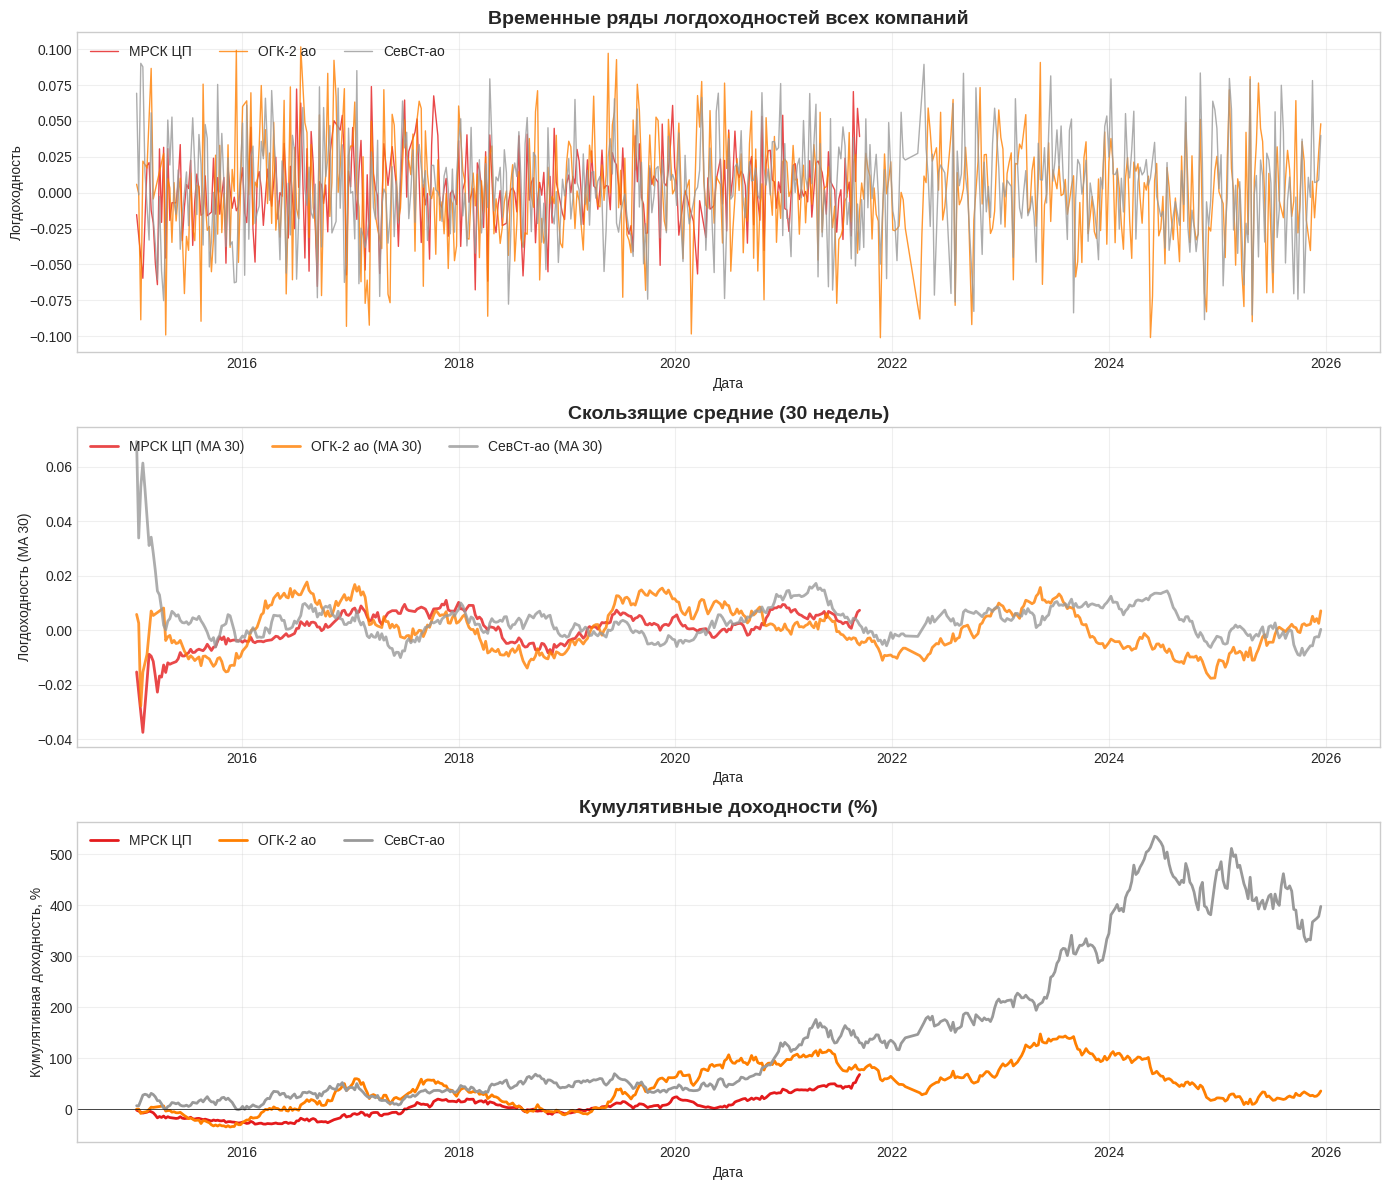



3. МАТРИЦА КОРРЕЛЯЦИЙ ЛОГОДОХОДНОСТЕЙ
----------------------------------------

Матрица корреляций:
TICKER    МРСК ЦП  ОГК-2 ао  СевСт-ао
TICKER                               
МРСК ЦП    1.0000    0.2909    0.1732
ОГК-2 ао   0.2909    1.0000    0.2603
СевСт-ао   0.1732    0.2603    1.0000


Проверка значимости корреляций (t-тест):
H₀: ρ = 0 (корреляция отсутствует)
H₁: ρ ≠ 0 (корреляция существует)

Матрица корреляций со звездочками значимости:
*** p < 0.01, ** p < 0.05, * p < 0.1, нс - не значимо
           МРСК ЦП  ОГК-2 ао  СевСт-ао
МРСК ЦП          -  0.291***  0.173***
ОГК-2 ао  0.291***         -  0.260***
СевСт-ао  0.173***  0.260***         -


4. УСЛОВНОЕ ФОРМАТИРОВАНИЕ МАТРИЦЫ КОРРЕЛЯЦИЙ
----------------------------------------


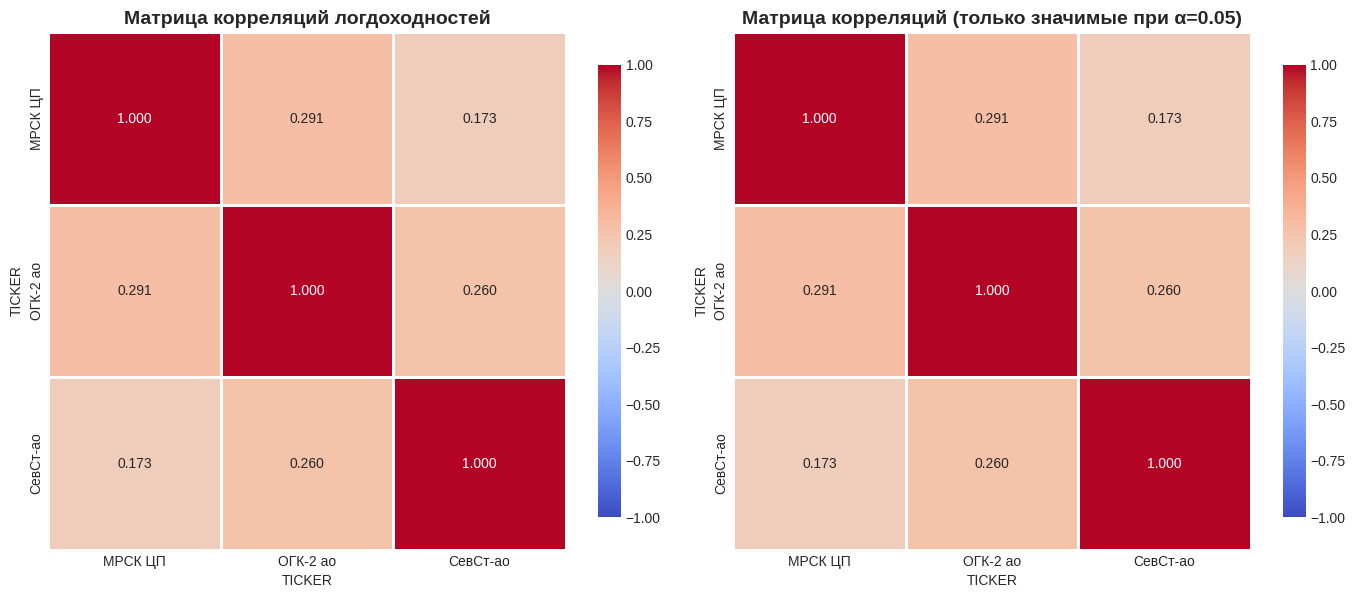



5. КЛАСТЕРНЫЙ АНАЛИЗ И ДЕНДРОГРАММА
----------------------------------------


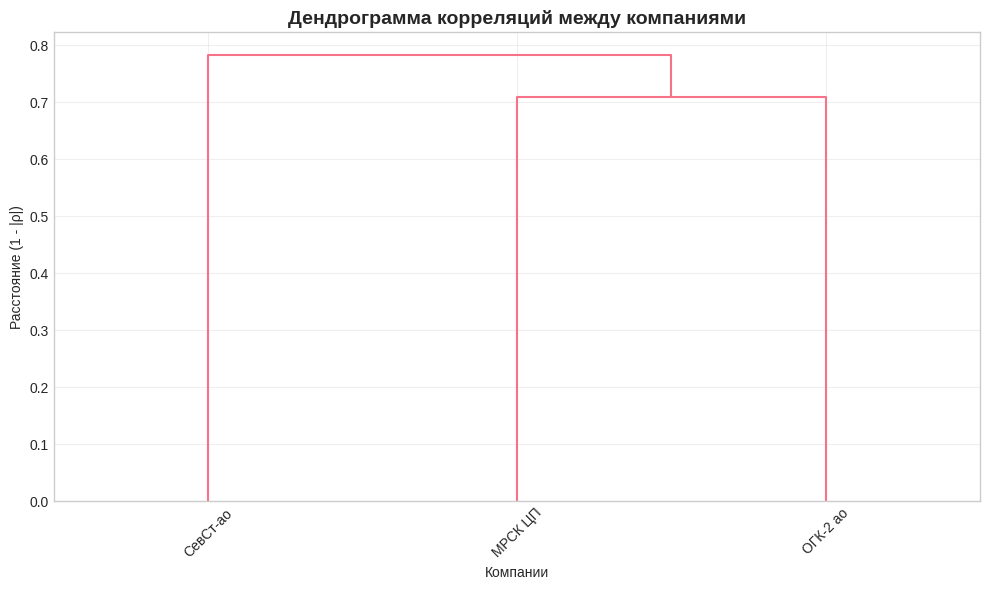


Интерпретация кластеров:
Более близкие компании имеют более высокие абсолютные корреляции


6. СРАВНИТЕЛЬНАЯ СТАТИСТИКА КОМПАНИЙ
----------------------------------------

Сравнительная таблица статистик:
Компания  Наблюдений  Среднее  Ст. отклонение  Коэфф. вариации  Асимметрия   Эксцесс       Мин     Макс  Медиана        Q1       Q3      IQR
 МРСК ЦП         319 0.001633        0.026562        16.265352   -0.027452  0.241046 -0.067741 0.073914 0.002486 -0.014229 0.017325 0.031554
ОГК-2 ао         536 0.000574        0.037596        65.447959   -0.091739  0.151762 -0.101077 0.101569 0.001203 -0.024404 0.023997 0.048401
СевСт-ао         546 0.002940        0.035199        11.970852   -0.003421 -0.126190 -0.088499 0.090109 0.003244 -0.020413 0.023633 0.044046


Рейтинг компаний:

По средней доходности (от высокой к низкой):
1. СевСт-ао: 0.002940
2. МРСК ЦП: 0.001633
3. ОГК-2 ао: 0.000574

По риску (от низкого к высокому):
1. МРСК ЦП: 0.026562
2. СевСт-ао: 0.035199
3. ОГК-2 ао: 0.037596


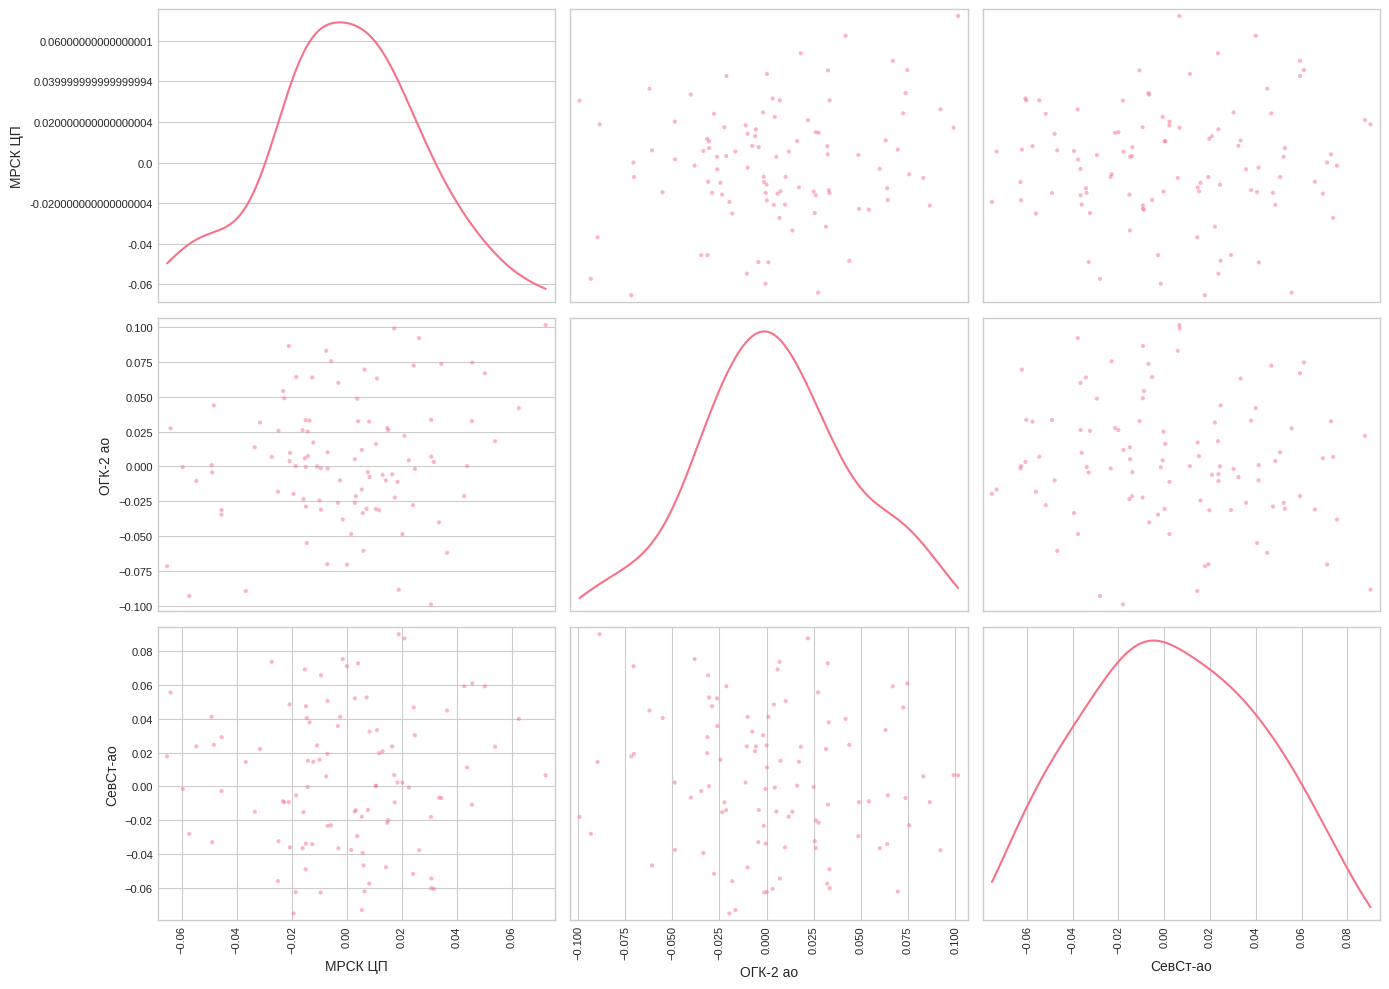



8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
----------------------------------------
✓ Матрица корреляций сохранена в 'correlation_matrix.csv'
✓ Матрица значимостей корреляций сохранена в 'correlation_significance.csv'
✓ Сравнительная статистика сохранена в 'comparative_statistics.csv'
✓ Сводные данные по компаниям сохранены в 'companies_summary.csv'

ЗАДАНИЕ 11 ВЫПОЛНЕНО!
Созданы файлы:
✓ time_series_comparison.png - временные ряды доходностей
✓ correlation_matrix_visual.png - визуализация корреляций
✓ correlation_dendrogram.png - дендрограмма корреляций
✓ distribution_comparison.png - сравнение распределений
✓ correlation_matrix.csv - матрица корреляций
✓ correlation_significance.csv - значимости корреляций
✓ comparative_statistics.csv - сравнительная статистика
✓ companies_summary.csv - сводные данные по компаниям


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройки
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 80)
print("ЗАДАНИЕ 11: СРАВНИТЕЛЬНЫЙ АНАЛИЗ ЛОГОДОХОДНОСТЕЙ КОМПАНИЙ")
print("=" * 80)

# 1. Загружаем очищенные данные
print("\n1. ЗАГРУЗКА ДАННЫХ")
print("-" * 40)

df = pd.read_csv('data_cleaned_for_analysis.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

companies = df['TICKER'].unique()
print(f"Компании для анализа ({len(companies)} шт.): {companies}")
print(f"Период данных: {df['DATE'].min().date()} - {df['DATE'].max().date()}")
print(f"Всего наблюдений: {len(df)}")

# 2. ВРЕМЕННЫЕ РЯДЫ ЛОГОДОХОДНОСТЕЙ
print("\n\n2. ВРЕМЕННЫЕ РЯДЫ ЛОГОДОХОДНОСТЕЙ")
print("-" * 40)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 2.1 Общий график всех компаний
colors = plt.cm.Set1(np.linspace(0, 1, len(companies)))

for idx, company in enumerate(companies):
    company_data = df[df['TICKER'] == company]
    axes[0].plot(company_data['DATE'], company_data['log_return'],
                label=company, color=colors[idx], linewidth=1, alpha=0.8)

axes[0].set_title('Временные ряды логдоходностей всех компаний', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Логдоходность')
axes[0].legend(loc='upper left', ncol=len(companies))
axes[0].grid(True, alpha=0.3)

# Добавляем скользящие средние (30 недель)
for idx, company in enumerate(companies):
    company_data = df[df['TICKER'] == company].copy()
    company_data = company_data.sort_values('DATE')
    company_data['MA_30'] = company_data['log_return'].rolling(window=30, min_periods=1).mean()

    axes[1].plot(company_data['DATE'], company_data['MA_30'],
                label=f'{company} (MA 30)', color=colors[idx], linewidth=2, alpha=0.8)

axes[1].set_title('Скользящие средние (30 недель)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Логдоходность (MA 30)')
axes[1].legend(loc='upper left', ncol=len(companies))
axes[1].grid(True, alpha=0.3)

# Кумулятивные доходности
for idx, company in enumerate(companies):
    company_data = df[df['TICKER'] == company].copy()
    company_data = company_data.sort_values('DATE')
    company_data['Cumulative_Return'] = np.exp(company_data['log_return'].cumsum()) - 1

    axes[2].plot(company_data['DATE'], company_data['Cumulative_Return'] * 100,
                label=company, color=colors[idx], linewidth=2)

axes[2].set_title('Кумулятивные доходности (%)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Дата')
axes[2].set_ylabel('Кумулятивная доходность, %')
axes[2].legend(loc='upper left', ncol=len(companies))
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('time_series_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. МАТРИЦА КОРРЕЛЯЦИЙ
print("\n\n3. МАТРИЦА КОРРЕЛЯЦИЙ ЛОГОДОХОДНОСТЕЙ")
print("-" * 40)

# Создаем сводную таблицу для корреляций
pivot_table = df.pivot_table(index='DATE', columns='TICKER', values='log_return')
corr_matrix = pivot_table.corr()

print("\nМатрица корреляций:")
print(corr_matrix.round(4))

# Проверяем значимость корреляций
print("\n\nПроверка значимости корреляций (t-тест):")
print("H₀: ρ = 0 (корреляция отсутствует)")
print("H₁: ρ ≠ 0 (корреляция существует)")

n = len(pivot_table)  # количество наблюдений
significance_matrix = pd.DataFrame(index=companies, columns=companies, dtype=str)

for i, comp1 in enumerate(companies):
    for j, comp2 in enumerate(companies):
        if i == j:
            significance_matrix.loc[comp1, comp2] = '-'
        else:
            r = corr_matrix.loc[comp1, comp2]
            # t-статистика для проверки значимости корреляции
            t_stat = r * np.sqrt((n - 2) / (1 - r**2))
            # p-value (двусторонний тест)
            p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n-2))

            if p_value < 0.01:
                significance = '***'
            elif p_value < 0.05:
                significance = '**'
            elif p_value < 0.1:
                significance = '*'
            else:
                significance = 'нс'

            significance_matrix.loc[comp1, comp2] = f"{r:.3f}{significance}"

print("\nМатрица корреляций со звездочками значимости:")
print("*** p < 0.01, ** p < 0.05, * p < 0.1, нс - не значимо")
print(significance_matrix.to_string())

# 4. УСЛОВНОЕ ФОРМАТИРОВАНИЕ МАТРИЦЫ КОРРЕЛЯЦИЙ
print("\n\n4. УСЛОВНОЕ ФОРМАТИРОВАНИЕ МАТРИЦЫ КОРРЕЛЯЦИЙ")
print("-" * 40)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 4.1 Тепловая карта корреляций
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=axes[0], fmt='.3f', vmin=-1, vmax=1)
axes[0].set_title('Матрица корреляций логдоходностей', fontsize=14, fontweight='bold')

# 4.2 Тепловая карта со значимостью
# Создаем маску для незначимых корреляций
mask = np.zeros_like(corr_matrix, dtype=bool)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        if i != j:
            r = corr_matrix.iloc[i, j]
            t_stat = r * np.sqrt((n - 2) / (1 - r**2))
            p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n-2))
            if p_value >= 0.05:  # не значимые при α=0.05
                mask[i, j] = True

# Рисуем тепловую карту с маской
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=axes[1], fmt='.3f', vmin=-1, vmax=1, mask=mask)
axes[1].set_title('Матрица корреляций (только значимые при α=0.05)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_matrix_visual.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. КЛАСТЕРНЫЙ АНАЛИЗ КОРРЕЛЯЦИЙ
print("\n\n5. КЛАСТЕРНЫЙ АНАЛИЗ И ДЕНДРОГРАММА")
print("-" * 40)

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Преобразуем матрицу корреляций в матрицу расстояний
# Расстояние = 1 - |корреляция| (чтобы сильные корреляции были ближе)
distance_matrix = 1 - np.abs(corr_matrix.values)

# Кластеризация
linkage_matrix = linkage(squareform(distance_matrix), method='average')

fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(linkage_matrix, labels=companies, ax=ax,
           leaf_rotation=45, leaf_font_size=10)
ax.set_title('Дендрограмма корреляций между компаниями', fontsize=14, fontweight='bold')
ax.set_xlabel('Компании')
ax.set_ylabel('Расстояние (1 - |ρ|)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nИнтерпретация кластеров:")
print("Более близкие компании имеют более высокие абсолютные корреляции")

# 6. СРАВНИТЕЛЬНАЯ СТАТИСТИКА
print("\n\n6. СРАВНИТЕЛЬНАЯ СТАТИСТИКА КОМПАНИЙ")
print("-" * 40)

comparison_stats = []

for company in companies:
    company_data = df[df['TICKER'] == company]['log_return']

    stats_dict = {
        'Компания': company,
        'Наблюдений': len(company_data),
        'Среднее': company_data.mean(),
        'Ст. отклонение': company_data.std(),
        'Коэфф. вариации': abs(company_data.std() / company_data.mean()) if company_data.mean() != 0 else np.inf,
        'Асимметрия': company_data.skew(),
        'Эксцесс': company_data.kurtosis(),
        'Мин': company_data.min(),
        'Макс': company_data.max(),
        'Медиана': company_data.median(),
        'Q1': company_data.quantile(0.25),
        'Q3': company_data.quantile(0.75),
        'IQR': company_data.quantile(0.75) - company_data.quantile(0.25)
    }
    comparison_stats.append(stats_dict)

comparison_df = pd.DataFrame(comparison_stats)

print("\nСравнительная таблица статистик:")
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))

# Рейтинг компаний по различным метрикам
print("\n\nРейтинг компаний:")

# По средней доходности
sorted_by_return = comparison_df.sort_values('Среднее', ascending=False)
print("\nПо средней доходности (от высокой к низкой):")
for i, (_, row) in enumerate(sorted_by_return.iterrows(), 1):
    print(f"{i}. {row['Компания']}: {row['Среднее']:.6f}")

# По риску (стандартному отклонению)
sorted_by_risk = comparison_df.sort_values('Ст. отклонение', ascending=True)
print("\nПо риску (от низкого к высокому):")
for i, (_, row) in enumerate(sorted_by_risk.iterrows(), 1):
    print(f"{i}. {row['Компания']}: {row['Ст. отклонение']:.6f}")

# По отношению доходность/риск
comparison_df['Доходность/Риск'] = comparison_df['Среднее'] / comparison_df['Ст. отклонение']
sorted_by_ratio = comparison_df.sort_values('Доходность/Риск', ascending=False)
print("\nПо отношению доходность/риск (от высокого к низкому):")
for i, (_, row) in enumerate(sorted_by_ratio.iterrows(), 1):
    print(f"{i}. {row['Компания']}: {row['Доходность/Риск']:.4f}")

# 7. ГРАФИКИ СРАВНЕНИЯ РАСПРЕДЕЛЕНИЙ
print("\n\n7. ГРАФИЧЕСКОЕ СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 7.1 Совмещенные гистограммы
for company in companies:
    company_data = df[df['TICKER'] == company]['log_return']
    axes[0, 0].hist(company_data, bins=30, alpha=0.5, density=True, label=company)

axes[0, 0].set_title('Совмещенные гистограммы распределений', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Логдоходность')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 7.2 Ящики с усами
data_for_boxplot = [df[df['TICKER'] == company]['log_return'].values for company in companies]
axes[0, 1].boxplot(data_for_boxplot, labels=companies)
axes[0, 1].set_title('Ящики с усами логдоходностей', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Компания')
axes[0, 1].set_ylabel('Логдоходность')
axes[0, 1].grid(True, alpha=0.3)

# 7.3 График плотности KDE
for company in companies:
    company_data = df[df['TICKER'] == company]['log_return']
    sns.kdeplot(company_data, ax=axes[1, 0], label=company, linewidth=2)

axes[1, 0].set_title('Оценки плотности распределений (KDE)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Логдоходность')
axes[1, 0].set_ylabel('Плотность')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 7.4 Scatter plot матрица (pairplot)
if len(companies) <= 5:  # pairplot только для разумного количества компаний
    sample_data = pd.DataFrame()
    for company in companies:
        sample_data[company] = df[df['TICKER'] == company]['log_return'].values[:min(100, len(df[df['TICKER'] == company]))]

    # Заполняем пропуски средними
    sample_data = sample_data.fillna(sample_data.mean())

    # Создаем scatter plot матрицу
    from pandas.plotting import scatter_matrix
    scatter_matrix(sample_data, alpha=0.5, diagonal='kde', ax=axes[1, 1])
    axes[1, 1].set_title('Матрица scatter plots', fontsize=12, fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'Слишком много компаний\nдля scatter plot матрицы',
                   ha='center', va='center', fontsize=12)
    axes[1, 1].set_title('Матрица scatter plots\n(не отображается)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n\n8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("-" * 40)

# Сохраняем матрицу корреляций
corr_matrix.to_csv('correlation_matrix.csv', encoding='utf-8')
print("✓ Матрица корреляций сохранена в 'correlation_matrix.csv'")

# Сохраняем матрицу значимостей
significance_matrix.to_csv('correlation_significance.csv', encoding='utf-8')
print("✓ Матрица значимостей корреляций сохранена в 'correlation_significance.csv'")

# Сохраняем сравнительную статистику
comparison_df.to_csv('comparative_statistics.csv', index=False, encoding='utf-8')
print("✓ Сравнительная статистика сохранена в 'comparative_statistics.csv'")

# Сохраняем сводные данные по компаниям
summary_data = []
for company in companies:
    company_data = df[df['TICKER'] == company]
    summary_data.append({
        'Компания': company,
        'Период начала': company_data['DATE'].min().date(),
        'Период окончания': company_data['DATE'].max().date(),
        'Недель': len(company_data),
        'Средняя недельная доходность': company_data['log_return'].mean(),
        'Стандартное отклонение': company_data['log_return'].std(),
        'Коэффициент Шарпа': company_data['log_return'].mean() / company_data['log_return'].std() if company_data['log_return'].std() != 0 else 0,
        'Максимальная доходность': company_data['log_return'].max(),
        'Минимальная доходность': company_data['log_return'].min()
    })

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('companies_summary.csv', index=False, encoding='utf-8')
print("✓ Сводные данные по компаниям сохранены в 'companies_summary.csv'")

print("\n" + "=" * 80)
print("ЗАДАНИЕ 11 ВЫПОЛНЕНО!")
print("=" * 80)
print("Созданы файлы:")
print("✓ time_series_comparison.png - временные ряды доходностей")
print("✓ correlation_matrix_visual.png - визуализация корреляций")
print("✓ correlation_dendrogram.png - дендрограмма корреляций")
print("✓ distribution_comparison.png - сравнение распределений")
print("✓ correlation_matrix.csv - матрица корреляций")
print("✓ correlation_significance.csv - значимости корреляций")
print("✓ comparative_statistics.csv - сравнительная статистика")
print("✓ companies_summary.csv - сводные данные по компаниям")

12.

ЗАДАНИЕ 12: ДИСПЕРСИОННЫЙ АНАЛИЗ (ANOVA)

1. ЗАГРУЗКА ДАННЫХ
----------------------------------------
Компании для анализа: ['МРСК ЦП' 'ОГК-2 ао' 'СевСт-ао']
Количество компаний: 3
Всего наблюдений: 1401

Размеры выборок по компаниям:
  МРСК ЦП: 319 наблюдений
  ОГК-2 ао: 536 наблюдений
  СевСт-ао: 546 наблюдений


2. ФОРМУЛИРОВКА ГИПОТЕЗ
----------------------------------------
Однофакторный дисперсионный анализ (One-way ANOVA)
Фактор: Компания (категориальная переменная)
Зависимая переменная: Логдоходность

Гипотезы:
H₀: μ₁ = μ₂ = ... = μₖ (все средние значения равны)
H₁: ∃ i,j: μᵢ ≠ μⱼ (хотя бы одна пара средних различается)


3. ПРОВЕРКА ПРЕДПОСЫЛОК ANOVA
----------------------------------------

3.1 Независимость наблюдений:
✓ Наблюдения независимы (недельные данные разных компаний)

3.2 Нормальность распределений в каждой группе:
Компания   n  Shapiro-Wilk W  Shapiro-Wilk p Нормальность (α=0.05)     KS D     KS p
 МРСК ЦП 319        0.991781        0.073929                    ДА 

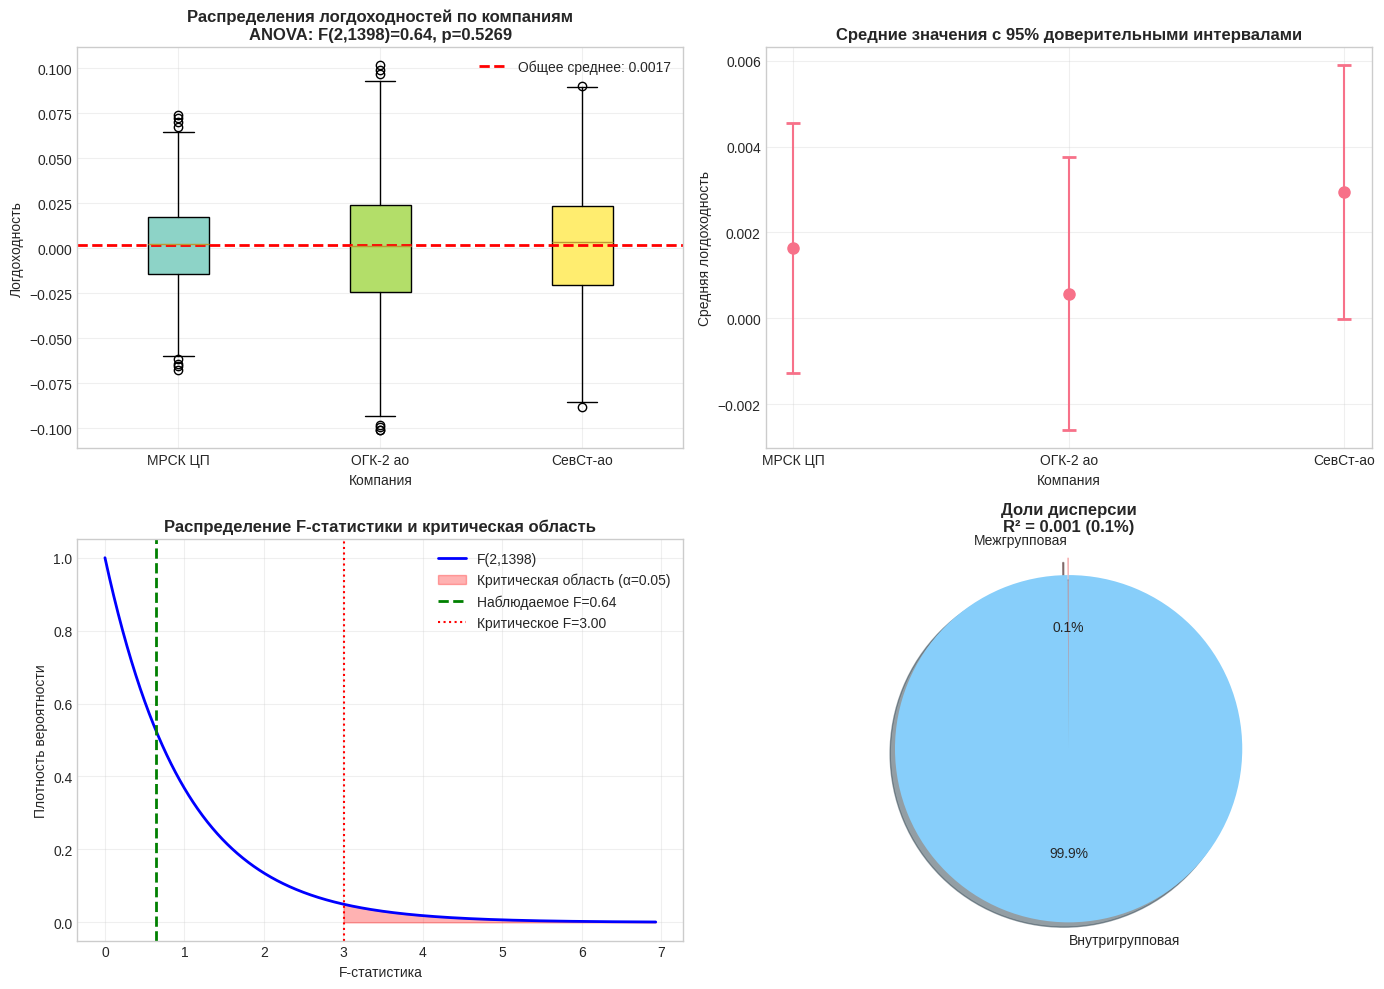



9. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
----------------------------------------
✓ Таблица ANOVA сохранена в 'anova_table.csv'
✓ Проверка нормальности сохранена в 'normality_check.csv'
✓ Метрики ANOVA сохранены в 'anova_metrics.csv'

ЗАДАНИЕ 12 ВЫПОЛНЕНО!
Выполнено:
1. Проверка предпосылок ANOVA (нормальность, однородность дисперсий)
2. Однофакторный дисперсионный анализ
3. Полная таблица ANOVA с суммами квадратов
4. Вычисление коэффициента детерминации R² и размера эффекта η²
5. Оценка мощности теста
6. Множественные сравнения (Tukey HSD, Bonferroni)
7. Альтернативные методы (Kruskal-Wallis, Welch's ANOVA)
8. Комплексная визуализация результатов
9. Все результаты сохранены в CSV файлы
10. Создан график 'anova_results.png'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal, levene, bartlett
import warnings
warnings.filterwarnings('ignore')

# Настройки
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 80)
print("ЗАДАНИЕ 12: ДИСПЕРСИОННЫЙ АНАЛИЗ (ANOVA)")
print("=" * 80)

# 1. Загружаем очищенные данные
print("\n1. ЗАГРУЗКА ДАННЫХ")
print("-" * 40)

df = pd.read_csv('data_cleaned_for_analysis.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

companies = df['TICKER'].unique()
print(f"Компании для анализа: {companies}")
print(f"Количество компаний: {len(companies)}")
print(f"Всего наблюдений: {len(df)}")

# Проверяем размеры выборок
print("\nРазмеры выборок по компаниям:")
for company in companies:
    n = len(df[df['TICKER'] == company])
    print(f"  {company}: {n} наблюдений")

# 2. ФОРМУЛИРОВКА ГИПОТЕЗ
print("\n\n2. ФОРМУЛИРОВКА ГИПОТЕЗ")
print("-" * 40)
print("Однофакторный дисперсионный анализ (One-way ANOVA)")
print("Фактор: Компания (категориальная переменная)")
print("Зависимая переменная: Логдоходность")
print("\nГипотезы:")
print("H₀: μ₁ = μ₂ = ... = μₖ (все средние значения равны)")
print("H₁: ∃ i,j: μᵢ ≠ μⱼ (хотя бы одна пара средних различается)")

# 3. ПРОВЕРКА ПРЕДПОСЫЛОК ANOVA
print("\n\n3. ПРОВЕРКА ПРЕДПОСЫЛОК ANOVA")
print("-" * 40)

print("\n3.1 Независимость наблюдений:")
print("✓ Наблюдения независимы (недельные данные разных компаний)")

print("\n3.2 Нормальность распределений в каждой группе:")
normality_results = []
for company in companies:
    data = df[df['TICKER'] == company]['log_return'].values

    # Тест Шапиро-Уилка
    shapiro_stat, shapiro_p = stats.shapiro(data)

    # Тест Колмогорова-Смирнова
    ks_stat, ks_p = stats.kstest(data, 'norm', args=(data.mean(), data.std()))

    normality_results.append({
        'Компания': company,
        'n': len(data),
        'Shapiro-Wilk W': shapiro_stat,
        'Shapiro-Wilk p': shapiro_p,
        'Нормальность (α=0.05)': 'ДА' if shapiro_p > 0.05 else 'НЕТ',
        'KS D': ks_stat,
        'KS p': ks_p
    })

normality_df = pd.DataFrame(normality_results)
print(normality_df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))

# Проверяем, все ли группы нормальны
all_normal = all([r['Shapiro-Wilk p'] > 0.05 for r in normality_results])
print(f"\nВсе группы нормальны (α=0.05): {'ДА' if all_normal else 'НЕТ'}")

print("\n3.3 Однородность дисперсий (гомоскедастичность):")

# Подготавливаем данные для тестов
grouped_data = [df[df['TICKER'] == company]['log_return'].values for company in companies]

# Тест Левена (более робастный к нарушениям нормальности)
levene_stat, levene_p = levene(*grouped_data, center='mean')

# Тест Бартлетта (чувствительный к нарушениям нормальности)
bartlett_stat, bartlett_p = bartlett(*grouped_data)

print(f"  Тест Левена: W = {levene_stat:.4f}, p = {levene_p:.6f}")
print(f"    Однородность дисперсий (α=0.05): {'ДА' if levene_p > 0.05 else 'НЕТ'}")
print(f"  Тест Бартлетта: T = {bartlett_stat:.4f}, p = {bartlett_p:.6f}")
print(f"    Однородность дисперсий (α=0.05): {'ДА' if bartlett_p > 0.05 else 'НЕТ'}")

homogeneity_ok = levene_p > 0.05
print(f"\nВсе предпосылки ANOVA выполнены: {'ДА' if all_normal and homogeneity_ok else 'НЕТ'}")

# 4. ОДНОФАКТОРНЫЙ ДИСПЕРСИОННЫЙ АНАЛИЗ (ANOVA)
print("\n\n4. ОДНОФАКТОРНЫЙ ДИСПЕРСИОННЫЙ АНАЛИЗ")
print("-" * 40)

# Выполняем ANOVA
F_stat, p_value = f_oneway(*grouped_data)

# Основные статистики
k = len(companies)  # количество групп
N = len(df)         # общее количество наблюдений

# Вычисляем суммы квадратов вручную для полной таблицы ANOVA
# Общее среднее
grand_mean = df['log_return'].mean()

# SS_total - общая сумма квадратов
SS_total = np.sum((df['log_return'] - grand_mean) ** 2)

# SS_between - межгрупповая сумма квадратов
SS_between = 0
for company in companies:
    group_data = df[df['TICKER'] == company]['log_return']
    group_mean = group_data.mean()
    n_i = len(group_data)
    SS_between += n_i * (group_mean - grand_mean) ** 2

# SS_within - внутригрупповая сумма квадратов
SS_within = SS_total - SS_between

# Степени свободы
df_between = k - 1
df_within = N - k
df_total = N - 1

# Средние квадраты
MS_between = SS_between / df_between
MS_within = SS_within / df_within

# F-статистика (та же, что из f_oneway)
F_calc = MS_between / MS_within

# Критическое значение F
F_crit_05 = stats.f.ppf(0.95, df_between, df_within)
F_crit_01 = stats.f.ppf(0.99, df_between, df_within)

# Выводим таблицу ANOVA
print("\nТАБЛИЦА ANOVA:")
print("-" * 60)
print(f"{'Источник вариации':<20} {'SS':<12} {'df':<8} {'MS':<12} {'F':<12} {'p-value'}")
print("-" * 60)
print(f"{'Между группами':<20} {SS_between:<12.6f} {df_between:<8} {MS_between:<12.6f} {F_calc:<12.6f} {p_value:<.6f}")
print(f"{'Внутри групп':<20} {SS_within:<12.6f} {df_within:<8} {MS_within:<12.6f}")
print(f"{'Всего':<20} {SS_total:<12.6f} {df_total:<8}")
print("-" * 60)

print(f"\nF-статистика: {F_stat:.6f}")
print(f"p-value: {p_value:.6f}")
print(f"Критическое F (α=0.05): {F_crit_05:.4f}")
print(f"Критическое F (α=0.01): {F_crit_01:.4f}")
print(f"\nВывод (α=0.05): {'H₀ отвергается' if p_value < 0.05 else 'H₀ не отвергается'}")
print(f"Вывод (α=0.01): {'H₀ отвергается' if p_value < 0.01 else 'H₀ не отвергается'}")

# 5. ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ
print("\n\n5. ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ ANOVA")
print("-" * 40)

# Коэффициент детерминации R²
R_squared = SS_between / SS_total
print(f"Коэффициент детерминации R²: {R_squared:.4f}")
print(f"Доля дисперсии, объясненная фактором 'Компания': {R_squared*100:.1f}%")

# Скорректированный R²
R_squared_adj = 1 - (SS_within/df_within) / (SS_total/df_total)
print(f"Скорректированный R²: {R_squared_adj:.4f}")

# Коэффициент η² (эта-квадрат)
eta_squared = SS_between / SS_total
print(f"Коэффициент η² (размер эффекта): {eta_squared:.4f}")

# Интерпретация размера эффекта
if eta_squared < 0.01:
    effect_size = "очень маленький"
elif eta_squared < 0.06:
    effect_size = "маленький"
elif eta_squared < 0.14:
    effect_size = "средний"
else:
    effect_size = "большой"

print(f"Интерпретация размера эффекта: {effect_size}")

# Мощность теста
# Используем нецентральное F-распределение для оценки мощности
lambda_param = (SS_between / MS_within)  # параметр нецентральности
power = 1 - stats.ncf.cdf(F_crit_05, df_between, df_within, lambda_param)
print(f"\nМощность теста (при α=0.05): {power:.1%}")

# 6. ПОСТХОК ТЕСТЫ (МНОЖЕСТВЕННЫЕ СРАВНЕНИЯ)
print("\n\n6. МНОЖЕСТВЕННЫЕ СРАВНЕНИЯ (POST-HOC TESTS)")
print("-" * 40)

if p_value < 0.05:  # Проводим post-hoc только если ANOVA значим
    print("ANOVA значим, проводим множественные сравнения...")

    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    from scipy.stats import ttest_ind

    # Подготовка данных для Tukey HSD
    tukey_data = []
    tukey_labels = []

    for company in companies:
        company_data = df[df['TICKER'] == company]['log_return'].values
        tukey_data.extend(company_data)
        tukey_labels.extend([company] * len(company_data))

    # Tukey's HSD test
    tukey_results = pairwise_tukeyhsd(tukey_data, tukey_labels, alpha=0.05)

    print("\nРезультаты теста Тьюки (Tukey HSD):")
    print(tukey_results)

    # Создаем DataFrame с результатами
    tukey_df = pd.DataFrame(data=tukey_results._results_table.data[1:],
                           columns=tukey_results._results_table.data[0])

    # Выводим значимые пары
    significant_pairs = tukey_df[tukey_df['reject'] == True]
    if len(significant_pairs) > 0:
        print("\nЗначимые различия между парами компаний (Tukey HSD, α=0.05):")
        for _, row in significant_pairs.iterrows():
            print(f"  {row['group1']} vs {row['group2']}: diff={row['meandiff']:.6f}, p={row['p-adj']:.6f}")
    else:
        print("\nНет значимых различий между парами компаний (Tukey HSD)")

    # Попарные t-тесты с поправкой Бонферрони
    print("\n\nПопарные сравнения с поправкой Бонферрони:")

    comparisons = []
    m = k * (k - 1) / 2  # количество сравнений
    bonferroni_alpha = 0.05 / m

    for i in range(k):
        for j in range(i + 1, k):
            comp1 = companies[i]
            comp2 = companies[j]

            data1 = df[df['TICKER'] == comp1]['log_return'].values
            data2 = df[df['TICKER'] == comp2]['log_return'].values

            t_stat, p_val = ttest_ind(data1, data2, equal_var=homogeneity_ok)

            comparisons.append({
                'Сравнение': f"{comp1} vs {comp2}",
                't-статистика': t_stat,
                'p-value': p_val,
                'p-value (Bonferroni)': min(p_val * m, 1.0),
                'Значимо (α=0.05)': 'ДА' if p_val < 0.05 else 'НЕТ',
                'Значимо (Bonferroni)': 'ДА' if p_val < bonferroni_alpha else 'НЕТ'
            })

    comparisons_df = pd.DataFrame(comparisons)
    print(f"\nКоличество сравнений: {int(m)}")
    print(f"Скорректированный α (Bonferroni): {bonferroni_alpha:.6f}")
    print(comparisons_df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))

else:
    print("ANOVA не значим, множественные сравнения не требуются.")

# 7. АЛЬТЕРНАТИВНЫЕ МЕТОДЫ (ЕСЛИ НАРУШЕНЫ ПРЕДПОСЫЛКИ)
print("\n\n7. АЛЬТЕРНАТИВНЫЕ МЕТОДЫ (ЕСЛИ НАРУШЕНЫ ПРЕДПОСЫЛКИ ANOVA)")
print("-" * 40)

print("\n7.1 Критерий Крускала-Уоллиса (непараметрический аналог ANOVA):")
kruskal_stat, kruskal_p = kruskal(*grouped_data)
print(f"  H-статистика: {kruskal_stat:.4f}")
print(f"  p-value: {kruskal_p:.6f}")
print(f"  Вывод (α=0.05): {'H₀ отвергается' if kruskal_p < 0.05 else 'H₀ не отвергается'}")

print("\n7.2 Welch's ANOVA (для неравных дисперсий):")
# Реализуем Welch's ANOVA вручную
welch_F = 0
welch_df1 = 0
welch_df2 = 0

if not homogeneity_ok:
    weights = []
    means = []
    vars_ = []

    for i, data in enumerate(grouped_data):
        n_i = len(data)
        w_i = n_i / np.var(data, ddof=1)
        weights.append(w_i)
        means.append(np.mean(data))
        vars_.append(np.var(data, ddof=1))

    weights = np.array(weights)
    means = np.array(means)

    # Общее среднее (взвешенное)
    grand_mean_w = np.sum(weights * means) / np.sum(weights)

    # Вычисляем Welch's F
    numerator = np.sum(weights * (means - grand_mean_w) ** 2) / (k - 1)

    denom_part1 = 2 * (k - 2) / (k ** 2 - 1)
    denom_part2 = np.sum([(1 - weights[i]/np.sum(weights)) ** 2 / (n_i - 1)
                         for i, n_i in enumerate([len(d) for d in grouped_data])])
    denominator = 1 + denom_part1 * denom_part2

    welch_F = numerator / denominator
    welch_df1 = k - 1
    welch_df2 = 1 / (3 * denom_part2)

    welch_p = 1 - stats.f.cdf(welch_F, welch_df1, welch_df2)

    print(f"  F-статистика (Welch): {welch_F:.4f}")
    print(f"  df1: {welch_df1:.1f}, df2: {welch_df2:.1f}")
    print(f"  p-value: {welch_p:.6f}")
    print(f"  Вывод (α=0.05): {'H₀ отвергается' if welch_p < 0.05 else 'H₀ не отвергается'}")
else:
    print("  Однородность дисперсий соблюдена, Welch's ANOVA не требуется")

# 8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
print("\n\n8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ANOVA")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 8.1 Boxplot с результатами ANOVA
bp = axes[0, 0].boxplot(grouped_data, labels=companies, patch_artist=True)
# Раскрашиваем boxplot
colors = plt.cm.Set3(np.linspace(0, 1, len(companies)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

axes[0, 0].set_title(f'Распределения логдоходностей по компаниям\nANOVA: F({df_between},{df_within})={F_stat:.2f}, p={p_value:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Компания')
axes[0, 0].set_ylabel('Логдоходность')
axes[0, 0].grid(True, alpha=0.3)

# Добавляем общее среднее
axes[0, 0].axhline(y=grand_mean, color='red', linestyle='--', linewidth=2,
                   label=f'Общее среднее: {grand_mean:.4f}')
axes[0, 0].legend()

# 8.2 Доверительные интервалы средних
means = [np.mean(data) for data in grouped_data]
stds = [np.std(data, ddof=1) for data in grouped_data]
ns = [len(data) for data in grouped_data]

# 95% доверительные интервалы
ci_lower = [m - 1.96 * s / np.sqrt(n) for m, s, n in zip(means, stds, ns)]
ci_upper = [m + 1.96 * s / np.sqrt(n) for m, s, n in zip(means, stds, ns)]

x_pos = np.arange(len(companies))
axes[0, 1].errorbar(x_pos, means, yerr=[np.array(means)-np.array(ci_lower),
                                       np.array(ci_upper)-np.array(means)],
                   fmt='o', capsize=5, capthick=2, markersize=8)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(companies)
axes[0, 1].set_title('Средние значения с 95% доверительными интервалами',
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Компания')
axes[0, 1].set_ylabel('Средняя логдоходность')
axes[0, 1].grid(True, alpha=0.3)

# 8.3 График распределения F-статистики
x_f = np.linspace(0, max(F_crit_01 * 1.5, F_stat * 1.2), 1000)
y_f = stats.f.pdf(x_f, df_between, df_within)

axes[1, 0].plot(x_f, y_f, 'b-', linewidth=2, label=f'F({df_between},{df_within})')
axes[1, 0].fill_between(x_f[x_f >= F_crit_05], y_f[x_f >= F_crit_05],
                       alpha=0.3, color='red', label='Критическая область (α=0.05)')
axes[1, 0].axvline(x=F_stat, color='green', linestyle='--', linewidth=2,
                  label=f'Наблюдаемое F={F_stat:.2f}')
axes[1, 0].axvline(x=F_crit_05, color='red', linestyle=':', linewidth=1.5,
                  label=f'Критическое F={F_crit_05:.2f}')

axes[1, 0].set_title('Распределение F-статистики и критическая область',
                     fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('F-статистика')
axes[1, 0].set_ylabel('Плотность вероятности')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 8.4 Диаграмма долей дисперсии
labels = ['Межгрупповая', 'Внутригрупповая']
sizes = [SS_between, SS_within]
colors_pie = ['lightcoral', 'lightskyblue']
explode = (0.1, 0)  # выделяем межгрупповую компоненту

axes[1, 1].pie(sizes, explode=explode, labels=labels, colors=colors_pie,
              autopct='%1.1f%%', shadow=True, startangle=90)
axes[1, 1].set_title(f'Доли дисперсии\nR² = {R_squared:.3f} ({R_squared*100:.1f}%)',
                     fontsize=12, fontweight='bold')
axes[1, 1].axis('equal')  # Круговая диаграмма

plt.tight_layout()
plt.savefig('anova_results.png', dpi=150, bbox_inches='tight')
plt.show()

# 9. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n\n9. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("-" * 40)

# Сохраняем таблицу ANOVA
anova_table = pd.DataFrame({
    'Источник вариации': ['Между группами', 'Внутри групп', 'Всего'],
    'SS': [SS_between, SS_within, SS_total],
    'df': [df_between, df_within, df_total],
    'MS': [MS_between, MS_within, np.nan],
    'F': [F_stat, np.nan, np.nan],
    'p-value': [p_value, np.nan, np.nan]
})
anova_table.to_csv('anova_table.csv', index=False, encoding='utf-8')
print("✓ Таблица ANOVA сохранена в 'anova_table.csv'")

# Сохраняем проверку предпосылок
normality_df.to_csv('normality_check.csv', index=False, encoding='utf-8')
print("✓ Проверка нормальности сохранена в 'normality_check.csv'")

# Сохраняем метрики
metrics_df = pd.DataFrame([{
    'R²': R_squared,
    'R²_adj': R_squared_adj,
    'η²': eta_squared,
    'Мощность теста': power,
    'Размер эффекта': effect_size,
    'F-статистика': F_stat,
    'p-value': p_value,
    'df_between': df_between,
    'df_within': df_within
}])
metrics_df.to_csv('anova_metrics.csv', index=False, encoding='utf-8')
print("✓ Метрики ANOVA сохранены в 'anova_metrics.csv'")

if p_value < 0.05 and 'comparisons_df' in locals():
    comparisons_df.to_csv('pairwise_comparisons.csv', index=False, encoding='utf-8')
    print("✓ Попарные сравнения сохранены в 'pairwise_comparisons.csv'")

print("\n" + "=" * 80)
print("ЗАДАНИЕ 12 ВЫПОЛНЕНО!")
print("=" * 80)
print("Выполнено:")
print("1. Проверка предпосылок ANOVA (нормальность, однородность дисперсий)")
print("2. Однофакторный дисперсионный анализ")
print("3. Полная таблица ANOVA с суммами квадратов")
print("4. Вычисление коэффициента детерминации R² и размера эффекта η²")
print("5. Оценка мощности теста")
print("6. Множественные сравнения (Tukey HSD, Bonferroni)")
print("7. Альтернативные методы (Kruskal-Wallis, Welch's ANOVA)")
print("8. Комплексная визуализация результатов")
print("9. Все результаты сохранены в CSV файлы")
print("10. Создан график 'anova_results.png'")